# 📝 PROYECTO FINAL: Auditoría de Cartera y Cálculo de Pérdida Esperada (Expected Loss)

Los datos pueden descargarse aquí: https://www.kaggle.com/datasets/db0boy/lending-club-loan-data-cleared/data

La descripción de las variables viene dada en el enlace. Esto será interesante para entender tu dataset y poder construir nuevas variables más interesantes o entender cómo interpretarlas, imputar los nulos, etc.

<br>

## 📩 Memorándum Interno

De: Chief Risk Officer (CRO)

Para: Equipo de Data Science & Riesgos

Asunto: Valoración de la cartera "Lending Club" para adquisición.

Nuestra entidad está evaluando la compra de una cartera de créditos al consumo originada por la plataforma Lending Club. El equipo de Inversiones está emocionado porque los tipos de interés de estos préstamos parecen muy rentables. Sin embargo, desde el departamento de Riesgos y bajo la atenta mirada del regulador, sabemos que la rentabilidad no es nada si no somos capaces de estimar el riesgo real de impago y la pérdida económica que nos va a suponer.

No voy a aprobar esta compra basándome en intuiciones. Necesito que construyáis un motor de Credit Scoring y Valoración de Pérdida Esperada (Expected Loss) desde cero.

Vuestro objetivo final no es entregarme un modelo con un buen "Accuracy". Vuestro objetivo es darme una cifra en euros: ¿Cuánto dinero estimamos que vamos a perder de esta cartera?

Para ello, tendréis que calcular la fórmula reina del riesgo de crédito:
Pérdida Esperada (EL) = PD × LGD × EAD

<br>

## 🗺️ Tu Misión (Hoja de Ruta)

El proyecto se divide en 4 fases críticas. Deberéis documentar cada decisión que toméis. Si borráis nulos o agrupáis categorías, quiero saber por qué lo hacéis desde el punto de vista de negocio. Podéis utilizar cualquier modelo de Machine Learning que consideréis oportuno para cada fase.

### Fase 1: Limpieza de Datos y Definición del Problema (Data Preparation)
El archivo que nos han enviado desde Lending Club tiene datos de clientes reales. Eso significa ruido, valores atípicos y nulos.

- Análisis Exploratorio (EDA): Identificad qué variables tenemos. ¿Hay desbalanceo? ¿Qué hacemos con las profesiones raras o los valores extremos en ingresos?

**Definición de los Parámetros de Riesgo:**

- PD (Probability of Default): Se calculará como una probabilidad matemática sin más. Deberéis crear una variable objetivo binaria (0/1) a partir del estado del préstamo, donde los impagados son un 1 y los pagados un 0.

- LGD (Loss Given Default / Severidad): Para calcular la pérdida real, utilizaréis la siguiente fórmula exacta en vuestro código:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ``df['Loss'] = 100 * df['max_bal_owed'] / df['funded_amnt']``

- EAD (Exposure At Default): La exposición será directamente la cantidad financiada inicial (``funded_amnt``).

### Fase 2: ¿Quién no nos va a pagar? (Modelo de Probabilidad de Impago - PD)
Necesitamos separar a los buenos clientes de los tóxicos usando un modelo de clasificación.

- Entrenamiento: Podéis usar el algoritmo de clasificación que queráis (Regresión Logística, Árboles, Random Forest, XGBoost...).

- Métrica de Decisión: No miréis el Accuracy. Quiero que maximicéis el Recall y el ROC-AUC. Prefiero rechazar a un cliente regular que dejar pasar a un moroso que nos cueste 20.000€.

- Entregable de esta fase: El modelo elegido y las probabilidades de impago (predict_proba) para cada cliente del conjunto de validación/test.

### Fase 3: Si no nos pagan, ¿cuánto perdemos? (Modelo de Severidad - LGD)
Aquí cambia el juego. Coged solo a los clientes que sabemos que son morosos (Target de la PD = 1) y entrenad un modelo de regresión para predecir el porcentaje de pérdida (Loss).

- Entrenamiento: Nuevamente, usad el algoritmo de regresión que prefiráis.

- Métrica de Decisión: Evaluad con el MAE y el RMSE. ¿Qué modelo se acerca más al porcentaje real de pérdida que calculamos en la Fase 1?

### Fase 4: El Veredicto Final (Expected Loss)
Ha llegado el momento de unir las piezas para el Comité de Dirección.

Tomad el conjunto de datos de Test (nuestra simulación del mundo real).

Usad el Modelo de PD para predecir la probabilidad de impago de cada préstamo.

Usad el Modelo de LGD para predecir el porcentaje de pérdida esperado.

Multiplicad los factores para calcular la pérdida esperada económica para cada cliente: 
$$
Pérdida\;Esperada = PD × (Loss / 100) × EAD
$$

Sumad la Pérdida Esperada de todos los clientes para obtener la cifra total de la cartera.

<br>

## 📊 Entregable Final: La Defensa
El Notebook debe terminar con una sección de conclusiones respondiendo a esto:

"Señores del Comité, de una cartera de Test valorada en [X] millones de dólares, nuestro motor estima que tendremos unas pérdidas por impago de [Y] millones de dólares."

Justificad la elección de vuestros modelos. ¿Son explicables ante el regulador o habéis optado por maximizar la precisión a costa de usar cajas negras?

Demostradme que no sois simples picadores de código, sino verdaderos Data Scientists financieros.

## 🚀 Unas palabras antes de empezar

Este es el momento de la verdad. Si logras estructurar este razonamiento, conectar los modelos y sacar esa cifra final con sentido de negocio, habrás demostrado que eres un Data Scientist de verdad. Quien es capaz de resolver un problema *end-to-end* de este calibre, lidiando con datos sucios, calculando la severidad y uniendo probabilidades financieras, está preparado para enfrentarse a casi cualquier reto en la industria. 

Eso sí, quiero ser muy franco contigo: es un proyecto bastante complejo. Es completamente normal que te atasques, que la limpieza te dé dolores de cabeza o que los números no cuadren a la primera. No te frustres; esa es exactamente la idea y el propósito de esta práctica. Te llevará tiempo y requerirá ensayo y error, pero es en ese proceso donde ocurre el verdadero aprendizaje. 

Recuerda que no estás solo en este camino. Si llevas horas dándote cabezazos contra un error o no sabes cómo interpretar una métrica, contáctame o deja tus dudas en la sección de preguntas del curso. Estoy aquí para guiarte y asegurarme de que cruces esa línea de meta. ¡A por todas!

___________

# Project Overview

This project focuses on the development of a complete Credit Risk Modeling framework using consumer loan data originated by Lending Club. The main objective is not only to predict loan defaults, but also to estimate the total expected economic loss associated with a loan portfolio acquisition.

The project follows a real-world credit risk approach commonly used in banking and financial institutions, where portfolio valuation depends on three key risk parameters:

$$
Expected\ Loss\ (EL) = PD \times LGD \times EAD
$$

Where:

* **PD (Probability of Default):** likelihood that a borrower will default.
* **LGD (Loss Given Default):** percentage of exposure that would be lost in the event of default.
* **EAD (Exposure at Default):** total exposure at the time of default.

The workflow is divided into four main stages:

1. **Data Preparation & Exploratory Analysis**
   Cleaning missing values, handling outliers, analyzing feature distributions, and defining the target variables from a business-oriented risk perspective.

2. **Probability of Default Modeling (PD)**
   Building classification models to identify high-risk borrowers and estimate default probabilities.

3. **Loss Given Default Modeling (LGD)**
   Training regression models on defaulted loans to estimate the expected severity of losses.

4. **Expected Loss Estimation (EL)**
   Combining PD, LGD, and EAD predictions to calculate the expected monetary loss of the portfolio.

The project emphasizes not only predictive performance, but also interpretability, business understanding, and risk-based decision making, replicating the type of analysis performed in real credit risk environments.


# Libraries

As this project represents an *end-to-end* pipeline in Data Science, the first step is loading the most common and useful libraries in the field. 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import catboost
import shap

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Gradient boosting models
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor


C:\Users\juang\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Functions

The complexity of this project requires of *in-house* building functions.

In [3]:
%load_ext autoreload
%autoreload 2

# Chosing variables with predictive power before Data Cleaning functions
from feature_selection import select_features, diagnose_features, compute_plot_correlation_matrix, analyze_correlated_pairs, exploratory_feature_selection

# Plotting frecuency tables and boxplot functions
from feature_plot import analyze_zero_variance_feature, analyze_categorical_feature, plot_continuous_variable_categoric_feature, plot_boxplots_list, plot_scatter_list, plot_categoricals

# Statistical significance between distributions
from feature_statistics import compare_distributions, dataset_audit, outlier_summary, clean_features_PD, clean_features_LGD

# AI enhanced functions for feature engineering
from feature_engineering import group_emp_title, clean_emp_length, preprocess_features_LGD, preprocess_features_LGD

# Training models functions
from train_models_PD import train_all_models_PD
from train_models_LGD import train_all_models_LGD

# Classes to process raw datasets
from FeaturePipeline_LGD import FeaturePipeline_LGD

# Data Load and First Look

The data is splitted in two .csv. The one called `target.csv` contains the information about the payment of the loan, meaning 1 default and 0 payment. The other, called `X.csv` contains all the information about the loan, i.e, annual income, interest rate... The first step is load them and create a dataframe with all the information.

In [23]:
# Load the target.csv.

target_df = pd.read_csv(r"C:\Users\juang\OneDrive\Escritorio\Trabajo\DataScientist\CursoJYTS\JytsCourse\Data\P12\target.csv")
X_df = pd.read_csv(r"C:\Users\juang\OneDrive\Escritorio\Trabajo\DataScientist\CursoJYTS\JytsCourse\Data\P12\X.csv")

# We create a dataframe having in the first column the target variable.

df = pd.concat([target_df, X_df], axis=1)

# We show the dataframe.

df.head()

,y,funded_amnt,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,verification_status,...,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year
0,0,2500,13.56,84.92,C1,Chef,10+ years,RENT,55000.0,Not Verified,...,2,NaN,NaN,Cash,36,Dec,2018,1,Apr,2001
1,0,30000,18.94,777.23,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,...,2,NaN,NaN,Cash,60,Dec,2018,7,Jun,1987
2,0,5000,17.97,180.69,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,...,0,NaN,NaN,Cash,36,Dec,2018,4,Apr,2011
3,0,4000,18.94,146.51,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,...,3,NaN,NaN,Cash,36,Dec,2018,9,Feb,2006
4,0,30000,16.14,731.78,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,...,0,NaN,NaN,Cash,60,Dec,2018,2,Dec,2000


In [24]:
df["issue_date_year"].describe()

count    2.139643e+06
mean     2.015766e+03
std      1.791998e+00
min      2.007000e+03
25%      2.015000e+03
50%      2.016000e+03
75%      2.017000e+03
max      2.018000e+03
Name: issue_date_year, dtype: float64

**Important remark**: This dataframe only contains the target variable (y) for the PD model. The target variable for LGD model will be created later on as the coefficient of `max_bal_owed` which represents them aximum current balance owed on all revolving accounts and `funded_amnt` which represents the total amount committed to that loan at that point in time (**EAD**)

Some important metrics of the dataframe which help us to have a wider vision of the data and also of the libraries choice.

In [ ]:
df["y"].mean()

There is around 13.07% of default in the data, so it's a stratified target variable.

In [25]:
df.shape

(2139643, 46)

As the dataframe as around 2.13 million of rows, using pandas is totally justified since this dataframe is not considerar *Big Data*

In [ ]:
df.info()

Some basic information about the features and target variable of PD model.

In [ ]:
df.isna().sum()

The number of NaNs in every feature. Handling NaNs is one of the most important skills in Data Science since it requires a deep knowledge about the project/business.

# Model-Specific Datasets: PD & LGD Datasets

As we said in the Project Overview we will train two different models, one **Classification Model** to identify high-risk borrowers and estimate default probabilities hereinafter referred to as **PD Model** and one **Regression Model** on defaulted loans to estimate the expected severity of losses hereinafter referred to as **LGD Model**. Every target variable and so every model will have different dependencies from the features, i.e. meaningful features for LGD Model could have no sense for PD Model because of causality. Also, the relation among the target variable and the feature could influence the feature engineering pipeline.

As a result, in some cases we will have two different versions of one feature following this nomenclature: feature_X_PD, feature_X_LGD.

**Important remark**: The LGD Model will be only trained with default cases, so the following analyzes involving LGD Model target variable will only take into account the default cases (PD Model target variable == 1) even though we them will infer over all the datasat.

In [ ]:
# We create a dataframe that will contain all possible features, including PD and LGD Models.
df_master = df.copy()

# We rename the target variable for PD Model and funded_amnt which corresponds to EDA.
df_master = df_master.rename(columns={"y":"Target_Variable_Default","funded_amnt":"EAD"})

# We define the target variable for LGD Model and set it as the second columns. Then, we keep only the cases where the loss is smaller than 300%, since
# greater ones does not make any sense.
df_master.insert(1,"Target_Variable_Loss",100*(df_master["max_bal_owed"]/df_master["EAD"]))
df_master = df_master[df_master["Target_Variable_Loss"]<300]

We have a look to the new dataframe.

In [ ]:
df_master.head()

Through the process of data cleaning we will identify some features that have predictive power over the different target variables, features that will be used to train the PD Model and LGD Model. To keep these important features we will initialize two list, one for each model. Every time we identify feature with predictive power over the corresponding target variable, it will be appended to the correspondind list.

In [ ]:
features_predictive_power_PD = []
features_predictive_power_LGD = []

# Data Diagnose

In large datasets, cleaning and analyzing every feature may become unnecessarily time-consuming. Although the data source states that the dataset has already been cleaned and that non-predictive features were removed, as is the case here, such assumptions should always be validated independently rather than accepted without verification.

In this particular dataset, the Kaggle documentation states:

"Only individual credit applications were retained, and all features that consisted entirely of missing values were deleted, further selecting the most important features based on EDA and IV score. In features containing a small number of missing values, the decision was made to delete rows with missing values. Features with a large number of missing values that had a low IV when considering missing values as a separate category were also deleted, as filling in nulls or deleting rows would result in a significant loss of information."

While this methodology is reasonable, the specific thresholds used for feature selection and IV filtering are not disclosed. Therefore, it cannot be assumed that all remaining features possess sufficient predictive power.

The predictive relevance of a feature is closely related to several statistical properties. The most important factors that may bias or artificially inflate predictive performance are the following:

**1. Missing values (NaNs)**\
A high proportion of missing values implies a substantial loss of information. Features containing more than 5% missing observations may not reliably reflect their true predictive capacity.

**2. High cardinality and category fragmentation**\
In categorical features, excessive cardinality combined with low-frequency categories (e.g., categories representing less than 1% of observations) may introduce statistical noise and unstable predictive behavior. Also, features highly fragmented, which means that the number of categories is greater than 5% of the number of unique rows (2 millions unique rows and 100k categories), could introduce unstable predictive behavior. 

**3. Low variance**\
Features with extremely low variance generally provide little or no predictive information. For example, if 99% of individuals own a phone, the feature phone ownership carries almost no discriminatory power. However, in some cases, the remaining minority class may still exhibit statistically significant behavior. For this reason, features in which a single category represents more than 90% of observations will be flagged as low-variance features.

Features meeting one or more of these conditions will be manually reviewed and analyzed individually, since many of them may still become predictive after appropriate feature engineering techniques such as missing-value imputation, category encoding, feature transformation or not identified as a low-feature due to stratify data.

The following function automatically identifies features exhibiting these characteristics.

In [ ]:
# We create a new dataframe to have df_master as control through the data cleaning process.

df_master_features = df_master.copy()

# We diagnosis the features and show it.
diagnosis = diagnose_features(df_master_features)
diagnosis

There are multiple ways of dealing with these features automatically, i.e, if the feature is numeric and continuous and the NaNs are randomly distributed, we could input them to the median. Since the majority of the features that must be checked have a high percentage of NaNs and just 2 don't, we will deal with all of them manually.

## Zero variance

### late_fees_rec: Overview

This feature represents the late fees received to date

### late_fees_rec: PD Model

This continuous feature in principle should play a role in the PD Model target variable. Let's see it's distribution.

In [ ]:
df_master_features["late_fees_rec"].value_counts()

As we can see here, and in the diagnosis dataframe, 96.24% of the population corresponds to 0 late_fees_rec, but the PD Model target variable it's a stritified variable, so that 3.76% left could give us a lot of information about the default population.

In order to solve this, we will analyze the frecuency table of having late fees or not vs default. Also, we will plot the money of the late fees in default vs no default population in order to analyze if the value plays a role.

In [ ]:
analyze_zero_variance_feature(df_master_features, feature="late_fees_rec", target="Target_Variable_Default")

The frecuency table shows that if late_fees_rec = 0, the bases rates of default nearly holds. Nevertheless, if late_fees_rec > 0 the probability of defaut dramastically changes, it increases to 46.74% from 8.86%, that's more than a 400% increase or x5.

So, it's totally clear that **late_fees_rec have a significant predictive power** as we expected.

How the predictive power is encoded in the variable is given by the boxplot. In the boxplot, apparently, we can see there are no statistical significance among both groups, but we need to ststitically quantify this using p-value and Cohen's d.

In [ ]:
# We obtain the p-value and Cohen's d of both groups.
compare_distributions(df_master_features, feature = "Target_Variable_Default" , target = "late_fees_rec", alpha=0.05)

As we can see here, there is a significative statistical difference among both groups since p-value = 0.0000, but this, having more than 1 million of observations is inevitable. To avoid this bias, we use the Cohen's d which takes takes into account the sample size to determine if the significative diffence found by p-value is truly significative. As shown, a Cohen's d value of 0.306 implies a small effect and so fees' money does not play a role in the PD Model target variable and that only having late fees is important for default.

As a consecuence, this feature must be encoded in the following way.

In [ ]:
# We enconde the feature in a new feature.
df_master_features["has_late_fees_PD"] = (df_master_features["late_fees_rec"] > 0).astype(int)

# We store this feature in features with predictive power for PD Model.
features_predictive_power_PD.append("has_late_fees_PD")

### late_fees_rec: LGD Model

In this case the approach is totally different since LGD Model target variable is a continuous variable. Let's represent LGD Model target variable in the default cases vs late_fees_rec.

In [ ]:
# We create an auxiliar dataframe that only contains the default cases.
df_master_features_default = df_master_features[df_master_features["Target_Variable_Default"]==1]

# We plot Target_Variable_Loss in default cases vs late_fees_rec
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_master_features_default['late_fees_rec'],
    df_master_features_default['Target_Variable_Loss'],
    alpha=0.15,
    s=8,
    color='#3266ad'
)

ax.set_xlabel('late_fees_rec in default case', fontsize=12)
ax.set_ylabel('Target_Variable_Loss (%)', fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In the credit scoring field this figure is pretty common, as well as the first hypothesis you can think of. At first, in credit scoring field, you could think that cases of late_fees_rec = 0 correspond to the biggest Loss because of the correspond to fast default loan, so the financial entity didn't have time enough to give a warning and the consequently late fee. If this is the case, the set of late_fees_rec = 0 would be dominated by default loans, but we analyzed in the frecuency table from above that 91.14% of loans with late_fees_rec = 0 are not default, so the hyphotesis is worng.

A plausible alternative is considering that people that received a late fee make an effort to reduce their debts (`max_bal_owed`) and the people that haven't received a late fee don't feel the financial stress and are not trying to handle their debts.

So for `Target_Variable_Loss` the feauture `late_fees_rec` **has predictive power**.

Since `late_fees_rec` is a continuos variable in this case we need to handle with the outliers. As this feature has Zero Variance issues, identifying the outliers with the IQR method could introduce a bias, so we will use 99% and 99.9% quantile.

In [ ]:
# We identify the outliers using 0.99 and 0.999 percentil.
quantile_99_late_fees_rec_default = df_master_features_default['late_fees_rec'].quantile(0.99)
quantile_999_late_fees_rec_default = df_master_features_default['late_fees_rec'].quantile(0.999)
max_value_late_fees_rec_default = df_master_features_default['late_fees_rec'].max()

# We print the results.
print(
f"For late_fees_rec in default cases the quantile 99% is {quantile_99_late_fees_rec_default:.2f},\
the quantile 99.9% is {quantile_999_late_fees_rec_default:.2f} and the maximum value is {max_value_late_fees_rec_default:.2f}"
)

So, in this feature we have a long tail since the 0.1% of values are between 276.96 and 1427. So we will clip all of them to the 99.9 quantile and the feature is encoded in the following way.

In [ ]:
# We encode the feature by just clipping the values bigger than 99.9% quantile changing its name.
df_master_features["late_fees_rec_LGD"] = df_master_features["late_fees_rec"].clip(upper=quantile_999_late_fees_rec_default)

# We store this feature in features with predictive power for LGD Model.
features_predictive_power_LGD.append("late_fees_rec_LGD")

Finally, has we have completely analyzed `late_fees_rec` we drop it from the dataframe.

In [ ]:
# We drop late_fees_rec from the dataframe.
df_master_features = df_master_features.drop(columns="late_fees_rec")

### disbursement_method: Overview

This feature represents the method by which the borrower receives their loan.

### disbursement_method: PD Model

This feature in principle should play a role in the PD Model target variable, since payment methods other than cash require greater security assurances from the customer. Let's see it's distribution.

In [ ]:
df_master_features["disbursement_method"].value_counts()

As we can see, this is a categorial feature so a frecuency table is the most simple way of analyzing this variable.

In [ ]:
analyze_categorical_feature(df_master_features, feature="disbursement_method", target="Target_Variable_Default")

The frecuency table shows that in the Cash case the base case holds but in the DirectPay it's clear that default loans (`Target_Variable_Default` = 1) dramastically decreases, indicating that DirectPay method prefer good payers.

So, it's totally clear that `disbursement_method` has **predictive power** over `Target_Variable_Default`.

As a consecuence, this feature must be encoded in the following way.

In [ ]:
# We enconde the variable in a new variable.
df_master_features["is_directpay_PD"] = (df_master_features["disbursement_method"] == "DirectPay").astype(int)

# We store this feature in features with predictive power for PD Model.
features_predictive_power_PD.append("is_directpay_PD")

### disbursement_method: LGD Model

In this case the feature `disbursement_method` is categorial and `Target_Variable_Loss` is continuous so the most rigorous way of analysing the predictive power is to show a box plot of `Target_Variable_Loss` vs the two different categories of `disbursement_method` and measure the p-value and Cohen's d.

In [ ]:
# We plot the box plot.
plot_continuous_variable_categoric_feature(df = df_master_features_default, feature = "disbursement_method", target= "Target_Variable_Loss")

In [ ]:
# We obtain the p-value and Cohen's d.
compare_distributions(df=df_master_features_default,feature='disbursement_method',target='Target_Variable_Loss')

A Mann–Whitney U test was performed to compare the LGD Model target variable `Target_Variable_Loss` values of the two `disbursement_method` groups, Cash and DirectPay. Although the test revealed a statistically significant difference between both groups ((p < 0.05)), the effect size was small (Cohen’s (d = 0.235)). This suggests that, despite the large sample size allowing the detection of small distributional differences, the practical impact of the payment method on `Target_Variable_Loss`is minimal.

So it's clear that `disbursement_method` has **no predictive power** over `Target_Variable_Loss`. Anyway, we will keep it to check this in a more rigorous analysis involving Mutual Informatio, Lasso Coefficients and Boruta.

In [ ]:
# We enconde the feature just by changing it's name.
df_master_features["disbursement_method_LGD"] = df_master_features["disbursement_method"]

Finally, has we have completely analyzed `disbursement_method` we drop it from the dataframe.

In [ ]:
# We drop disbursement_method from the dataframe.
df_master_features = df_master_features.drop(columns="disbursement_method")

## NaNs number

### mths_since_recent_bankcard_delinq, mths_since_recent_revol_delinq, mths_since_last_delinq, mths_since_last_installment_acc_op, (months_since_...): Overview

These variables represent the number of month from the last event, in this case, last bankcard delinquency, revolving delinquency, last revolving delinquency and opening the most recent installment account.

As we saw earlier, they have a high percentage of NaNs which is a problem. In this kind of variables, NaNs are a clear case of **MNAR (Missing Not At Random)**, more precisely the NaNs represent no delinquency events.

### mths_since_recent_bankcard_delinq, mths_since_recent_revol_delinq, mths_since_last_delinq, mths_since_last_installment_acc_op, (months_since_...): PD Model

We will follow the same analysis pipeline we did with late_fees_rec. At first we will analyze if the NaNs are informative, that is to say, if having a delinquency event/account open or not plays a role in the `Target_Variable_Default`, by using the same logic as we did before, frecuency table and quantification of boxplots.

In [ ]:
# We create a new dataframe to perform the analysis since we will create auxiliar features.
df_master_features_months = df_master_features.copy()

# We create an auxiliar feature that quantifies if a delinquency event happened for every feature of interest.

df_master_features_months["has_bankcard_delinq"] = df_master_features_months["mths_since_recent_bankcard_delinq"].notna().astype(int)
df_master_features_months["has_revol_delinq"] = df_master_features_months["mths_since_recent_revol_delinq"].notna().astype(int)
df_master_features_months["has_delinq"] = df_master_features_months["mths_since_last_delinq"].notna().astype(int)
df_master_features_months["has_acc_op"] = df_master_features_months["mths_since_last_installment_acc_op"].notna().astype(int)

Now, we analyze the features one by one.

In [ ]:
# Frecuency table for has_bankcard_delinq_PD.
analyze_categorical_feature(df_master_features_months, feature="has_bankcard_delinq", target="Target_Variable_Default")

# Frecuency table for has_revol_delinq_PD.
analyze_categorical_feature(df_master_features_months, feature="has_revol_delinq", target="Target_Variable_Default")

# Frecuency table for has_delinq_PD.
analyze_categorical_feature(df_master_features_months, feature="has_delinq", target="Target_Variable_Default")

# Frecuency table for has_acc_op_PD.
analyze_categorical_feature(df_master_features_months, feature="has_acc_op", target="Target_Variable_Default")

The base case holds in every feature for both cases so, having a delinquency event/account open or not does not play a role in these features.

So now we will analyze if delinquency/account open timing plays a role in `Target_Variable_Default`, feaature by feature.

In [ ]:
# Boxplot, p-value and Cohen's d for mths_since_bankcard_delinq
plot_continuous_variable_categoric_feature(
    df=df_master_features_months[df_master_features_months['has_bankcard_delinq'] == 1],
    feature='Target_Variable_Default',
    target='mths_since_recent_bankcard_delinq'
)
compare_distributions(df=df_master_features_months,feature='Target_Variable_Default',target='mths_since_recent_bankcard_delinq')

# Boxplot, p-value and Cohen's d for mths_since_recent_revol_delinq.
plot_continuous_variable_categoric_feature(
    df=df_master_features_months[df_master_features_months['has_revol_delinq'] == 1],
    feature='Target_Variable_Default',
    target='mths_since_recent_revol_delinq'
)
compare_distributions(df=df_master_features_months,feature='Target_Variable_Default',target='mths_since_recent_revol_delinq')

# Boxplot, p-value and Cohen's d for mths_since_last_delinq.
plot_continuous_variable_categoric_feature(
    df=df_master_features_months[df_master_features_months['has_delinq'] == 1],
    feature='Target_Variable_Default',
    target='mths_since_last_delinq'
)
compare_distributions(df=df_master_features_months,feature='Target_Variable_Default',target='mths_since_last_delinq')

# Boxplot, p-value and Cohen's d for mths_since_last_installment_acc_op.
plot_continuous_variable_categoric_feature(
    df=df_master_features_months[df_master_features_months['has_acc_op'] == 1],
    feature='Target_Variable_Default',
    target='mths_since_last_installment_acc_op'
)
compare_distributions(df=df_master_features_months,feature='Target_Variable_Default',target='mths_since_last_installment_acc_op')

The boxplots and statistical tests show that in principle **these features don't have any predictive power by their own** but since we don't want to lose any information, to keep somehow these features we will keep them setting the NaNs to 999 (**centinel value**) and in a more rigoruos and deep analyze involving Mutual Information, Lasso Coefficients and Boruta determine if they really have predictive power.

Imputting the NaNs to the centinel value of 999 will include a lot of outliers so beforewards we need to handle the outliers in these features. Let's see their box plots.

In [ ]:
# We create the list of feature whose boxplot we want to plot.
mths_since_cols = ["mths_since_recent_bankcard_delinq","mths_since_recent_revol_delinq","mths_since_last_delinq","mths_since_last_installment_acc_op"]

# We plot them.
plot_boxplots_list(df=df_master_features_months,features=mths_since_cols)

The only feature whose outliers could cause problems to the models is mths_since_last_installment_acc_op. Let's see the percentage of them since in datasets with so many observations, the figures can be misseading about the outlier number.

In [ ]:
# We create a new feature to deal with the outliers.
df_master_features_months["mths_since_recent_bankcard_delinq_PD"] = df_master_features_months["mths_since_recent_bankcard_delinq"]

# We identify the outliers using the interquartile range.
Q1 = df_master_features_months['mths_since_recent_bankcard_delinq_PD'].quantile(0.25)
Q3 = df_master_features_months['mths_since_recent_bankcard_delinq_PD'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
outliers = (df_master_features_months['mths_since_recent_bankcard_delinq_PD'] > upper_limit) | (df_master_features_months['mths_since_recent_bankcard_delinq_PD'] < lower_limit)
outliers_pct = 100*(outliers.sum()/df_master_features_months['mths_since_recent_bankcard_delinq_PD'].shape[0])

# We prompt the outliers percentage.
print(f"The outlier percentage of mths_since_recent_bankcard_delinq_PD is {outliers_pct:.2f}%.")

In fact, there is only 0.06% of outliers in `mths_since_recent_bankcard_delinq_PD` so they won't be a problem.


Finnaly we input the NaNs to centinel value 999.

In [ ]:
# We input the NaNs to centinel value 999 which means that the event happened a long time ago.
df_master_features["mths_since_recent_bankcard_delinq_PD"] = df_master_features_months["mths_since_recent_bankcard_delinq_PD"].fillna(999)
df_master_features["mths_since_recent_revol_delinq_PD"] = df_master_features_months["mths_since_recent_revol_delinq"].fillna(999)
df_master_features["mths_since_last_delinq_PD"] = df_master_features_months["mths_since_last_delinq"].fillna(999)
df_master_features["mths_since_last_installment_acc_op_PD"] = df_master_features_months["mths_since_last_installment_acc_op"].fillna(999)

### mths_since_recent_bankcard_delinq, mths_since_recent_revol_delinq, mths_since_last_delinq, mths_since_last_installment_acc_op, (months_since_...): LGD Model

In this case, as LGD Model target variables `Target_Variable_Loss` is a continuous variable, we will proceed as before. At first, we will analyze if having a delinquency event plays a rolo in `Target_Variable_Loss`.

In [ ]:
# We create an auxiliar dataframe for months and default cases.
df_master_features_months_default = df_master_features_months.copy()
df_master_features_months_default = df_master_features_months_default[df_master_features_months_default["Target_Variable_Default"]==1]

# Boxplot, p-value and Cohen's d for mths_since_bankcard_delinq
plot_continuous_variable_categoric_feature(
    df=df_master_features_months_default,
    feature='has_bankcard_delinq',
    target='Target_Variable_Loss'
)
compare_distributions(df=df_master_features_months_default,feature='has_bankcard_delinq',target='Target_Variable_Loss')

# Boxplot, p-value and Cohen's d for mths_since_recent_revol_delinq.
plot_continuous_variable_categoric_feature(
    df=df_master_features_months_default,
    feature='has_revol_delinq',
    target='Target_Variable_Loss'
)
compare_distributions(df=df_master_features_months_default,feature='has_revol_delinq',target='Target_Variable_Loss')

# Boxplot, p-value and Cohen's d for mths_since_last_delinq.
plot_continuous_variable_categoric_feature(
    df=df_master_features_months_default,
    feature='has_delinq',
    target='Target_Variable_Loss'
)
compare_distributions(df=df_master_features_months_default,feature='has_delinq',target='Target_Variable_Loss')

# Boxplot, p-value and Cohen's d for mths_since_last_installment_acc_op.
plot_continuous_variable_categoric_feature(
    df=df_master_features_months_default,
    feature='has_acc_op',
    target='Target_Variable_Loss'
)
compare_distributions(df=df_master_features_months_default,feature='has_acc_op',target='Target_Variable_Loss')

As we saw in the PD Model, again, having or not an event of delinquency/account open does not play a role in LGD Model target variable `Target_Variable_Loss`. Let's see if the timing is important or not.

In [ ]:
# We plot months_... features vs Target_Variable_Loss.
plot_scatter_list(df = df_master_features_default,features=mths_since_cols,target="Target_Variable_Loss")

The figure shows that features have an homogeneous distribution, as Cohen's d values demostrated previously. We will keep these features for a more rigoruos analyzis involving Mutual Information, Lasso Coefficients and Boruta.

As we previously checked the outliers in this variables the only thing left to do is inputting the NaNs to centinel value 999.

In [ ]:
# We input the NaNs to centinel value 999 which means that the event happened a long time ago.
df_master_features["mths_since_recent_bankcard_delinq_LGD"] = df_master_features_months["mths_since_recent_bankcard_delinq"].fillna(999)
df_master_features["mths_since_recent_revol_delinq_LGD"] = df_master_features_months["mths_since_recent_revol_delinq"].fillna(999)
df_master_features["mths_since_last_delinq_LGD"] = df_master_features_months["mths_since_last_delinq"].fillna(999)
df_master_features["mths_since_last_installment_acc_op_LGD"] = df_master_features_months["mths_since_last_installment_acc_op"].fillna(999)

Finally we can drop these features from the dataframe.

In [ ]:
# We drop months_... features from dataframe.
df_master_features = df_master_features.drop(columns=mths_since_cols)

# We delete df_master_features_months and memory.
del df_master_features_months_default

### emp_title: Overview

This variable represent the job title supplied by the borrower when applying for the loan.

### emp_title: PD & LGD Models

This feature has been diagnosticated with NaN Number but it will also has another problems as high cardinality since this feature will have a lot of different jobs inside. So, for both models we will need to input the NaN and group the feature in the same way. Let's check this with its distribution.

In [ ]:
# We check emp_title distribution.
df_master_features["emp_title"].value_counts()

As we said, less frequent jobs as BABYSITTER or Acft mechanic will introduce a bias in the models so we need to correctly group this variable. For this purpose we will use group_emp_title function, which applies a 3 step pipeline:

1. Normalizes the text (lowercase, strip, remove special characters) to collapse obvious variants like 'Teacher'/'TEACHER'/'teacher'.

2. Filters out titles appearing fewer than min_freq times, collapsing them into 'Other'.

3. Maps the remaining titles to 12 high-level professional categories (Healthcare, Education, Tech, Management, Finance, Legal, Government, Transportation, Construction, Sales, Admin, Hospitality) using a hardcoded dictionary built from the dataset.

NaNs are imputed as 'Unknown', preserving the information that the employment title was not reported.

In [ ]:
# We apply group_emp_title to group and input NaNs of emp_title feature.
df_master_features_aux = df_master_features.copy()
df_master_features_aux = group_emp_title(df_master_features_aux, col="emp_title", min_freq=10)

So finally we can encode the variable and delete the auxiliar dataframe.

In [ ]:
# We encode the feature.
df_master_features["emp_title"] = df_master_features_aux["emp_title_grouped"]

# We delete the auxiliar dataframe.
del df_master_features_aux

### emp_length: Overview

This feature represents the employment length in years. 

### emp_length: PD & LGD Models

In this type of feature it's common finding raw information with an undesirable format. As we will need to make the same cleaning for both models we will work at the same time in both.

In [ ]:
# Check emp_length distribution.
df_master_features["emp_length"].value_counts()

As we can see, this variables must be transformed to numeric by deleting the words year and years. We will use clean_emp_length function, described below.

For cases of 10+ years we will set them to 10 years since we don't have any more information, we only know that at least they have 10 years and we assume that there will be no differences in the loan between 10 years and 12 years because of it represents a stable job.

For cases of < 1 year we will set them to 0.5 years. We could perfom a random sampling in the interval (0,1) but it will only add noise to the data and models.

For NaN cases we assume that is unemployed so we wil set them to 0.

In [ ]:
# We apply cleam_emp_length function to emp_length.
df_master_features["emp_length"] = df_master_features["emp_length"].apply(clean_emp_length)

# We check the new distribution.
df_master_features["emp_length"].value_counts()

This feature gives us an additional important information since we through NaN information we can identify Unemployed people and so we can add this information to emp_title variable.

In [ ]:
# We add the unemployed information to emp_title feature.
df_master_features.loc[df_master_features["emp_length"]==0,"emp_title"] = "Unemployed"

# We check the new emp_title distribution.
df_master_features["emp_title"].value_counts(normalize=True).round(2)*100

# Checkpoint: End of Data Diagnosis

In order to avoid running every time the Data Diagnosis cleaning process we save here the resulting dataframe. But before we have a look to the dataframe.

In [ ]:
# We check the dataframe.
df_master_features.head(10)

In [ ]:
# We save the datagrame after the end of Data Diagnose cleaning process.
with open("checkpoint_end_Data_Diagnosis.pkl", "wb") as f:
    pickle.dump({"df_master_features": df_master_features}, f)

In [3]:
# In case we want to load the dataframe.
with open("checkpoint_end_Data_Diagnosis.pkl", "rb") as f:
    data = pickle.load(f)
df_master_features = data["df_master_features"]

# Feature Predictive Power: PD & LGD Models

Now that we have manually checked all the features whose raw data could introduce a bias in their predictive power, it's time to analyze the feautures that have a predictive power over the PD and LGD Model target variables `Target_Variable_Default` and `Target_Variable_Loss`.

We fisrt need to identify the interesting features for every model since they are different. For the LGD Model we will drop `max_bal_owed` and `EAD` in order to avoid data leakage. 

In [4]:
# We identify the interesting features for every model.
features_PD = [col for col in df_master_features.columns 
               if not col.endswith('_LGD') and col != 'Target_Variable_Loss']

features_LGD = [col for col in df_master_features.columns 
                if not col.endswith('_PD') 
                and col != 'Target_Variable_Default'
                and col != 'max_bal_owed'
                and col != 'EAD']

## Report: PD Model

Once we have identified all the interesting, we use select_features, described in the documentation of this project to identify the features with predictive power over `Target_Variable_Default`.

In [ ]:
# We analyze the feature predictive power for PD Model target variable.
report_PD = select_features(
    df_features=df_master_features[features_PD].drop(columns = "Target_Variable_Default"),
    y=df_master_features["Target_Variable_Default"],
    run_boruta=True,      # False para evitar el tiempo extra
    sample_size=500_000    # ajusta si sigue habiendo MemoryError
)

# We save the report.
with open("report_PD_Model.pkl", "wb") as f:
    pickle.dump(report_PD, f)

In [5]:
# In case we want to load the report.
with open("report_PD_Model.pkl", "rb") as f:
    report_PD = pickle.load(f)

Let's check the result of `report_PD`.

In [ ]:
# We check the report of PD Model.
report_PD

As we can see here, there is no features to discard so we can state that Kaggle data pipeline chose correctly the important features.

## Report: LGD Model

We follow the same methodoogy with the LGD Model.

**Important remark**:Boruta is skipped for the LGD model. Although BorutaPy supports regression via RandomForestRegressor, it was excluded here as a deliberate simplification.The three remaining metrics (mutual information, permutation importance, and Lasso) are sufficient for feature selection under the conservative AND criterion, and this decision has no material impact on the final feature set given the consistency of results across the three methods.

In [ ]:
# We analyze the feature predictive power for LGD Model target variable.

report_LGD = select_features(
    df_features=df_master_features.loc[df_master_features["Target_Variable_Default"]==1,features_LGD].drop(columns = "Target_Variable_Loss"),
    y=df_master_features["Target_Variable_Loss"],
    run_boruta=True,      # False para evitar el tiempo extra
    sample_size=100_000    # ajusta si sigue habiendo MemoryError
)

# We save the report.
with open("report_LGD_Model.pkl", "wb") as f:
    pickle.dump(report_LGD, f)

In [6]:
# In case we want to load the report.
with open("report_LGD_Model.pkl", "rb") as f:
    report_LGD = pickle.load(f)

Let's check the result of `report_LGD`.

In [ ]:
# We check the report of LGD Model.
report_LGD

As we can see here, there is no features to discard so we can state that Kaggle data pipeline chose correctly the important features.

# Features' Correlation: PD & LGD Models

Even though we have not been able to discard any feature based on its predict power, its correlation could help us reducing the number of features. Strongly correlated features introduce a bias in the models, since they contain redundant information and this leads the model to give more importance to these features than they truly have. So, in Data Science is realy important to deal with the multicollinearity between features, using a unified correlation matrix, which is computed using different methods depending on the type of each feature pair:

- **Numeric vs Numeric**: Pearson correlation (linear association strength)
- **Categorical vs Categorical**: Cramér's V (based on the chi-squared statistic, normalized to [0, 1])
- **Numeric vs Categorical**: Eta squared (η²), which measures the proportion of variance in the numeric variable explained by the categorical grouping

All three metrics are bounded in [0, 1], making them directly comparable in a single matrix. A threshold of 0.75 is applied to flag highly correlated pairs. When two features exceed this threshold, the one with lower mutual information (i.e. less predictive power over the target) is discarded via a greedy algorithm that processes features ordered by mutual information descending, ensuring consistent and contradiction-free decisions.

## Correlation: PD Model

We will obtain the correlation matrix for the PD Model target variable and its features with predictive power and identify the strongly correlated features. These features will be sorted by their mutual information value to be discarded.

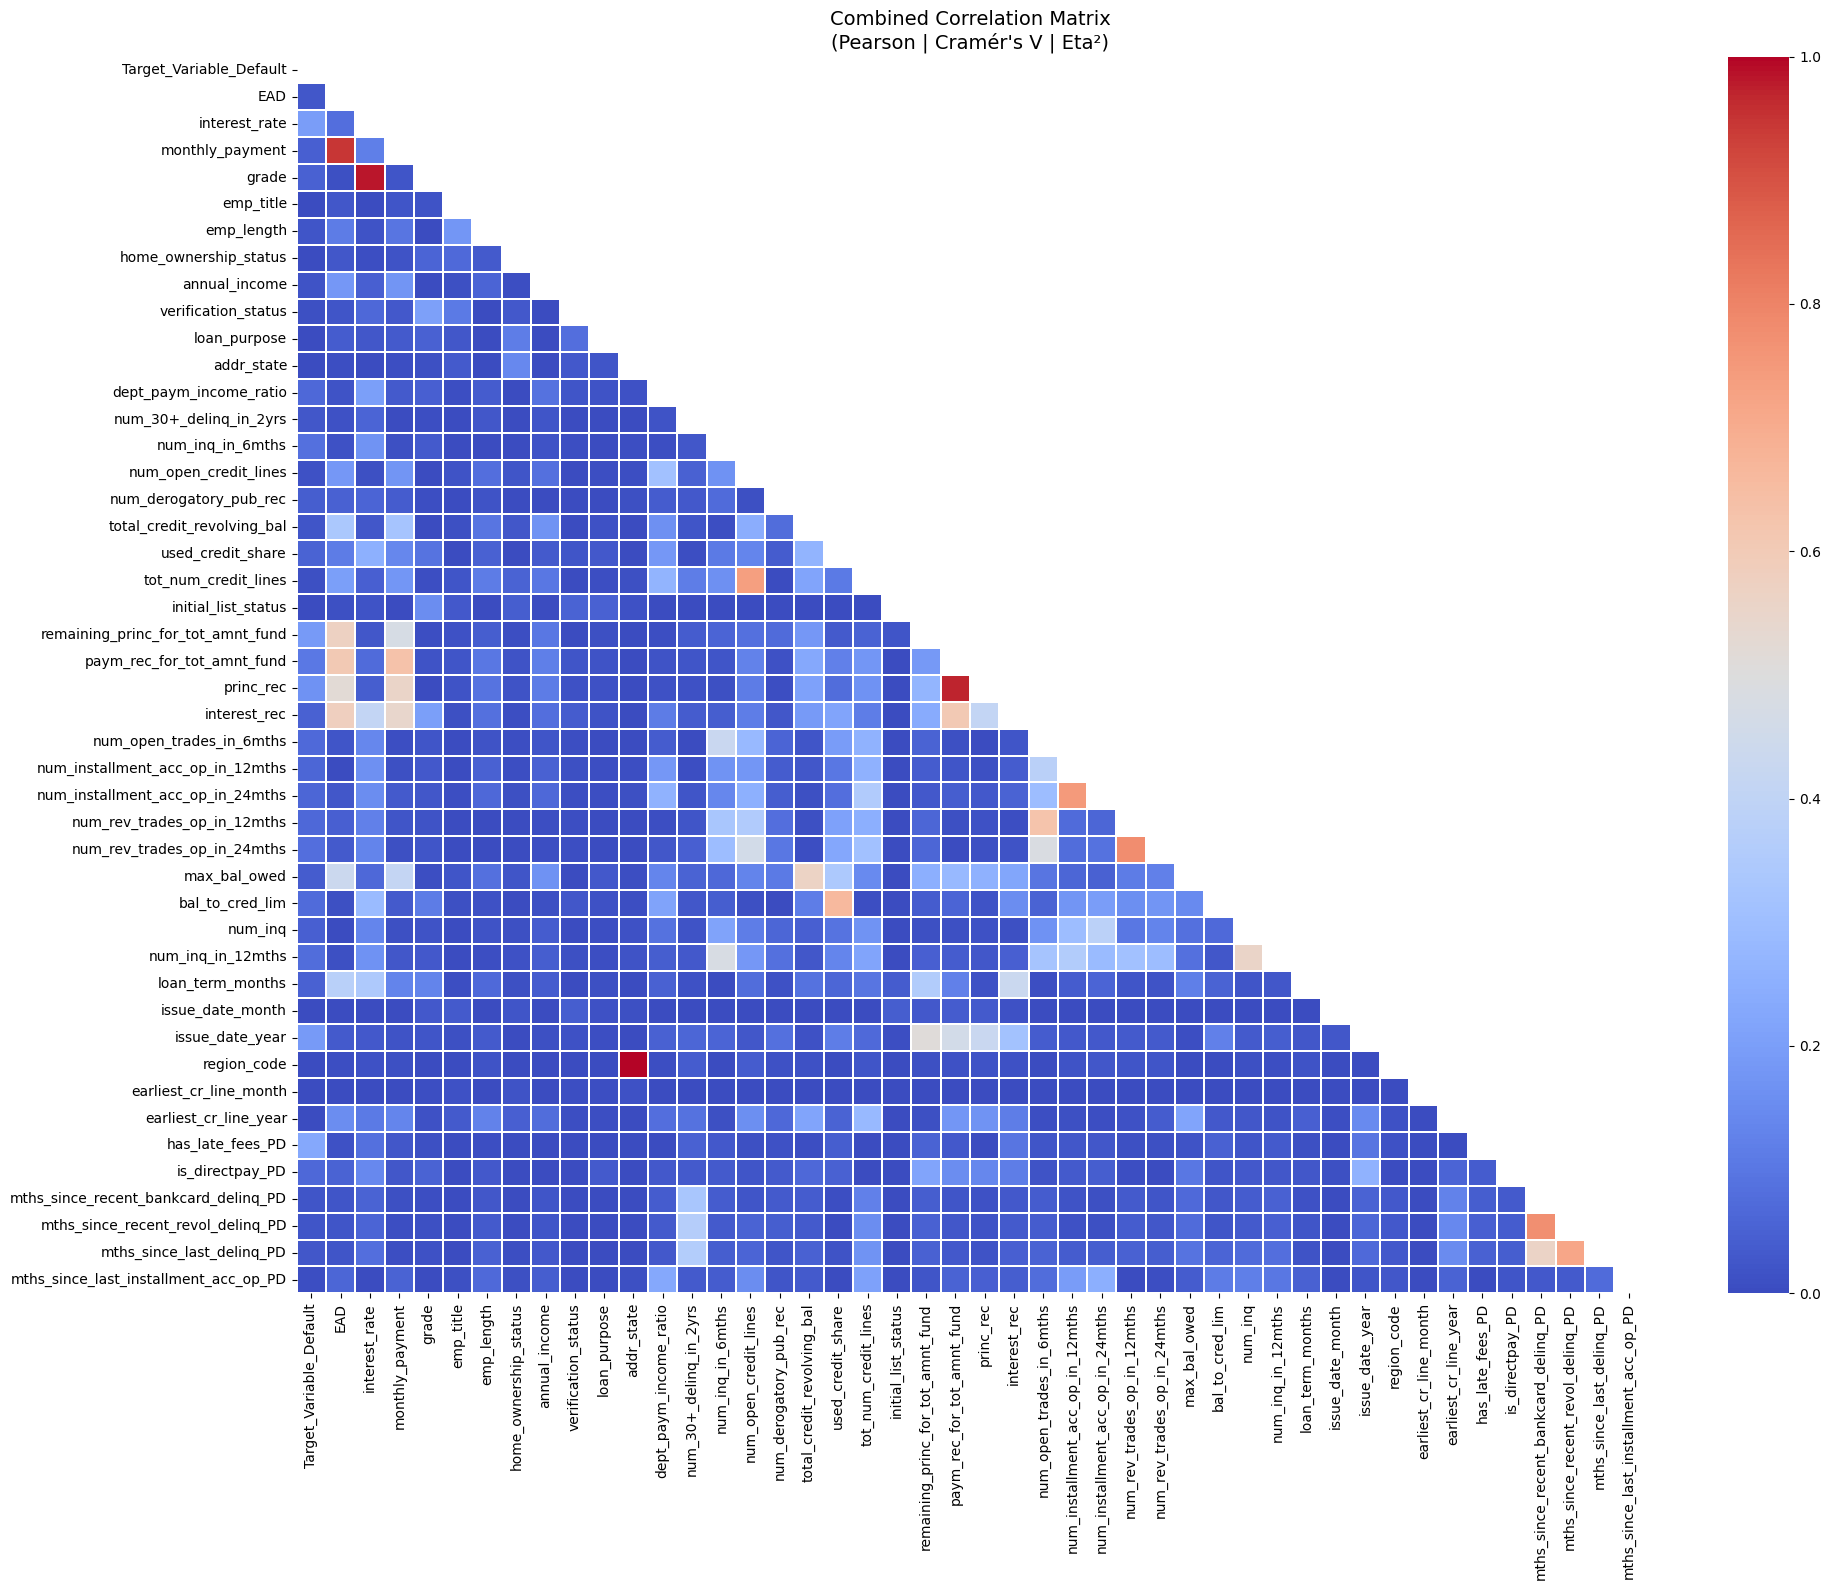

⚠ Pairs above threshold (0.75): 6
✓ Features recommended for removal: 6
  ['mths_since_recent_revol_delinq_PD', 'paym_rec_for_tot_amnt_fund', 'grade', 'num_rev_trades_op_in_24mths', 'EAD', 'addr_state']


In [7]:
# We obtain and plot the correlation matrix for the PD Model.
corr_matrix_PD = compute_plot_correlation_matrix(df_master_features[features_PD])

# Based on the correlation matrix and the mutual information, we identify the strongly correlated features and sort them by their mutual information value for a further discard.
pairs_PD, to_drop_PD = analyze_correlated_pairs(corr_matrix_PD, report=report_PD, threshold=0.75)

As we can see in the correlation matrix, there are strongly correlated features, which have been identified and chosen to be discarded by their mutual information. Nevertheless, we must understand and interpret these correlations since the mutual information is a good metric to based on the discard decision but in some cases it could not be enough.

So let's check `pairs_PD`.

In [ ]:
# We check pairs_PD
pairs_PD

The most important pair to consider here is `EAD` vs `monthly_payment`. We aready know EAD meaning and `monthly_payment` represents the monthly payment owed by the borrower if the loan originates. In this case `monthly_payment` captures in a better way the **relative debt burden** since if you are not able to pay the `monthly_payment` the loan goes default. So, for this reason, we will discard `EAD` as a predictive feature, and it won't be used to train the models, but it will be used for the Expected Loss at the end.

Having this in mind, we discard these features from `features_PD`.

In [ ]:
# We delete these features from features_DP.
features_PD = [col for col in features_PD if col not in to_drop_PD]

# We save the new features_PD.
with open("features_PD_AfterCorrelation.pkl", "wb") as f:
    pickle.dump(features_PD, f)

In [4]:
# In case we want to load the new features_PD.
with open("features_PD_AfterCorrelation.pkl", "rb") as f:
    features_PD = pickle.load(f)

## Correlation: LGD Model

We repeat the same logic with LGD Model.

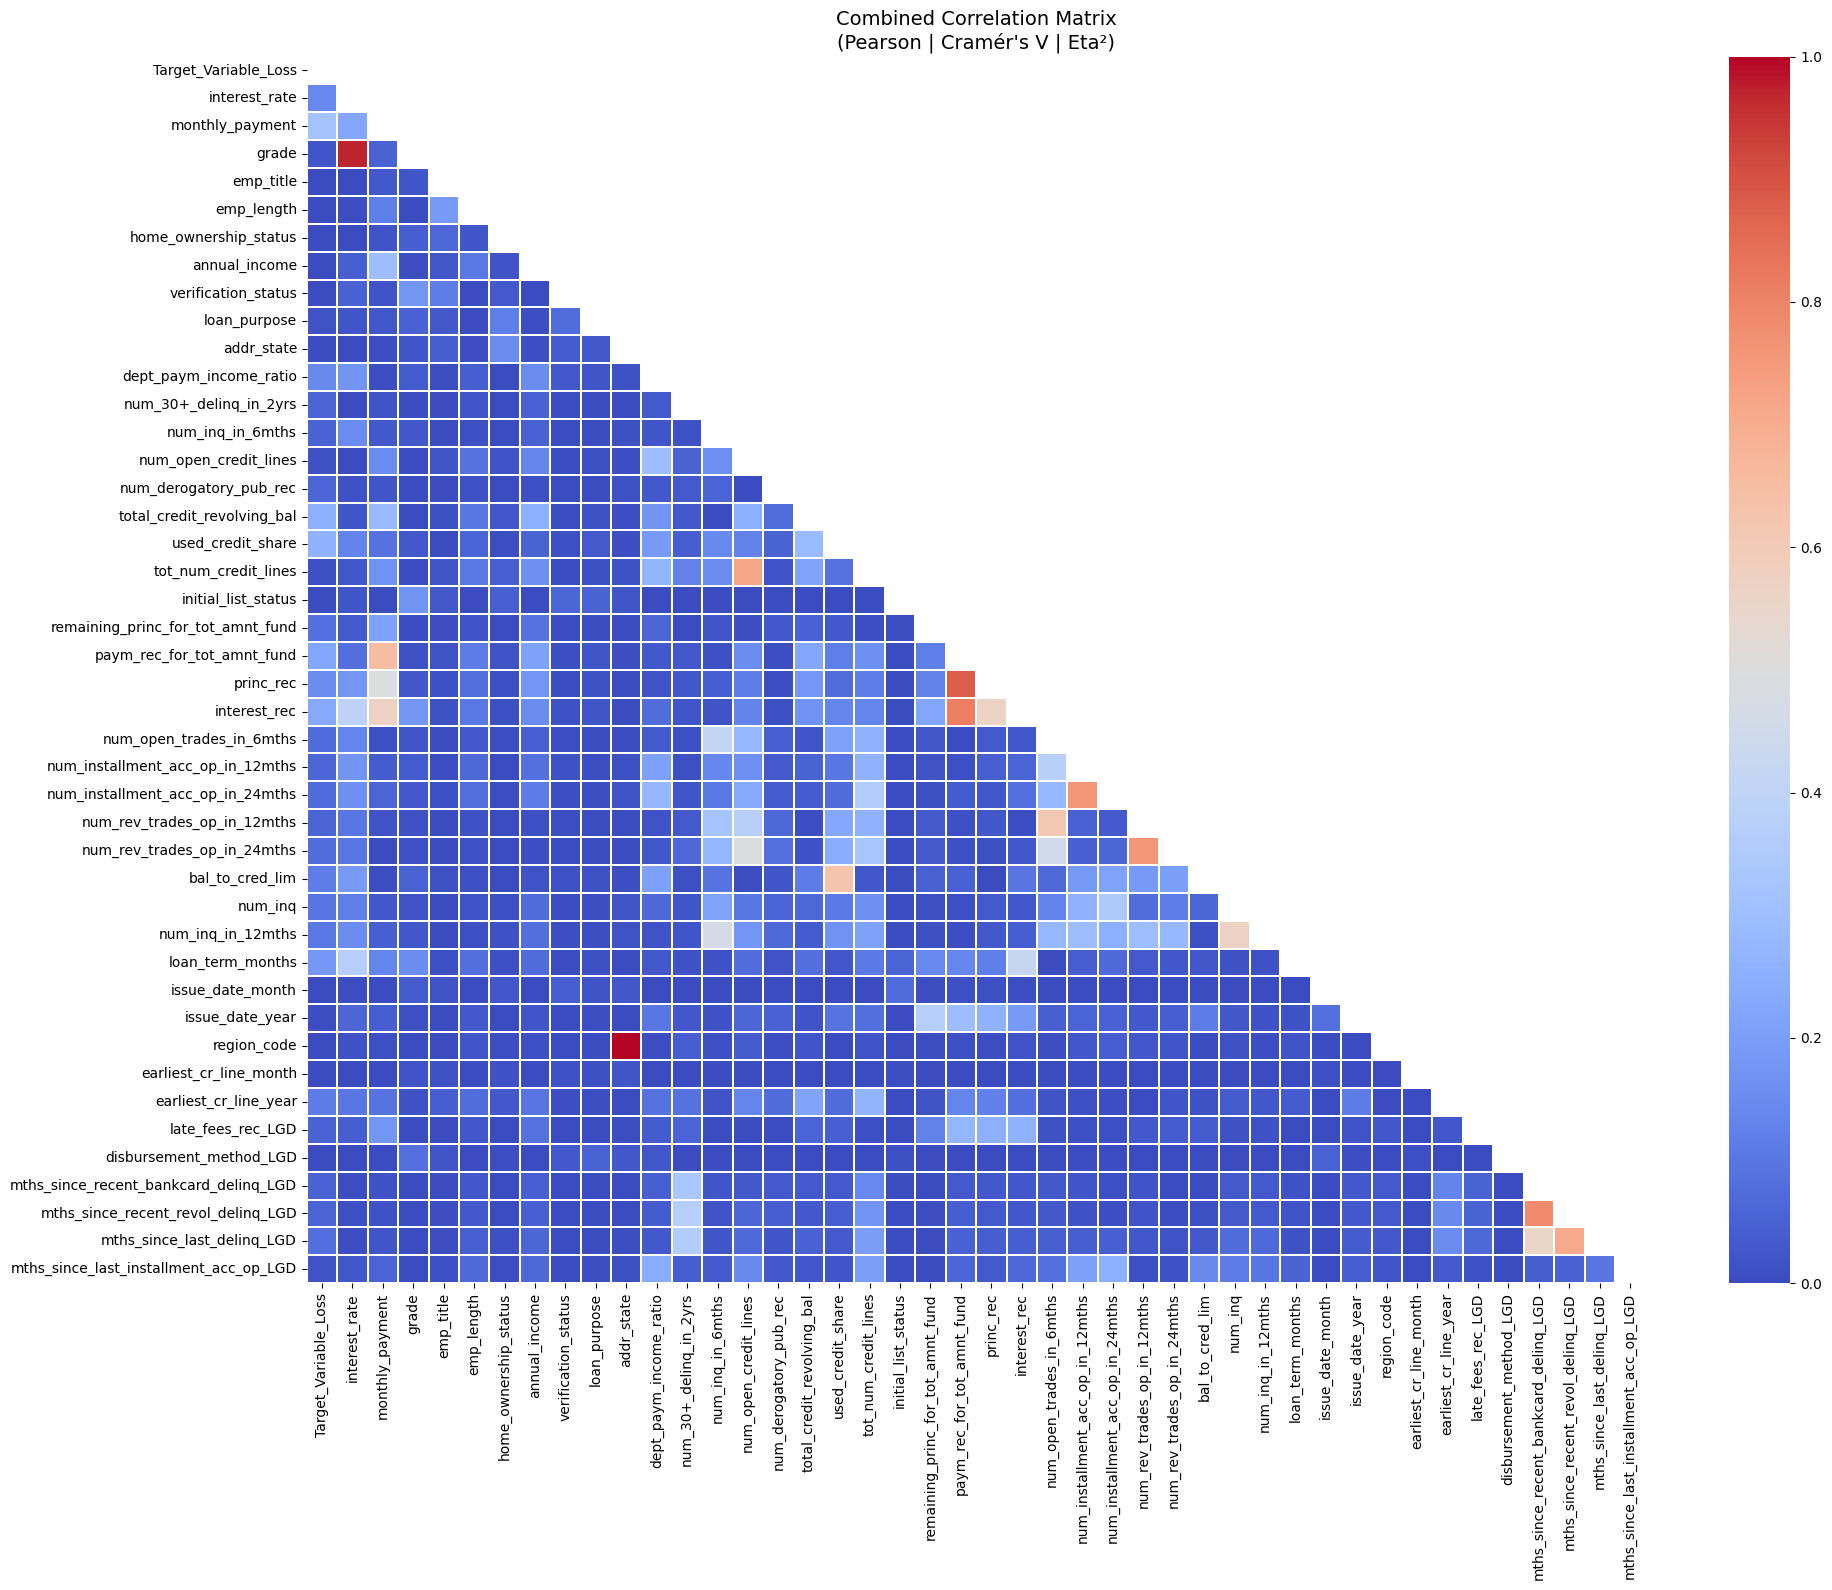

⚠ Pairs above threshold (0.75): 7
✓ Features recommended for removal: 6
  ['paym_rec_for_tot_amnt_fund', 'grade', 'region_code', 'num_rev_trades_op_in_12mths', 'num_installment_acc_op_in_12mths', 'mths_since_recent_bankcard_delinq_LGD']


In [10]:
# We obtain and plot the correlation matrix for the LGD Model.
corr_matrix_LGD = compute_plot_correlation_matrix(df_master_features.loc[df_master_features["Target_Variable_Default"]==1,features_LGD])

# Based on the correlation matrix and the mutual information, we identify the strongly correlated features and sort them by their mutual information value for a further discard.
pairs_LGD, to_drop_LGD = analyze_correlated_pairs(corr_matrix_LGD, report=report_LGD, threshold=0.75)

Following the same logic, let's check `pairs_LGD`.

In [ ]:
# We have a look to pairs_LGD.
pairs_LGD

Here again we identify strongly correlated features with no further comments about them. So, we discard them from `features_LGD`.

In [11]:
# We delete these features from features_LGD.
features_LGD = [col for col in features_LGD if col not in to_drop_LGD]

# We save the new features_LGD.
with open("features_LGD_AfterCorrelation.pkl", "wb") as f:
    pickle.dump(features_LGD, f)

In [5]:
# In case we want to load the new features_LGD.
with open("features_LGD_AfterCorrelation.pkl", "rb") as f:
    features_LGD = pickle.load(f)

# Exploratory Feature Selection via XGBoost

Before performing deep data cleaning on all remaining features, an exploratory XGBoost model is trained to rank features by predictive importance. This avoids spending time cleaning features that ultimately contribute little to the model.

The function trains a fast XGBoost model (industry standard because of well-behaved with median imputations and untreated outliers) with standard hyperparameters (no tuning) on a stratified sample of the data. Its sole purpose is to rank features, not to produce the final model. Three tree-based importance metrics are computed:

- **Weight:** number of times a feature is used in splits. Biased toward high-cardinality features, used only as a secondary reference.
- **Gain:** average improvement in the objective function per split. Biased toward high-cardinality continuous variables, which accumulate more gain mechanically due to the higher number of available split points. Retained for comparison and as a fast screening reference.
- **Cover:** average number of samples affected per split. Complementary to gain.

### Dual cutoff criterion: Gain vs SHAP

Two parallel cutoff criteria are computed and compared, each combining two methods:

1. **80% cumulative importance:** features that together explain 80% of the total importance (gain or SHAP respectively).
2. **Elbow method:** point of maximum curvature in the importance curve (second derivative). Used as a lower bound given its sensitivity to noise in irregular curves.

The most conservative cutoff (the one that retains more features) is selected for each criterion.

**Gain-based cutoff** is computed first as a fast reference. Its known limitation is that it can undervalue categorical features with few categories, since they have fewer split opportunities and therefore accumulate less gain regardless of their actual predictive value.

**SHAP-based cutoff** is the primary selection criterion. SHAP values (SHapley Additive exPlanations, Lundberg et al. 2018) measure the marginal contribution of each feature to the prediction, averaged across all instances and all possible feature coalitions. This gives SHAP two key advantages over gain:

- **No cardinality bias:** importance is measured against the prediction, not against tree structure. A binary feature and a continuous feature are evaluated on equal terms.
- **Consistency:** if a feature improves the model, its SHAP importance never decreases. Gain does not guarantee this property.

SHAP values are computed via TreeSHAP, an exact algorithm that exploits the tree structure to reduce complexity from O(2ⁿ) to O(T·L·D²), making it efficient even on large datasets. Values are computed on a subsample of the test set (default: 50,000 rows), which is sufficient for a stable `mean(|SHAP|)` ranking.

### Performance validation

The reduced model is retrained using only the selected features and its performance is compared against the full model. If degradation exceeds 1 AUC point (classification) or 5% RMSE (regression), the cutoff is automatically expanded by one feature at a time until the degradation falls within the acceptable threshold.

## Exploratory XGBoost: PD Model & LGD Model

As described above, we will reduce the features number based on and exploratory XGBoost model for the PD Model and LGD Model.

Before training the model we must check the features in order to avoid data leakage, since we could have features that give information once the loan is default and we must not train the PD model with them, as they will introduce a bias in PD Model with information from posterior events to default loan. These features are:

1. `princ_rec`: This feature represents the principal received to date, which means the amount of money recovered once the loan is default.
2. `interest_rec`: This features represents the interest received to date, which means the amount of money interest recovered once the loan is default.
3. `remaining_princ_for_tot_amnt_fund`: This feature represents the remaining outstanding principal for total amount funded, which means the money left to recover once the loan is default.
4. `has_late_fees_PD`: This feature represents the late fees received to date, so it includes late fees in default loans.
So, these features must not be included in the exploratory XGBoost for the PD Model.

A part from data leakage features there exist other features that could introduce a bias in the model because of their statistical bias.

1. `issue_date_year`: This feature represents the year which the loan was funded. This feature is a perfect example of **survival bias** since the most recent loans have no time to be default so the model would learn that the most recent the loan is, smaller is the probability of default, which is a clear survival bias, since one broke person could ask for a loan 1 month before the data is collected, default the loan 2 months after and still the model would give a low probability of default. In fact the percentage of default loans is 18.56% in 2015, 16.76% in 2016, 10.47% in 2017 and 2.92% in 2018, which not implies an improvement of client risk profile, but a survival bias.
2. `issue_date_month`: This feature represents the month which the loan was funded. The cross-tabulation of default rate by year and month confirms that the apparent monthly
seasonality is an artifact of the same truncation: December 2016 has a default rate of 14.90%, while December 2018 has 0.29%. A difference of that magnitude cannot be explained
by seasonality, it reflects the fact that loans issued in late 2018 had days or weeks of history at the dataset cutoff date, making it structurally impossible for them to have
defaulted yet. The hypothesis that certain months carry higher financial stress, and therefore higher default risk, is economically plausible. January and February, for instance, could reflect post-holiday financial strain. However, this dataset does not allow us to confirm or measure this effect cleanly. Within-year monthly variation is small (4-6 percentage points) compared to between-year variation driven by truncation (over 15 percentage points), meaning the truncation effect dominates any potential seasonal
signal. Including `issue_date_month` would require assuming that the monthly pattern observed is genuine seasonality rather than an artifact, an assumption this dataset
cannot support.

### Final Features: PD Model

→ Preparing data...
→ Sampling 500,000 rows from 1,257,995...
→ Training full exploratory model...
→ Full model — AUC: 0.7608 | Accuracy: 0.6625 | Precision: 0.1930 | Recall: 0.7285 | F1: 0.3052
→ Computing gain-based feature importance...
→ Computing SHAP values (sample: 50,000 rows)...
→ Gain-based cutoff:  19 features
→ SHAP-based cutoff:  15 features (primary criterion)


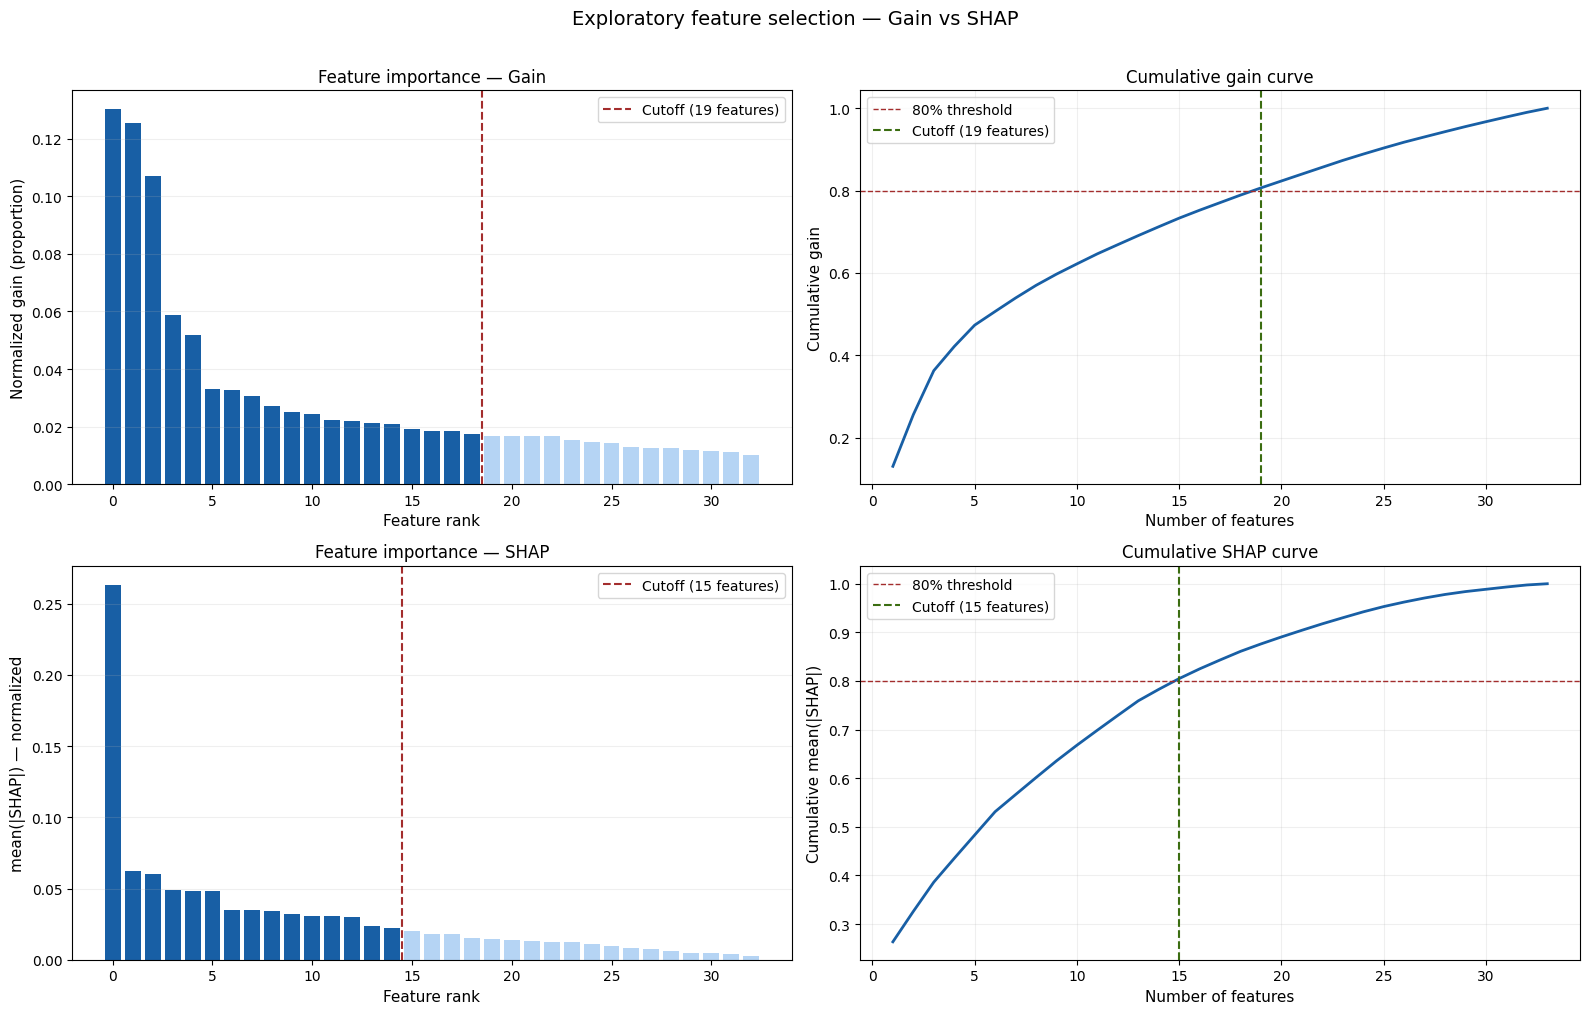

→ Generating SHAP summary plot...


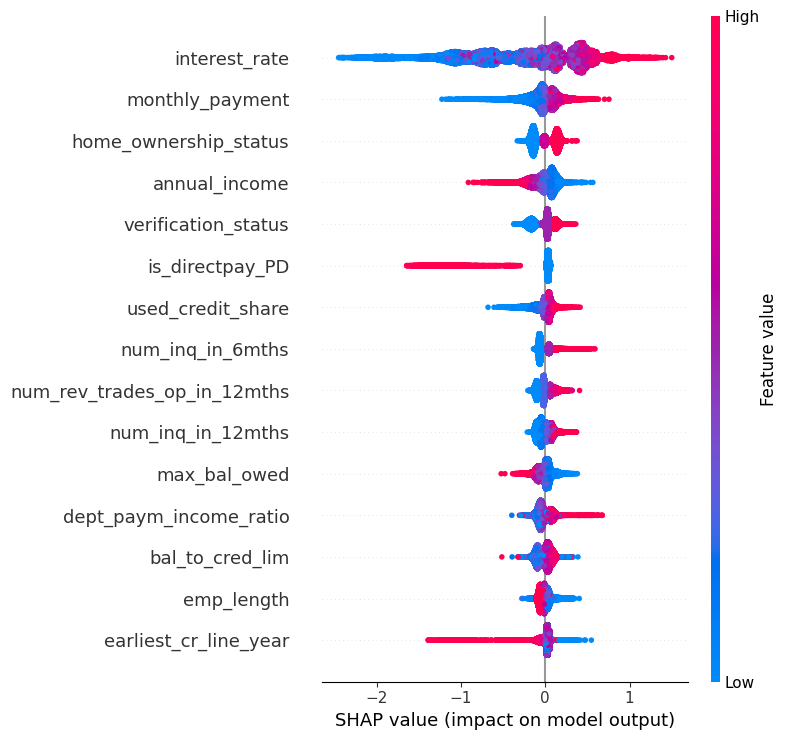


→ Validating reduced model (SHAP-based cutoff)...
  [15 features] AUC: 0.7607 | Accuracy: 0.6585 | Precision: 0.1922 | Recall: 0.7358 | F1: 0.3048 | Degradation: 0.0001

✓ Done. Selected 15 features (SHAP-based cutoff).
  Note: gain cutoff (19) and SHAP cutoff (15) diverged. Review importance_df to understand which features differ between criteria.


In [6]:
# We train a standard XGBoost model for the PD Model.
leakage_vars_PD = ['princ_rec', 'interest_rec', 'remaining_princ_for_tot_amnt_fund','has_late_fees_PD','issue_date_year','issue_date_month','Target_Variable_Default']
features_PD_model = [f for f in features_PD if f not in leakage_vars_PD]
importance_df_PD, selected_features_PD, metrics_PD = exploratory_feature_selection(
    df=df_master_features,
    features=features_PD_model,
    target='Target_Variable_Default',
    model_type='classification',
    sample_size=500_000
)

As we can see in SHAP values, the model is dominated by the standard features, as `interest_rate`, `monthly_payment`, `home_ownership_status` and `annual_income`. Also we can see how SHAP values of these features are totally logic, i.e., `interest_rate` has higher value to the right, meaning a higher interest rate implies more probability of default and `annual_income`has higher values to the left, meaning a higher annual income implies less probability of default.

As the features given by gain are 19 and by SHAP 15 we will have a look to `importance_df_PD` to check the reasons of this divergence.

In [7]:
# We check the divergence among both cut-offs.
cutoff_gain = metrics_PD['cutoffs']['gain_based']
cutoff_shap = metrics_PD['cutoffs']['shap_based']

gain_selected = importance_df_PD.sort_values('gain', ascending=False).head(cutoff_gain)['feature'].tolist()
shap_selected = importance_df_PD.sort_values('shap_mean_abs', ascending=False).head(cutoff_shap)['feature'].tolist()

in_gain_not_shap = [f for f in gain_selected if f not in shap_selected]
in_shap_not_gain = [f for f in shap_selected if f not in gain_selected]

print("En gain pero no en SHAP:", in_gain_not_shap)
print("En SHAP pero no en gain:", in_shap_not_gain)

En gain pero no en SHAP: ['initial_list_status', 'num_derogatory_pub_rec', 'loan_term_months', 'num_installment_acc_op_in_12mths', 'emp_title', 'num_open_trades_in_6mths', 'mths_since_last_delinq_PD']
En SHAP pero no en gain: ['annual_income', 'used_credit_share', 'earliest_cr_line_year']


As we said at the begining of this section, the gain metric equally evaluates binary and continuous features as `num_derogatory_pub_rec` and `initial_list_status` introducing a bias in the decision.

So finally, the features we will analyze and clean in deep for the PD Model are the following.

In [ ]:
# We identify the final features of the PD Model for EDA and feature engineering.
features_PD = selected_features_PD.copy()

### Final Features: LGD Model

Following the same logic as in the case of PD Model, we identify the most important features for LGD Model but in this case we some changes.

The default threshold of 0.80 is calibrated for a binary classification target with a relatively clean signal: a loan either defaults or it doesn't. In that setting, a small
number of features tends to explain most of the predictive variance, and the cumulative SHAP curve reaches a clear inflection point before 80%.

The LGD target (`Target_Variable_Loss = 100 * max_bal_owed / funded_amnt`) behaves differently for two structural reasons:

**The target is continuous and intrinsically noisy.** Loss severity at default depends on a combination of factors — outstanding balance, collateral recovery, borrower negotiation, macroeconomic conditions at the time of default — many of which are not directly observable in the dataset. This noise distributes predictive signal more evenly across features: no single variable dominates, and many contribute modestly but genuinely.

**The population is a filtered subset.** The LGD model trains only on defaulted loans (~128k rows vs ~1.3M for PD). Within this subset, the range of variation in most features
is compressed relative to the full portfolio — borrowers who defaulted are more homogeneous than borrowers in general. This compression further flattens the SHAP importance curve.

The combined effect is that the cumulative SHAP curve for LGD rises gradually and does not reach a natural inflection point until approximately 90% of cumulative importance. Applying the 80% threshold cuts the curve mid-slope, at a point where it still has meaningful upward gradient — as confirmed visually in the cumulative SHAP plot, where the curve
continues rising with appreciable slope well past the 80% mark.

Using `cumulative_gain_threshold = 0.90` moves the cutoff to where the curve genuinely begins to flatten, recovering features with real but moderate predictive contribution that
the 80% threshold incorrectly discarded.

→ Preparing data...
→ Sampling 120,000 rows from 127,977...
→ Training full exploratory model...
→ Full model — RMSE: 23.0101 | MAE: 14.0610 | R²: 0.6524
→ Computing gain-based feature importance...
→ Computing SHAP values (sample: 24,000 rows)...
→ Gain-based cutoff:  21 features
→ SHAP-based cutoff:  9 features (primary criterion)


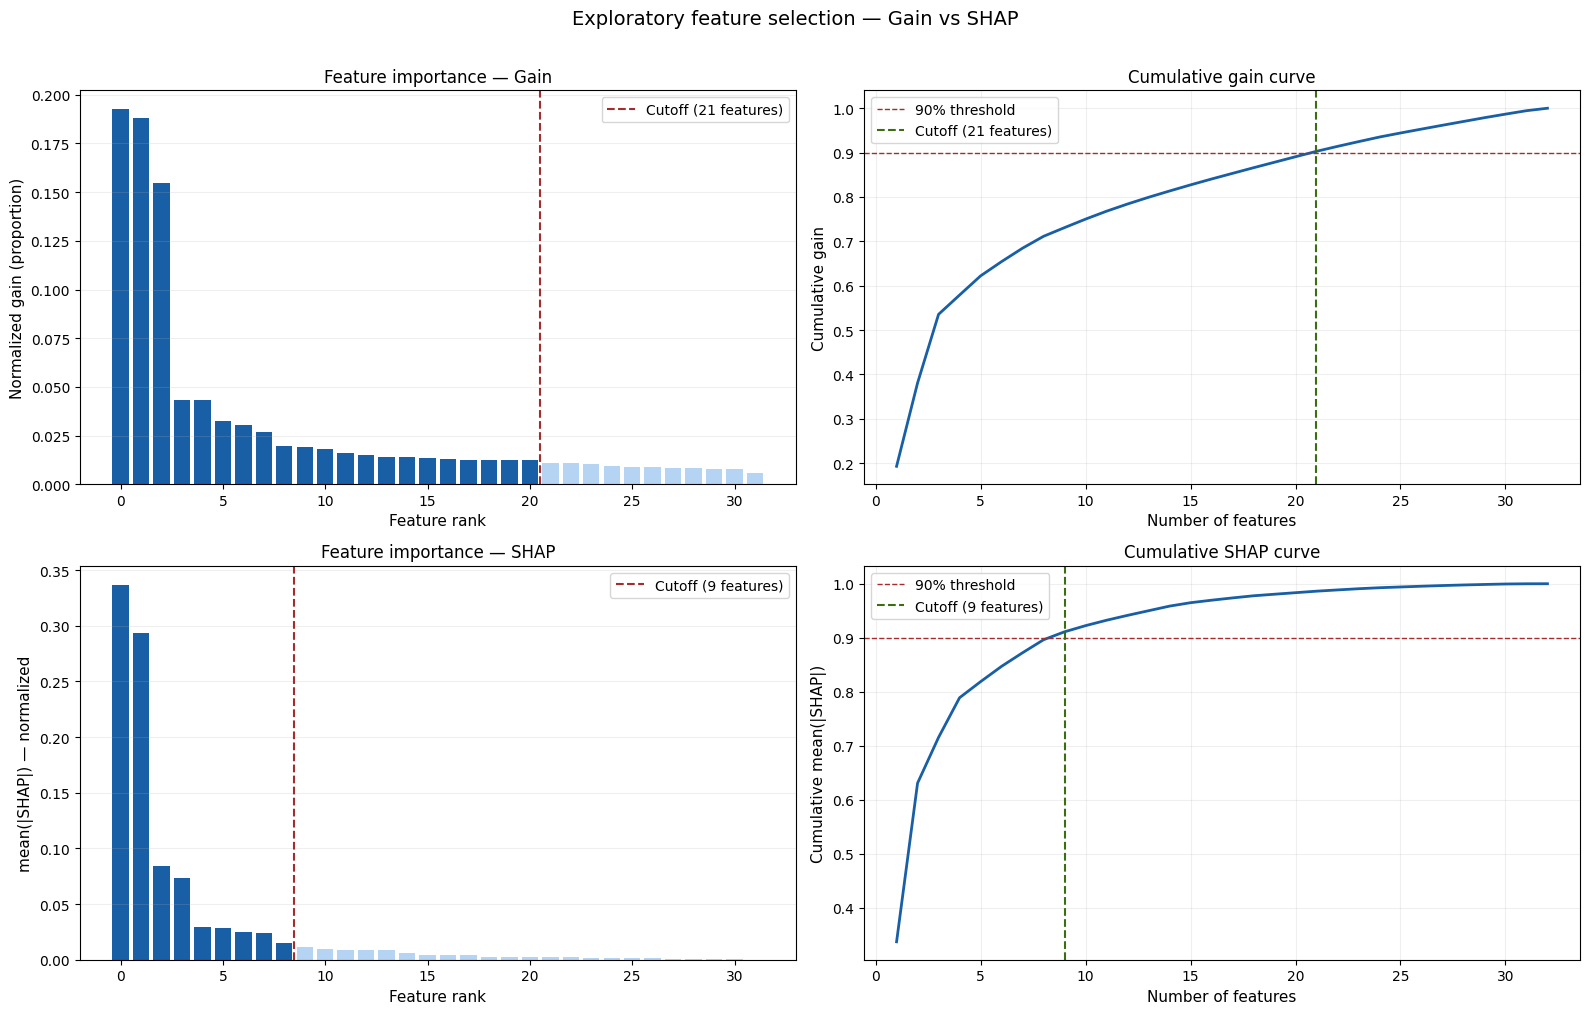

→ Generating SHAP summary plot...


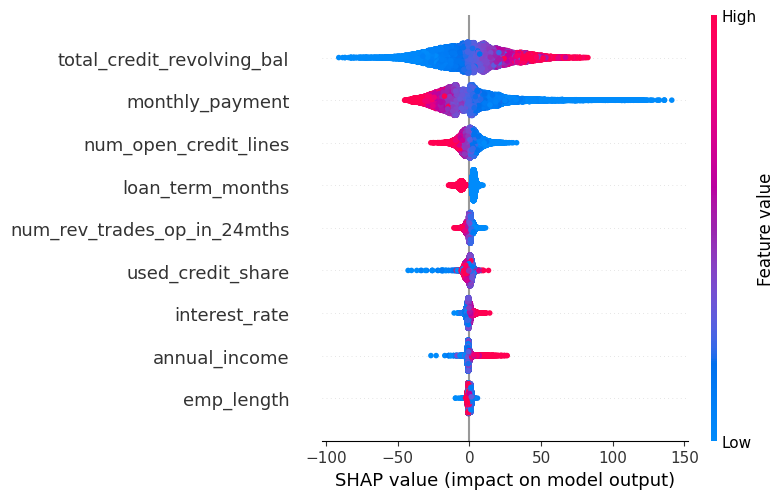


→ Validating reduced model (SHAP-based cutoff)...
  [9 features] RMSE: 23.1429 | MAE: 14.2007 | R²: 0.6483 | Degradation: 0.58%

✓ Done. Selected 9 features (SHAP-based cutoff).
  Note: gain cutoff (21) and SHAP cutoff (9) diverged. Review importance_df to understand which features differ between criteria.


In [13]:
# We train a standard XGBoost model for the LGD Model.
leakage_vars_LGD = ['princ_rec', 'interest_rec', 'remaining_princ_for_tot_amnt_fund','has_late_fees_PD','issue_date_year','issue_date_month','Target_Variable_Loss']
features_LGD_model = [f for f in features_LGD if f not in leakage_vars_LGD]
importance_df_LGD, selected_features_LGD, metrics_LGD = exploratory_feature_selection(
    df=df_master_features[df_master_features["Target_Variable_Default"]==1],
    features=features_LGD_model,
    target='Target_Variable_Loss',
    model_type='regression',
    sample_size=120_000,
    cumulative_gain_threshold=0.90
)

The SHAP-based cutoff at threshold 0.90 selected the following features. Each has a clear and direct economic interpretation in the context of loss severity given default.

| Feature | Justification |
|---|---|
| `total_credit_revolving_bal` | Total outstanding revolving balance at the time of default. Direct proxy for the amount exposed and potentially unrecoverable. The strongest predictor of loss magnitude. |
| `monthly_payment` | Reflects the contracted debt service. Higher payments imply larger outstanding principal, which directly determines the denominator of the recovery ratio. |
| `used_credit_share` | Credit utilization rate. High utilization at default indicates the borrower was already drawing on most available credit, leaving little buffer and increasing net loss. |
| `interest_rate` | Borrowers assigned higher rates carry higher-risk profiles and tend to have accumulated more interest on outstanding balances. Also a proxy for loan pricing tier. Correctly identified by SHAP but absent from gain-based ranking — a known artifact of gain's cardinality bias against continuous variables, and a validation of using SHAP as the primary criterion. |
| `loan_term_months` | Longer-term loans have more time to accumulate unpaid principal and interest before default. At any given point in the loan lifecycle, a 60-month loan will have a higher outstanding balance relative to the original amount than a 36-month loan. |
| `num_open_credit_lines` | Breadth of credit exposure. More open lines imply greater total indebtedness, which correlates with the severity of the financial distress that led to default and with the total balance at risk. |
| `num_rev_trades_op_in_24mths` | Recent revolving account activity. Captures whether the borrower was actively using revolving credit in the period leading up to default, which relates to the trajectory of balance accumulation. |
| `annual_income` | Determines the borrower's repayment capacity and the relative weight of the outstanding debt. For a given outstanding balance, lower income implies lower recovery probability and higher effective loss. |
| `emp_length` | Proxy for income stability. While more directly relevant to PD, within the defaulted population it may capture systematic differences in financial resilience that affect the depth of default — borrowers with longer employment history may enter default at earlier stages of deterioration, with lower accumulated balances. |

`dept_paym_income_ratio` (debt-to-income ratio, DTI) did not cross the SHAP-based cutoff despite being a core metric in the Basel II/III framework for credit risk assessment. The
decision to add it manually rests on three arguments:

**Low correlation with features already in the model.** The correlation matrix computed over the defaulted loans subset shows no high correlation between `dept_paym_income_ratio`
and either `annual_income` or `monthly_payment`. This rules out the most common reason for a variable to be suppressed by SHAP: redundancy with a correlated feature that absorbs its signal. The DTI ratio captures something that neither absolute income nor absolute payment size captures individually — the structural relationship between debt burden and repayment
capacity.

**Economic interpretability and regulatory standing.** DTI is one of the most widely used metrics in retail credit risk modeling and is explicitly referenced in Basel internal
ratings-based (IRB) approaches as a relevant input for loss estimation. A model that excludes it without a strong statistical justification would require explicit documentation
of that exclusion in any regulatory or audit context.

**Consistent with the project's feature selection philosophy.** As stated in the README, the algorithmic cutoff has known limitations: it can undervalue variables that are
informative in combination with others, or that are eclipsed by correlated variables at the margin. In regulated credit models, every feature must be both statistically supported and economically justifiable. The final feature set is always the result of both statistical evidence and domain knowledge. `dept_paym_income_ratio` satisfies the economic criterion and is not contradicted by the statistical evidence — its absence from the SHAP cutoff reflects a marginal ranking position, not a demonstrated absence of signal.

As a result, the final features for the LGD Model are the following.

In [ ]:
# We identify the final features of the LGD Model for EDA and feature engineering.
features_LGD = selected_features_LGD + ["dept_paym_income_ratio"]

# Checkpoint: Final Features and Dataframe for EDA and Feature Engineering

In [18]:
# We save the dataframe and the features previously to EDA and Feature Engineering.
with open("checkpoint_DataFrame_for_EDA.pkl", "wb") as f:
    pickle.dump({"df_master_features": df_master_features}, f)

with open("features_PD_for_EDA.pkl", "wb") as f:
    pickle.dump(features_PD, f)

with open("features_LGD_for_EDA.pkl", "wb") as f:
    pickle.dump(features_LGD, f)

In [3]:
# In case we want to load the dataframe and the features previously to EDA and Feature Engineering.
with open("checkpoint_DataFrame_for_EDA.pkl", "rb") as f:
    data = pickle.load(f)
df_master_features = data["df_master_features"]

with open("features_PD_for_EDA.pkl", "rb") as f:
    features_PD = pickle.load(f)

with open("features_LGD_for_EDA.pkl", "rb") as f:
    features_LGD = pickle.load(f)

# Workflow Design: Dual Pipeline Architecture for PD and LGD

## 1. Overview

The project trains two independent models, a classification model for Probability of Default (PD) and a regression model for Loss Given Default (LGD), which are then combined
to compute the Expected Loss (EL) of the loan portfolio:

```
EL = PD × LGD × EAD
```

Each model operates on a different population, uses a different feature set, and requires a different treatment of those features. This asymmetry demands a careful inference
architecture to ensure that the transformations applied at inference time are strictly consistent with those applied during training.

---

## 2. The Core Problem: Two Models, Two Populations

The PD and LGD models are trained on fundamentally different subsets of the data:

- **PD model** — trained on the full loan portfolio (~1.3M observations). The target is binary: whether a loan defaulted or not.
- **LGD model** — trained exclusively on defaulted loans (~128k observations). The target is continuous: the percentage of the outstanding balance that was lost upon default.

This population asymmetry has a direct consequence for feature treatment. Even when both models share a feature (e.g. `annual_income`), the statistical properties of that feature
differ between the full population and the defaulted subset. Borrowers who defaulted tend to have lower and more compressed income distributions than the general population. As a
result:

- The median used for imputation will differ between models.
- The 99th percentile used for outlier capping will differ between models.
- Any transformation calibrated on the full population and applied to the LGD model would introduce a systematic mismatch between training and inference.

The treatment of each feature must therefore be fitted independently on each model's training population, and those fitted parameters must be stored and reused consistently
at inference time.

---

## 3. Architecture: Two Independent Feature Pipelines

To enforce this consistency, a custom `FeaturePipeline` class is implemented for each model. The class follows the standard `fit` / `transform` contract:

- **`fit(df)`** — computes and stores all treatment parameters (medians, percentiles, encoding maps, flags) from the training population. This method is called once, on the
training data only.
- **`transform(df)`** — applies the stored parameters to any dataset. This method never recomputes parameters; it only executes the decisions made during `fit`.
- **`fit_transform(df)`** — convenience method that chains both steps.

Two separate classes are defined — `FeaturePipeline_PD` and `FeaturePipeline_LGD` — rather than a single shared class, because the treatment logic itself may differ between models. A feature that requires a log transformation in PD may not require it in LGD if the distribution within the defaulted population is already approximately normal. Using two explicit classes makes every treatment decision visible and auditable, with no shared logic that could mask model-specific choices.

```python
pipeline_PD  = FeaturePipeline_PD()
pipeline_LGD = FeaturePipeline_LGD()
```

Each pipeline object is an independent container. Its internal `params` dictionary is populated during `fit` and is specific to the population it was fitted on. The two objects
do not share state.

---

## 4. Training Workflow

The source of truth throughout the project is `df_master_features`, which is never modified. All downstream dataframes are derived from it via explicit copies:

```python
# PD training population — full portfolio
df_PD = df_master_features[features_PD + ['Target_Variable_Default']].copy()

# LGD training population — defaulted loans only
df_LGD = df_master_features.loc[
    df_master_features['Target_Variable_Default'] == 1,
    features_LGD + ['Target_Variable_Loss']
].copy()
```

Each pipeline is fitted and applied to its corresponding training population:

```python
df_PD_clean  = pipeline_PD.fit_transform(df_PD)
df_LGD_clean = pipeline_LGD.fit_transform(df_LGD)
```

At this point, `pipeline_PD.params` contains the treatment parameters computed over the full portfolio, and `pipeline_LGD.params` contains the parameters computed over the
defaulted subset. Both pipelines are serialized to disk after fitting:

```python
pickle.dump(pipeline_PD,  open('pipeline_PD.pkl',  'wb'))
pickle.dump(pipeline_LGD, open('pipeline_LGD.pkl', 'wb'))
```

---

## 5. Inference Workflow

At inference time, both pipelines are applied to the full original dataset. This is the step that produces the PD and LGD estimates for every loan in the portfolio, which are
then combined into the Expected Loss calculation.

```python
df_inference = df_master_features.copy()

# PD — probability of default for every loan
df_inference['PD'] = model_PD.predict_proba(
    pipeline_PD.transform(df_inference[features_PD])
)[:, 1]

# LGD — expected loss severity for every loan
df_inference['LGD'] = model_LGD.predict(
    pipeline_LGD.transform(df_inference[features_LGD])
)

# Expected Loss
df_inference['EL'] = df_inference['PD'] * df_inference['LGD'] * df_inference['EAD']
```

Two aspects of this step warrant explicit justification:

**PD is inferred over the full portfolio.** This includes loans that are known to have defaulted. For these loans PD ≈ 1 by definition, but running them through the model
produces a score consistent with the rest of the portfolio rather than hardcoding a value, which is preferable for portfolio-level aggregation and stress testing.

**LGD is inferred over the full portfolio using `pipeline_LGD`.** This means that non-defaulted loans, which were not part of the LGD training population, are transformed
using the parameters fitted on defaulted loans. This is correct and intentional: the LGD model operates in the feature space of defaulted borrowers, and all inputs to that model
must be expressed in that same space, regardless of whether the loan has actually defaulted. Applying `pipeline_PD` parameters to LGD inference would introduce an inconsistency between the space in which the model was trained and the space in which it is asked to predict.

---

## 6. Why This Architecture and Not a Simpler One

The natural alternative would be to apply a single shared preprocessing step to `df_master_features` and feed the result into both models. This approach fails for the
reason described in section 2: a single preprocessing fitted on the full population produces incorrect treatment parameters for the LGD model, whose training population has
systematically different distributional properties.

A second alternative would be to apply `pipeline_LGD` only to defaulted loans and leave non-defaulted loans untransformed or transformed with `pipeline_PD`. This would require
merging two differently-transformed versions of the same features into a single dataframe, which is both operationally fragile and conceptually incorrect, it implies that the LGD
model should behave differently depending on whether the input loan has defaulted, which contradicts the purpose of the model.

The dual pipeline architecture avoids both failure modes. It is the standard approach in production credit risk systems, where each model in the PD/LGD/EAD chain maintains its
own preprocessing state, fitted on its own population, and applied consistently at every inference call.

---

## 7. Known Limitations

**Out-of-population inference for LGD.**
The LGD model is trained exclusively on defaulted loans and has never observed a non-defaulted borrower during training. When applied to the full portfolio at inference
time, it extrapolates outside its training population for every non-defaulted loan. This means the LGD estimates for non-defaulted loans are not empirically grounded, the model
is estimating what the loss severity *would be* if those loans defaulted, based on patterns learned from borrowers who actually did.

This limitation is inherent to the problem structure and cannot be resolved by any preprocessing or architectural choice. It is present in every LGD model trained under the
standard Basel IRB approach, and is explicitly acknowledged in the regulatory literature. The rationale for accepting it is twofold:

First, the impact on the Expected Loss calculation is bounded. For non-defaulted loans, LGD is multiplied by a low PD estimate. Even if the LGD estimate carries meaningful
extrapolation error, its contribution to EL is dampened proportionally to PD. The loans where LGD error matters most, those with high PD, are precisely those whose feature
profiles are closest to the defaulted population, and therefore where extrapolation error is smallest.

Second, this is the industry-standard approach. In Basel II/III internal ratings-based (IRB) models, LGD is estimated over the full portfolio using a model trained on the
defaulted subset. The resulting estimates are used for regulatory capital calculation and provisioning. The bias introduced by out-of-population inference is a known and accepted
limitation within the regulatory framework, provided it is documented and monitored.

**Distributional shift between `pipeline_LGD` parameters and the non-defaulted population.**
The capping percentiles, imputation values, and other treatment parameters stored in `pipeline_LGD` are computed on the defaulted subset, which has systematically different
distributional properties from the full portfolio (lower incomes, higher utilization, more compressed feature ranges). When these parameters are applied to non-defaulted loans,
features may be transformed into a slightly different range than they would be under `pipeline_PD`. This is intentional, it places the non-defaulted loans in the feature
space of the LGD model, but it implies that the LGD model is receiving inputs that are not fully representative of the non-defaulted population's natural distribution.

This effect is unavoidable given the population asymmetry and does not constitute a methodological error. It should however be monitored in production by comparing the
distribution of LGD predictions across the defaulted and non-defaulted subsets, and flagging any implausible estimates (e.g. negative LGD or LGD > 1 before clipping) for
review.



# EDA & Feature Engineering

As we said earlierin the Workflow Design, we will have two pipelines, one for PD Model and another for LGD Model. So, we will work independently of one another.

## PD Model

At first we will create a new dataframe to train the PD Model without introducing a bias in `df_master_features`, since we will infer both model over it.

In [ ]:
# Create a new dataframe for PD model.
df_PD = df_master_features[["Target_Variable_Default"] + features_PD].copy()

### 1. Initial audit

We will start showing the principal statistical descriptors of the features for por de PD Model.

In [30]:
# We show the principal descriptors of features for PD Model.
audit_PD = dataset_audit(df_PD[features_PD])
audit_PD

,dtype,n_unique,null_count,null_pct,min,max,mean,std,skew
feature,,,,,,,,,
interest_rate,float64,242,0,0.00,5.31,3.099000e+01,12.9138,5.0557,0.9178
monthly_payment,float64,71185,0,0.00,7.61,1.719830e+03,445.3846,274.6341,1.0485
home_ownership_status,str,4,0,0.00,NaN,NaN,NaN,NaN,NaN
annual_income,float64,58578,0,0.00,1900.00,1.100000e+08,81643.9040,139470.5104,464.6539
verification_status,str,3,0,0.00,NaN,NaN,NaN,NaN,NaN
is_directpay_PD,int64,2,0,0.00,0.00,1.000000e+00,0.0580,0.2337,3.7822
used_credit_share,float64,1245,0,0.00,0.00,1.838000e+02,47.0932,24.6155,0.1266
num_inq_in_6mths,int64,6,0,0.00,0.00,5.000000e+00,0.5137,0.8068,1.8198
num_rev_trades_op_in_12mths,float64,29,0,0.00,0.00,2.800000e+01,1.3181,1.5248,2.0109


In order to have a better knowlegde about the features to analyze outliers and NaNs, a brief description of each feature selected for the Probability of Default (PD) model,
grouped by economic category is included:

---

#### Loan Characteristics

**`interest_rate`**
Annual interest rate assigned to the loan at origination, expressed as a percentage. The interest rate is determined by the internal credit grade assigned to the borrower, which incorporates FICO score, debt-to-income ratio, and loan term among other factors. Higher rates indicate higher perceived risk at origination, making this feature a direct proxy for the lender's own ex-ante default assessment.

**`monthly_payment`**
Fixed monthly installment amount the borrower is contractually obligated to pay. Reflects the combined effect of loan amount, interest rate, and term. A high monthly payment
relative to the borrower's income increases debt service burden and, by extension, default probability.

**`is_directpay_PD`**
Binary flag indicating whether the borrower enrolled in automatic direct payment at origination. Borrowers who opt into automatic payment tend to be more financially
organized and less likely to miss payments due to oversight. Acts as a behavioral signal of financial discipline.

---

#### Borrower Financial Profile

**`annual_income`**
Self-reported gross annual income of the borrower at the time of application, in USD. Primary measure of repayment capacity. Higher income relative to debt obligations
reduces default probability. Note that this variable is self-reported and not always verified, which introduces measurement noise, partially addressed by `verification_status`.

**`dept_paym_income_ratio`**
Debt-to-income ratio (DTI): total monthly debt payments divided by gross monthly income, expressed as a percentage. One of the core metrics in retail credit risk assessment under
Basel II/III. Measures the structural burden of existing debt on the borrower's cash flow. A high DTI indicates limited capacity to absorb additional debt service and is a strong predictor of default.

**`emp_length`**
Number of years the borrower has been employed at their current employer, ranging from 0 to 10 (where 10 represents 10 or more years). Proxy for income stability and employment
security. Longer tenure reduces the probability of income disruption that could trigger default. NaN values in this variable are treated as unemployment rather than missing at
random, and are imputed with 0.

**`verification_status`**
Categorical variable indicating whether the borrower's income was verified by Lending Club at the time of application. Takes three values: not verified, source verified, and
verified. Borrowers whose income was not verified may have overstated their income, making their effective DTI higher than reported. Includes information about the reliability of other financial features in the model.

**`home_ownership_status`**
Categorical variable indicating the borrower's housing situation: own, mortgage, rent, or other. Homeownership, particularly with a mortgage, is associated with greater financial stability and lower default rates in retail lending. Renters tend to have higher mobility and less accumulated wealth, which correlates with higher default
probability.

---

#### Credit Utilization and Exposure

**`used_credit_share`**
Credit utilization rate: trevolving balance relative to all available credit, as reported by Lending Club. High utilization indicates the borrower is drawing heavily on available
credit, which signals financial stress and reduced capacity to absorb additional obligations.

**`max_bal_owed`**
Maximum current balance owed across all revolving accounts, in USD. Complements `used_credit_share` by capturing the absolute level of revolving debt rather than its
relative level. A borrower with a high absolute balance may be under significant financial pressure even if their utilization rate appears moderate due to high credit limits.

**`bal_to_cred_lim`**
Ratio of total balance to total credit limit across all accounts. Related to `used_credit_share` but computed over all account types rather than revolving accounts
only. Provides a broader measure of overall credit utilization and financial leverage.

---

#### Credit History and Inquiry Activity

**`earliest_cr_line_year`**
Year in which the borrower opened their first credit account. Proxy for the length of the borrower's credit history. A longer credit history provides more information about
the borrower's repayment behavior over different economic cycles and is generally associated with lower default probability. Borrowers with very short credit histories represent higher uncertainty.

**`num_inq_in_6mths`**
Number of credit inquiries in the last 6 months. Each inquiry represents a credit application made by the borrower. A high number of recent inquiries suggests the borrower
is actively seeking new credit, which may indicate financial stress or overleveraging. The 6-month window captures the most acute phase of credit-seeking behavior.

**`num_inq_in_12mths`**
Number of credit inquiries in the last 12 months. Broader version of `num_inq_in_6mths`, capturing a longer window of credit-seeking activity. The two variables together provide
information about both the intensity and the persistence of recent inquiry behavior. High values over 12 months with moderate values over 6 months suggest a sustained pattern of credit seeking rather than a single episode.

**`num_rev_trades_op_in_12mths`**
Number of revolving trade lines opened in the last 12 months. Measures recent expansion of revolving credit exposure. Opening multiple revolving accounts in a short period can
indicate financial stress, credit stacking behavior, or aggressive borrowing ahead of a deterioration in financial conditions.


### 2. Numeric features

We will have a look to the numeric features so see their distributions, which will helps us a lot identifying the outliers.

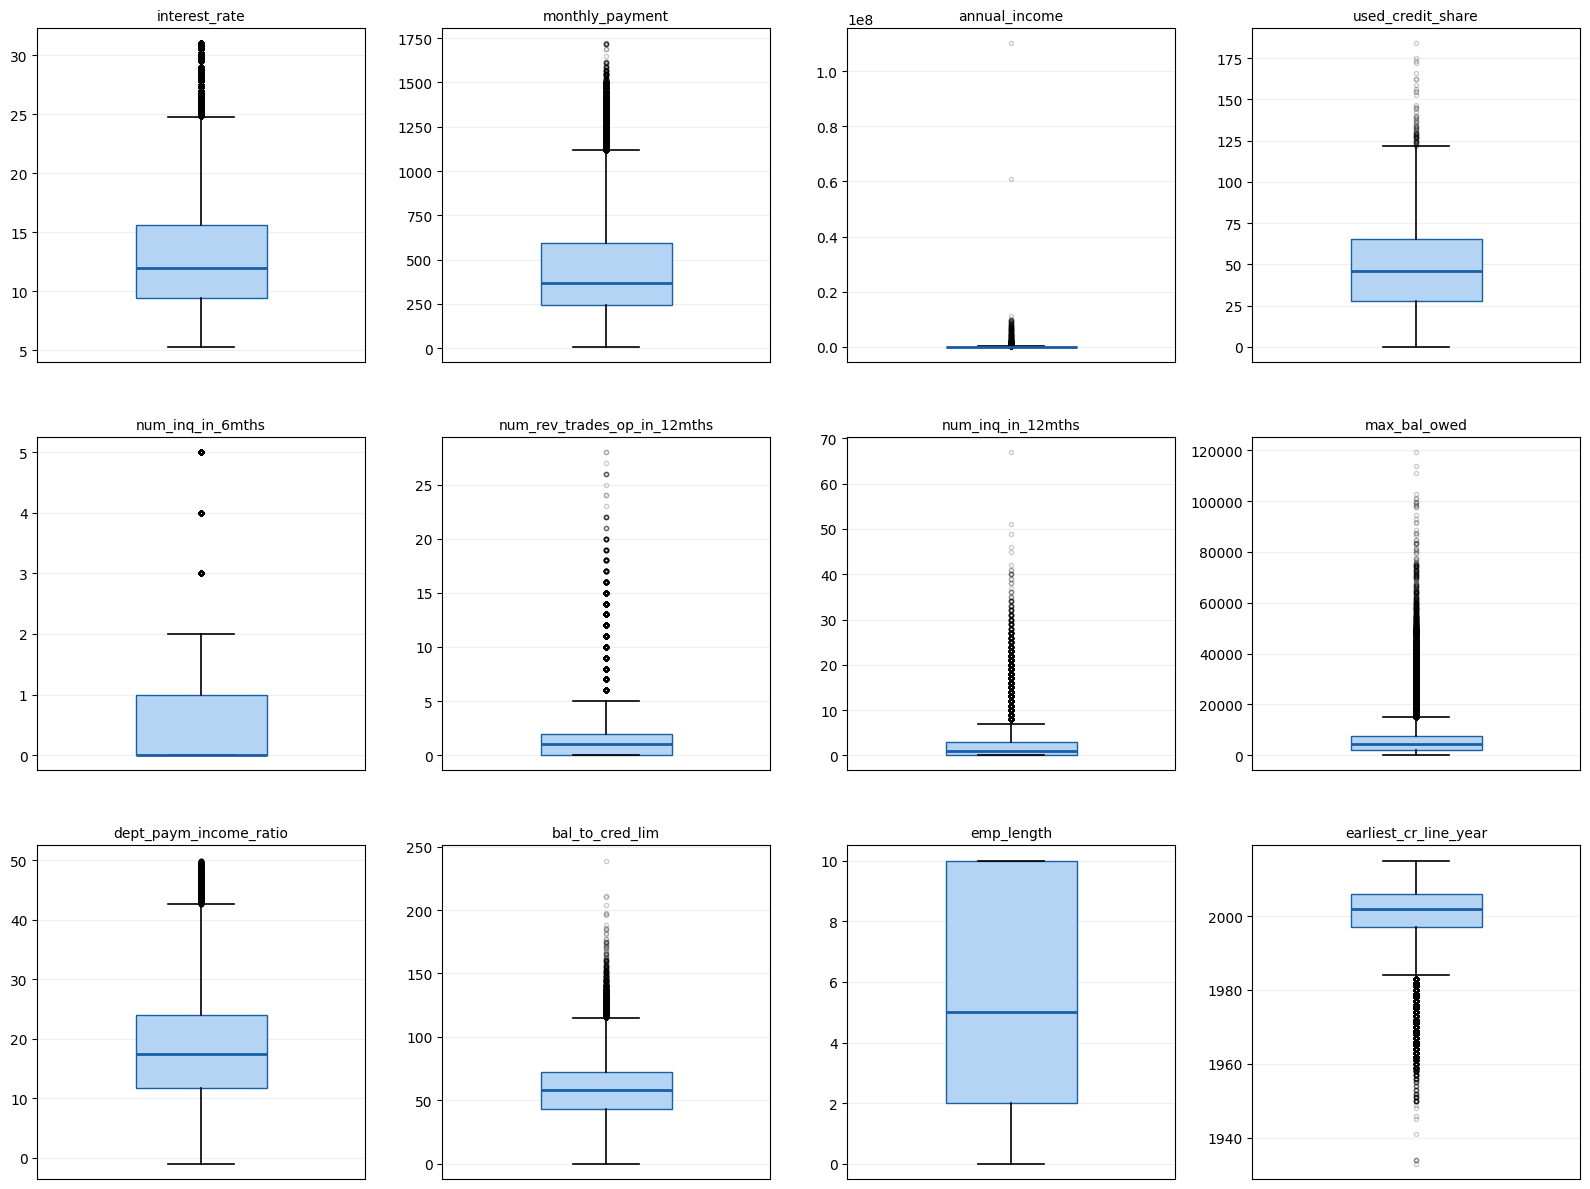

In [31]:
# We identify the numeric features in df_PD.
num_features_PD = df_PD[features_PD].select_dtypes(include=[np.number]).columns.tolist()

# The feature is_directpay_PD have been identified as numeric but we know it's categorical. As we clean it before, we remove it from num_features_PD.
num_features_PD.remove("is_directpay_PD")

# We plot the numeric features using boxplots.
plot_boxplots_list(df_PD, num_features_PD, cols=4)


#### 2.1 Numeric features: outliers & NaNs

The standard method for outlier detection in credit risk feature engineering is the interquartile range (IQR) method, originally proposed by Tukey (1977). For each feature,
two flagging thresholds are computed:

```
Moderate outlier:  value < Q1 - 1.5 * IQR  or  value > Q3 + 1.5 * IQR
Extreme outlier:   value < Q1 - 3.0 * IQR  or  value > Q3 + 3.0 * IQR
```

The 1.5 multiplier is the classical Tukey fence and flags values that deviate meaningfully from the bulk of the distribution. The 3.0 multiplier flags values that are genuinely
anomalous and difficult to explain under any reasonable data-generating process.

Both thresholds are computed for every feature, along with the count and percentage of observations falling in each zone. The percentage is the operative number for the
treatment decision.

---

The combination of the IQR-based flags and economic domain knowledge produces the following decision framework:

**Cap to p99 value is economically implausible:**
When `extreme_pct < 0.1%` and the flagged values are inconsistent with the economic context of the dataset (for example, `annual_income = 110,000,000` in a retail personal
loan portfolio where the 99th percentile is approximately 250,000), the values are treated as data entry errors or reporting artifacts. They are capped to the 99th percentile of the training populationhe. The threshold is conservative: only values that are both statistically extreme and economically implausible are capped.

**Do not treat value is plausible and extreme_pct is low:**
When `extreme_pct < 0.1%` and the flagged values are consistent with the economic context, the values are retained as genuine observations at the tail of the distribution.Removing or capping real data points introduces bias without improving model quality.

**Do not cap: consider log transformation:**
When `moderate_pct > 5%`, the feature has a heavy right tail that is not driven by a small number of anomalous values but by the natural shape of the distribution. Capping in this scenario would remove economically meaningful signal. The appropriate treatment is a log transformation, which compresses the tail and produces a more symmetric distribution
without discarding information.

**Apply domain judgment:**
When `moderate_pct` falls between 0.1% and 5%, the decision is not mechanical. The flagged values are reviewed against the economic interpretation of the feature and the
context of the loan portfolio. A value that is statistically moderate-extreme may be entirely plausible for a specific loan segment, or it may reflect a systematic reporting
issue. This zone is where domain knowledge overrides purely statistical criteria.

---

When capping is applied, the method used is Winsorization: values above the upper threshold are replaced by the threshold value, not removed. This preserves the number of observations and avoids introducing gaps in the training data. The capping threshold is always computed on the training population and stored in the feature pipeline, so that the same threshold is applied consistently at inference time regardless of the distribution of the input data.

Capping to the 99th percentile is the default upper bound. For features where the 99th percentile is itself influenced by a cluster of anomalous values, the threshold is
adjusted to the 97th or 95th percentile with explicit justification.

So, we will obtain these metrics for PD Model features.

In [32]:
# We obtain outlier metrics for PD Model features.
outlier_summary_PD = outlier_summary(df_PD, num_features_PD)
outlier_summary_PD

,Q1,Q3,IQR,lower_1.5,upper_1.5,lower_3.0,upper_3.0,moderate_n,moderate_pct,extreme_n,extreme_pct
feature,,,,,,,,,,,
interest_rate,9.43,15.59,6.16,0.19,24.83,-9.05,34.07,42717,3.40,0,0.00
monthly_payment,246.05,593.99,347.94,-275.86,1115.90,-797.77,1637.81,40077,3.19,11,0.00
annual_income,48000.00,97697.50,49697.50,-26546.25,172243.75,-101092.50,246790.00,62172,4.94,21377,1.70
used_credit_share,28.00,65.50,37.50,-28.25,121.75,-84.50,178.00,68,0.01,1,0.00
num_inq_in_6mths,0.00,1.00,1.00,-1.50,2.50,-3.00,4.00,38939,3.10,2262,0.18
num_rev_trades_op_in_12mths,0.00,2.00,2.00,-3.00,5.00,-6.00,8.00,25530,2.03,4045,0.32
num_inq_in_12mths,0.00,3.00,3.00,-4.50,7.50,-9.00,12.00,42801,3.40,6790,0.54
max_bal_owed,2275.00,7445.00,5170.00,-5480.00,15200.00,-13235.00,22955.00,70735,5.62,17376,1.38
dept_paym_income_ratio,11.66,24.08,12.42,-6.97,42.71,-25.60,61.34,1522,0.12,0,0.00


For each feature in the PD model, the treatment decision is documented below along with its quantitative and economic justification. Decisions are based on the combined output
of the dataset audit (dtype, null count, skewness) and the IQR-based outlier summary (moderate and extreme flagging thresholds and percentages).

---

##### Features Requiring No Treatment

**`interest_rate`**
No NaNs. Skewness of 0.92, well below the log-transform threshold of 2. Extreme outlier percentage of 0%, all values fall within the 3.0 IQR fence. The moderate outlier
percentage of 3.40% with a 1.5 IQR upper fence at 24.83 reflects the natural right tail of interest rate distribution in a retail loan portfolio, where a minority of high-risk
borrowers are assigned substantially higher rates. These values are economically meaningful and must be preserved. No treatment applied.

**`monthly_payment`**
No NaNs. Skewness of 1.05. Extreme outlier count of 11 observations (0.00%), all falling marginally above the 3.0 IQR upper fence of 1_637. The maximum observed value is 1_719,
which is a plausible monthly payment for a large personal loan. No treatment applied.

**`num_inq_in_6mths`**
No NaNs. Discrete variable with a maximum of 5 and extreme outlier percentage of 0.18%. All values are economically plausible, up to 5 credit inquiries in 6 months is a
realistic observation for a borrower actively seeking credit. No treatment applied.

**`num_rev_trades_op_in_12mths`**
No NaNs. Discrete variable with a maximum of 28 and extreme outlier percentage of 0.32%. Inspection of the value distribution confirms a gradual, monotonically decreasing
frequency from the median toward the maximum, with no discontinuities or isolated spikes. The high values represent borrowers who opened many revolving accounts in a short period, which is a legitimate and economically meaningful signal of aggressive credit behavior. No treatment applied.

**`emp_length`**
No NaNs. Range is 0 to 10 by construction (Lending Club caps reported tenure at 10 years). Skewness of -0.06, essentially symmetric. Outlier percentages of 0% at both thresholds.
No treatment applied. NaN values were already treated at the feature engineering stage as unemployment (imputed to 0) rather than missing at random.

---

##### Features Requiring Capping

**`annual_income`**
No NaNs. Skewness of 464.65 and extreme outlier percentage of 1.70%, driven by a maximum value of 110_000_000 USD. A gross annual income of 110 million is economically implausible for a retail personal loan borrower in the Lending Club portfolio, where the 99th percentile falls at approximately 200,000 USD. Values of this magnitude are consistent with data entry errors or misreported figures rather than genuine observations.

Capping is applied at the 99th percentile of the training population. Post-capping skewness is evaluated to determine whether a log transformation is also warranted. Given
the severity of the original skew, log transformation is expected to be necessary and is applied if post-capping skewness exceeds 2.

**`used_credit_share`**
No NaNs. Skewness of 0.13 and extreme outlier percentage of 0.00%. However, the maximum observed value is 183, which exceeds the theoretical upper bound of 100 for a utilization
rate expressed as a percentage. A credit utilization above 100% is mathematically impossible under the standard definition of the metric (revolving balance divided by
revolving credit limit). Values above 100 are therefore treated as data quality errors and capped at 100, which is the economic ceiling of the variable.

**`bal_to_cred_lim`**
119 NaNs (0.01%), imputed with the median of the training population after capping. Skewness of -0.10, essentially symmetric. Extreme outlier percentage of 0.00%. The
maximum observed value is 239, which exceeds the theoretical upper bound of 100 for a balance-to-limit ratio. Same reasoning as `used_credit_share`: values above 100 are
economically impossible and treated as data quality errors. Capped at 100. Median imputation applied post-capping so that the imputed value reflects the cleaned
distribution.

**`num_inq_in_12mths`**
No NaNs. Discrete variable with extreme outlier percentage of 0.54% and a maximum of 67. Inspection of the value distribution above the 3.0 IQR upper fence of 12 reveals a sparse
and discontinuous pattern: very low frequencies above 33, gaps in the sequence between values, and a single isolated observation at 67. This pattern is inconsistent with a
natural tail and suggests data quality issues for the highest values. The 99th percentile falls at 11, which is closely aligned with the 3.0 IQR upper fence of 12, providing
convergent support for this threshold. Capping applied at the 99th percentile of the training population (11).

**`earliest_cr_line_year`**
No NaNs. Skewness of -1.03, moderate left skew. Extreme outlier percentage of 0.25% located in the lower tail. The minimum observed value is 1933, implying borrowers who
opened their first credit account in the 1930s. Given that the Lending Club portfolio covers loans originated between 2007 and 2018, a borrower with a first credit line from
1933 would be approximately 90 or more years old at origination, which is implausible for a retail personal loan. Values in the lower tail of this variable are therefore treated
as data entry errors. Capping applied at the 1st percentile of the training population, which provides a conservative and data-driven lower bound without discarding legitimate
observations from borrowers with long credit histories.

**`dept_paym_income_ratio`**
No NaNs. Skewness of 0.24, essentially symmetric. Extreme outlier percentage of 0.00%. However, the minimum observed value is -1, which is economically impossible for a
debt-to-income ratio. A negative DTI would imply negative debt or negative income, neither of which is a valid state for a loan applicant. Negative values are treated as data entry errors and replaced with 0, which represents the lower economic bound of the variable (a borrower with no outstanding debt obligations).

**`max_bal_owed`**
Initial audit identified a skewness of 2.42 and a maximum value of 119,304, with a moderate outlier percentage of 5.62% and an extreme outlier percentage of 1.38% (upper fence 3.0 IQR at 22,955). The distribution has a long tail extending toward the maximum. Before any treatment, the economic plausibility of the extreme values was assessed by cross-referencing max_bal_owed with annual_income for the 17,376 observations above the 3.0 IQR upper fence. The analysis confirmed a clear economic relationship: the median annual income in this subgroup is 150,000 USD, almost double the portfolio median of 81,000 USD, and 75% of these borrowers earn above 110,000 USD. High revolving balances are therefore not data errors but a natural consequence of high borrowing capacity. This rules out capping on grounds of implausibility alone.
The decision to cap at the 99th percentile (24,520) is justified on consistency grounds: annual_income was capped at its 99th percentile to remove values inconsistent with the retail personal loan context, and since max_bal_owed is economically correlated with income, leaving it uncapped while capping income would introduce an inconsistency in the feature space. The model would observe high revolving balances paired with artificially compressed income values, distorting the relationship between the two variables. The 99th percentile is additionally supported by its near-coincidence with the 3.0 IQR upper fence of 22,955, providing convergent evidence from two independent criteria that this threshold represents a natural boundary in the distribution. It is noted that this convergence is a property specific to this variable and is not used as a general rule.
A log1p transformation was explored and discarded. Applied to the full variable, it produced a skewness of -3.16, inverting the asymmetry due to the concentration of values in a narrow range post-transformation (Q1: 7.73, Q3: 8.92) and the presence of 30,102 exact zeros mapping to 0. Applying log1p exclusively to non-zero values reduced the skewness to -1.45 on the positive distribution, still negative and not a meaningful improvement. Post-capping skewness is 1.63, below the threshold of 2, making log transformation unnecessary. For tree-based models skewness is irrelevant by construction. For linear models, scale normalization via StandardScaler at training time is sufficient.
Final treatment: cap at p99 = 24,520. No log transformation. No zero flag

---

##### Summary Table

| Feature | NaNs | Treatment |
|---|---|---|
| `interest_rate` | 0 | None |
| `monthly_payment` | 0 | None |
| `annual_income` | 0 | Cap p99, log if skew > 2 post-capping |
| `used_credit_share` | 0 | Cap at 100 (economic ceiling) |
| `num_inq_in_6mths` | 0 | None |
| `num_rev_trades_op_in_12mths` | 0 | None |
| `num_inq_in_12mths` | 0 | Cap at p99 = 11 |
| `max_bal_owed` | 0 | Cap p99 |
| `dept_paym_income_ratio` | 0 | Replace negatives with 0 |
| `bal_to_cred_lim` | 119 (0.01%) | Cap at 100, impute NaNs with median post-capping |
| `emp_length` | 0 | None |
| `earliest_cr_line_year` | 0 | Cap at p1 (lower tail errors) |

In [33]:
# We apply this treatments to the features in df_PD.
df_PD_num_clean = clean_features_PD(df_PD)

annual_income skew post-capping: 1.8770
skew acceptable post-capping, log1p not applied


In [34]:
df_PD_num_clean.head()

,Target_Variable_Default,interest_rate,monthly_payment,home_ownership_status,annual_income,verification_status,is_directpay_PD,used_credit_share,num_inq_in_6mths,num_rev_trades_op_in_12mths,num_inq_in_12mths,max_bal_owed,dept_paym_income_ratio,bal_to_cred_lim,emp_length,earliest_cr_line_year
0,0,13.56,84.92,RENT,55000.0,Not Verified,0,10.3,1,2.0,2,2137.0,18.24,28.0,10.0,2001
1,0,18.94,777.23,MORTGAGE,90000.0,Source Verified,0,24.2,0,4.0,2,998.0,26.52,57.0,10.0,1987
2,0,17.97,180.69,MORTGAGE,59280.0,Source Verified,0,19.1,0,0.0,0,0.0,10.51,35.0,6.0,2011
3,0,18.94,146.51,MORTGAGE,92000.0,Source Verified,0,78.1,0,0.0,3,3761.0,16.74,70.0,10.0,2006
4,0,16.14,731.78,MORTGAGE,57250.0,Not Verified,0,3.6,0,2.0,0,516.0,26.35,54.0,10.0,2000


In [35]:
# We audit again the datagrame.
audit_PD_num_clean = dataset_audit(df_PD_num_clean[num_features_PD])
audit_PD_num_clean

,dtype,n_unique,null_count,null_pct,min,max,mean,std,skew
feature,,,,,,,,,
interest_rate,float64,242,0,0.0,5.31,30.99,12.9138,5.0557,0.9178
monthly_payment,float64,71185,0,0.0,7.61,1719.83,445.3846,274.6341,1.0485
annual_income,float64,57404,0,0.0,1900.00,293000.00,79604.9990,47477.6464,1.8770
used_credit_share,float64,1001,0,0.0,0.00,100.00,47.0847,24.5946,0.1215
num_inq_in_6mths,int64,6,0,0.0,0.00,5.00,0.5137,0.8068,1.8198
num_rev_trades_op_in_12mths,float64,29,0,0.0,0.00,28.00,1.3181,1.5248,2.0109
num_inq_in_12mths,int64,12,0,0.0,0.00,11.00,2.0170,2.2263,1.6470
max_bal_owed,float64,24385,0,0.0,0.00,24520.00,5621.9426,4847.1690,1.6356
dept_paym_income_ratio,float64,4875,0,0.0,0.00,49.96,18.0473,8.5143,0.2370


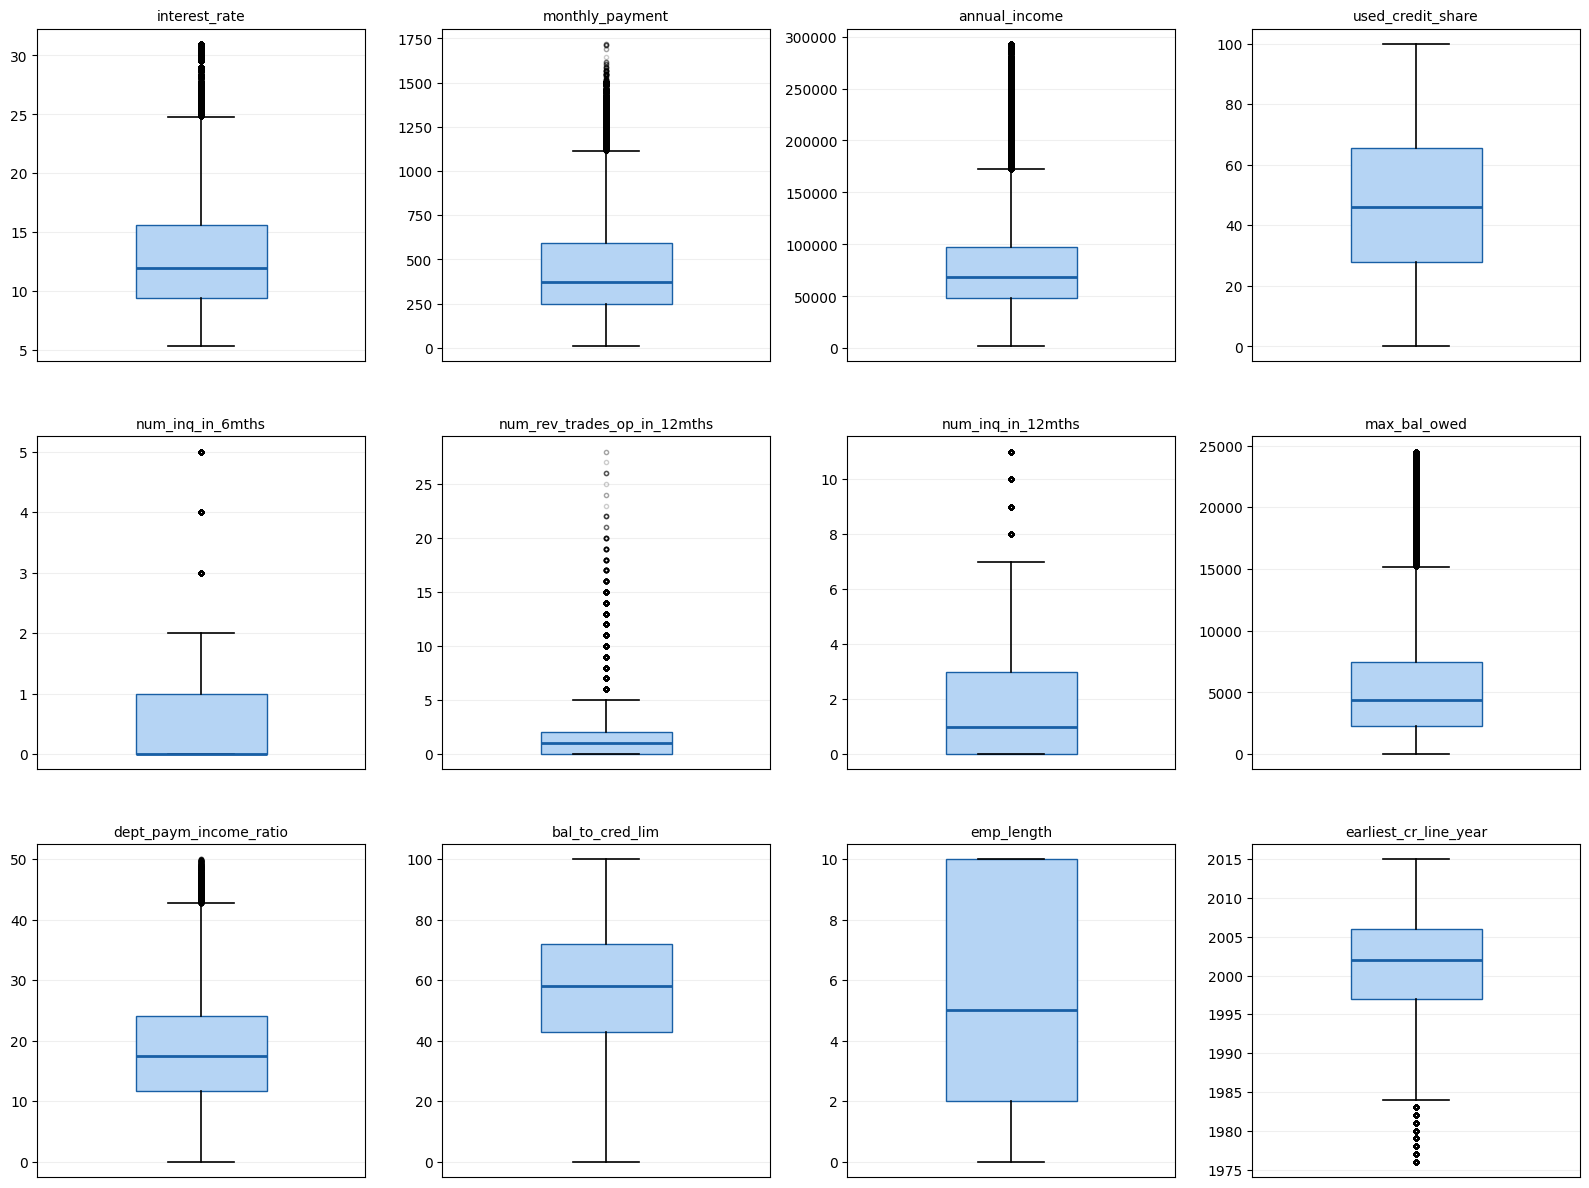

In [31]:
# We plot again the features.
plot_boxplots_list(df_PD_num_clean, num_features_PD, cols=4)

In [36]:
# We obtain again the outlier metrics.
outlier_summary_PD_num_clean = outlier_summary(df_PD_num_clean, num_features_PD)
outlier_summary_PD_num_clean

,Q1,Q3,IQR,lower_1.5,upper_1.5,lower_3.0,upper_3.0,moderate_n,moderate_pct,extreme_n,extreme_pct
feature,,,,,,,,,,,
interest_rate,9.43,15.59,6.16,0.19,24.83,-9.05,34.07,42717,3.40,0,0.00
monthly_payment,246.05,593.99,347.94,-275.86,1115.90,-797.77,1637.81,40077,3.19,11,0.00
annual_income,48000.00,97697.50,49697.50,-26546.25,172243.75,-101092.50,246790.00,62172,4.94,21377,1.70
used_credit_share,28.00,65.50,37.50,-28.25,121.75,-84.50,178.00,0,0.00,0,0.00
num_inq_in_6mths,0.00,1.00,1.00,-1.50,2.50,-3.00,4.00,38939,3.10,2262,0.18
num_rev_trades_op_in_12mths,0.00,2.00,2.00,-3.00,5.00,-6.00,8.00,25530,2.03,4045,0.32
num_inq_in_12mths,0.00,3.00,3.00,-4.50,7.50,-9.00,12.00,42801,3.40,0,0.00
max_bal_owed,2275.00,7445.00,5170.00,-5480.00,15200.00,-13235.00,22955.00,70735,5.62,17376,1.38
dept_paym_income_ratio,11.66,24.08,12.42,-6.97,42.71,-25.60,61.34,1522,0.12,0,0.00


### 3. Categorical features

We will have a look to the categoric features distribution to see if they need encoding.

C:\Users\juang\AppData\Local\Temp\ipykernel_2304\3013697998.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_PD = df_PD_num_clean.select_dtypes(include=["object"]).columns.tolist()


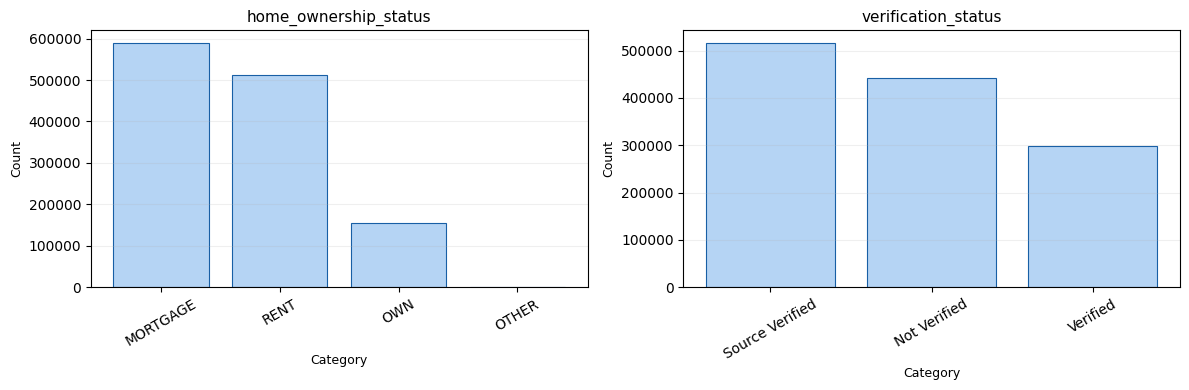

In [37]:
# We identify the categoric features for PD Model.
cat_features_PD = df_PD_num_clean.select_dtypes(include=["object"]).columns.tolist()

# We plot the categoric features using barplots.
plot_categoricals(df_PD_num_clean, cat_features_PD, figsize_per_plot=(6, 4))

As we can see, the only problem is the category OTHER in `home_ownership_status`, which will be included in RENT since it's the most similar category to OTHER.

In [38]:
# We include OTHER in RENT.
df_PD_num_clean["home_ownership_status"] = df_PD_num_clean["home_ownership_status"].replace("OTHER","RENT")

Finally, we check again the categoric features.

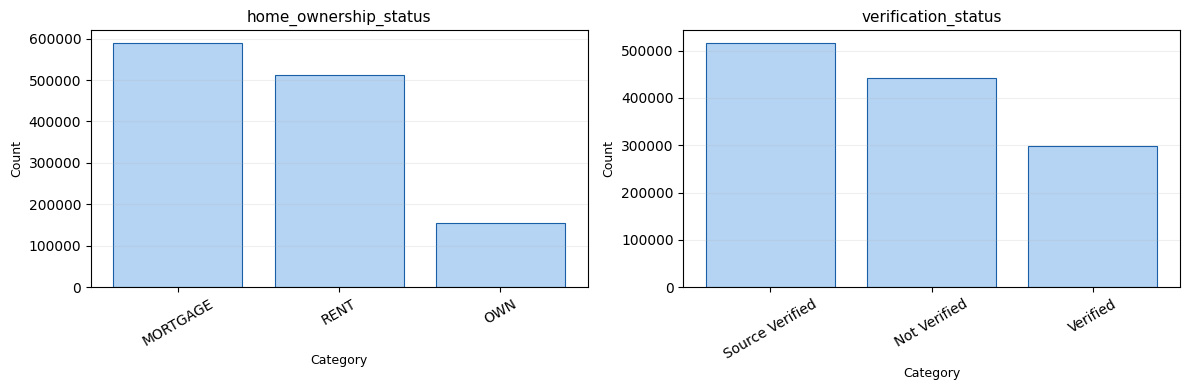

In [39]:
# We plot the categoric features using barplots.
plot_categoricals(df_PD_num_clean, cat_features_PD, figsize_per_plot=(6, 4))

### 4. Features correlation

Now, we check the features and target variable for PD Model correlation in case the done data treatment has introduced a correlation bias.

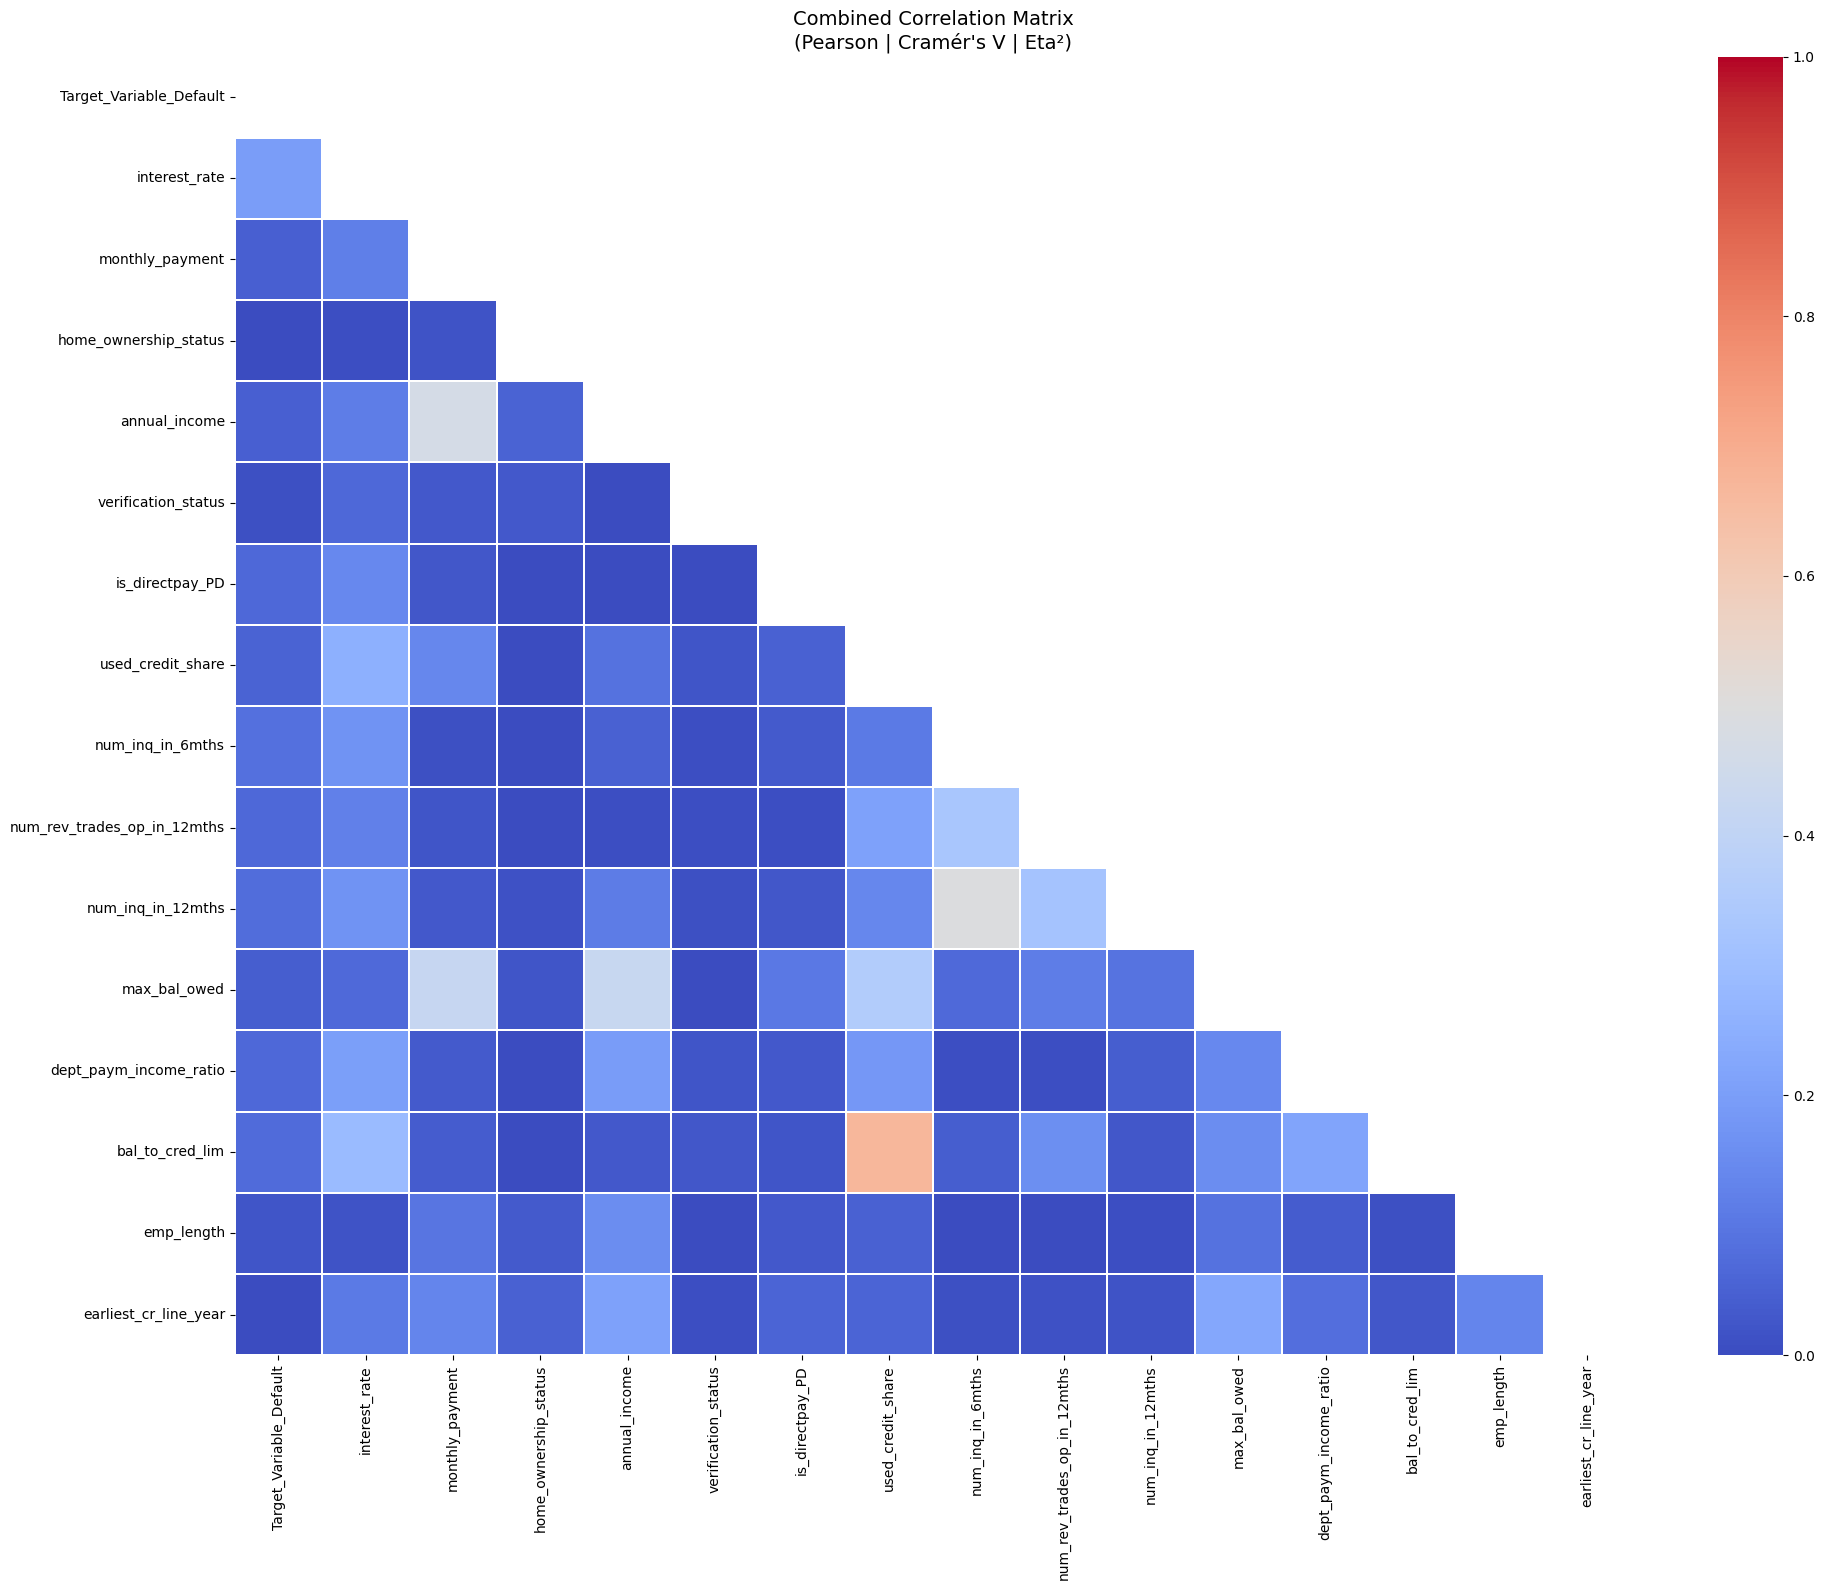

In [40]:
# We obtain and plot the correlation matrix for the PD Model.
corr_matrix_PD = compute_plot_correlation_matrix(df_PD_num_clean)

In [41]:
# We check the correlation among used_credit_share and bal_to_cred_lim.
df_PD_num_clean[["used_credit_share","bal_to_cred_lim"]].corr()

,used_credit_share,bal_to_cred_lim
used_credit_share,1.000000,0.669736
bal_to_cred_lim,0.669736,1.000000


There is no problem for any model with this level of correlation. So we finally create a new dataframe for the posterior training of PD Model.

In [42]:
# New dataframe full clean for PD Model.
df_PD_clean = df_PD_num_clean.copy()

### 5. Checkpoint: PD Model dataframe and features.

We save the dataframe previously to training PD Model.

In [43]:
# We save the dataframe.
with open("checkpoint_df_PD_training.pkl", "wb") as f:
    pickle.dump({"df_PD_clean": df_PD_clean}, f)

# We save the features.
with open("features_PD_num_for_training.pkl", "wb") as f:
    pickle.dump(num_features_PD, f)

with open("features_PD_cat_for_training.pkl", "wb") as f:
    pickle.dump(cat_features_PD, f)


In [4]:
# In case we want to load the dataframe.
with open("checkpoint_df_PD_training.pkl", "rb") as f:
    data = pickle.load(f)
df_PD_clean = data["df_PD_clean"]

# We load the features.
with open("features_PD_num_for_training.pkl", "rb") as f:
    num_features_PD = pickle.load(f)

with open("features_PD_cat_for_training.pkl", "rb") as f:
    cat_features_PD = pickle.load(f)

In [ ]:
df_PD_clean.head()

,Target_Variable_Default,interest_rate,monthly_payment,home_ownership_status,annual_income,verification_status,is_directpay_PD,used_credit_share,num_inq_in_6mths,num_rev_trades_op_in_12mths,num_inq_in_12mths,max_bal_owed,dept_paym_income_ratio,bal_to_cred_lim,emp_length,earliest_cr_line_year
0,0,13.56,84.92,RENT,55000.0,Not Verified,0,10.3,1,2.0,2,2137.0,18.24,28.0,10.0,2001
1,0,18.94,777.23,MORTGAGE,90000.0,Source Verified,0,24.2,0,4.0,2,998.0,26.52,57.0,10.0,1987
2,0,17.97,180.69,MORTGAGE,59280.0,Source Verified,0,19.1,0,0.0,0,0.0,10.51,35.0,6.0,2011
3,0,18.94,146.51,MORTGAGE,92000.0,Source Verified,0,78.1,0,0.0,3,3761.0,16.74,70.0,10.0,2006
4,0,16.14,731.78,MORTGAGE,57250.0,Not Verified,0,3.6,0,2.0,0,516.0,26.35,54.0,10.0,2000


### 6. Training: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM and CatBoostCheckpoint: PD Model dataframe and features.

Six classification models were trained for the PD model, covering the full spectrum from interpretable linear models to state-of-the-art gradient boosting ensembles. All models
were trained on the same preprocessed dataset (RobustScaler + One-Hot Encoding), tuned via RandomizedSearchCV on a stratified sample of 800,000 observations with 5-fold
cross-validation optimizing AUC-ROC, and evaluated on a held-out test set of 20% of the full training population.

---

#### Logistic Regression

**Description:**
Models the log-odds of default as a linear combination of the input features. Each coefficient represents the marginal contribution of a feature to the log-odds of default,
holding all other features constant. Coefficients are directly interpretable and can be presented to regulators, risk committees, and auditors without additional explanation.

**Advantages:**
- Full coefficient interpretability, every feature has a single, signed, stable weight
- Fastest to train and score in production
- Well-understood statistical properties — confidence intervals on coefficients, p-values, and goodness-of-fit tests are available
- Industry standard for regulatory credit risk models under Basel IRB; widely accepted by supervisors in the EU and US
- Highly stable, small changes in data produce small changes in coefficients

**Limitations:**
- Assumes a linear relationship between features and log-odds of default. Non-linear relationships and interaction effects are not captured unless explicitly engineered
- Performance ceiling is lower than ensemble methods, particularly on datasets with complex feature interactions
- Sensitive to feature scale and outliers if not preprocessed correctly
- Requires WoE encoding or manual binning to reach production-grade performance in credit risk applications

**Best hyperparameters found:**
`C = 0.0088`, `penalty = l1`, `solver = saga`, `class_weight = balanced`, `max_iter = 500`

The strong L1 regularization (very low C) indicates the model benefits from aggressive feature selection, carrying some coefficients to exactly zero. This is consistent with the presence of correlated features in the dataset.

---

#### Decision Tree

**Description:**
Partitions the feature space into rectangular regions via a sequence of binary splits, producing a tree structure where each leaf assigns a class prediction. The resulting model can be visualized and explained as a set of if-then rules.

**Advantages:**
- Fully interpretable, the decision path for any individual prediction can be traced and explained in plain language
- Captures non-linear relationships and interactions automatically
- No feature scaling required
- Useful as a baseline to quantify the benefit of ensemble methods

**Limitations:**
- High variance, small changes in training data can produce very different trees
- Prone to overfitting, particularly with deep trees
- Generally weaker predictive performance than ensembles
- Not suitable for production credit risk without ensemble wrapping

---

#### Random Forest

**Description:**
Ensemble of decision trees trained on bootstrap samples of the data, with a random subset of features considered at each split. Predictions are aggregated by majority vote. The randomization across trees reduces variance relative to a single tree.

**Advantages:**
- More stable and less prone to overfitting than a single decision tree
- Captures non-linear relationships and feature interactions
- Provides feature importance estimates
- Robust to outliers and missing values
- Parallelizable, trees are independent and can be trained simultaneously

**Limitations:**
- Loss of interpretability relative to a single tree or logistic regression, individual predictions cannot be explained by a simple decision path
- Slower to train and score than boosting methods on large datasets
- Memory intensive, stores all trees in memory
- Less competitive than gradient boosting on structured tabular data in most benchmarks

---

#### XGBoost

**Description:**
Gradient boosting framework that builds trees sequentially, where each tree corrects the residual errors of the previous ensemble. Uses second-order gradient information (Newton boosting) and includes L1 and L2 regularization terms directly in the objective function. Builds trees level-by-level.

**Advantages:**
- State-of-the-art performance on structured tabular data
- Built-in regularization reduces overfitting
- Handles missing values natively
- Supports custom objective functions and evaluation metrics
- Well-documented and widely used in both academia and industry
- `scale_pos_weight` parameter handles class imbalance natively

**Limitations:**
- Limited interpretability without SHAP — individual predictions require post-hoc explanation tools
- More hyperparameters to tune than simpler models
- Slower than LightGBM on large datasets due to level-wise tree construction
- Regulatory acceptance requires additional explainability documentation

---

#### LightGBM

**Description:**
Gradient boosting framework with two key innovations over XGBoost: leaf-wise tree growth (expands the leaf with the highest loss reduction at each step rather than all leaves at
the same level) and Gradient-based One-Side Sampling (GOSS), which focuses computation on the most informative observations. Significantly faster than XGBoost on large datasets.

**Advantages:**
- Fastest training among the boosting models, particularly on datasets above 500k rows
- Leaf-wise growth produces more accurate trees for the same number of leaves
- Lower memory footprint than XGBoost on large datasets
- Competitive or superior AUC to XGBoost in most benchmarks
- `scale_pos_weight` handles class imbalance natively

**Limitations:**
- Leaf-wise growth can overfit on small datasets if `num_leaves` and `min_child_samples` are not constrained
- Less mature documentation and community than XGBoost
- Same interpretability limitations as XGBoost

---

#### CatBoost

**Description:**
Gradient boosting framework developed by Yandex with two key innovations: native handling of categorical features via ordered target statistics (avoiding target leakage during encoding) and ordered boosting (computing gradients on a permuted subset of observations to reduce overfitting). Uses symmetric trees, where all nodes at the same depth apply the same split condition.

**Advantages:**
- Native categorical feature handling, no encoding required in production pipelines
- Ordered boosting reduces overfitting without requiring aggressive regularization
- Symmetric trees are faster to score in production than asymmetric trees
- Requires less hyperparameter tuning than XGBoost or LightGBM to reach competitive performance
- `auto_class_weights` handles class imbalance natively

**Limitations:**
- Slower to train than LightGBM
- Symmetric tree constraint can limit expressiveness on complex non-linear patterns
- Native categorical handling advantage is reduced when features are already encoded
- Writes temporary files to disk during training, which can cause permission issues in
  restricted environments (mitigated with `allow_writing_files=False`)

---

In [ ]:
# We split the dataset in train and test and preprocess the features with RobustScaler and One-Hot Encoding.
X = df_PD_clean[num_features_PD + cat_features_PD]
y = df_PD_clean['Target_Variable_Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_test, scaler = preprocess_features_LGD(
    X_train, X_test, cat_features_PD, num_features_PD
)

In [ ]:
# We train all the models described above and save the results.
results_PD_Model = train_all_models_PD(X_train, y_train, X_test, y_test, sample_size=800_000)


────────────────────────────────────────────────────────────
  Training: logistic_regression_PD
────────────────────────────────────────────────────────────
  Sampling 800,000 rows for hyperparameter search...
  Running RandomizedSearchCV (100 iterations, 5-fold CV)...


C:\Users\juang\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\juang\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Best params : {'C': np.float64(0.008787658410143284), 'class_weight': 'balanced', 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
  Best CV AUC : 0.7041
  Refitting on full training set (1,006,396 rows)...


C:\Users\juang\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\juang\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Test AUC: 0.7036 | Accuracy: 0.6601 | Precision: 0.1745 | Recall: 0.6274 | F1: 0.273
  Saved: models\logistic_regression_PD.pkl | models\logistic_regression_PD_metrics.json

────────────────────────────────────────────────────────────
  Training: decision_tree_PD
────────────────────────────────────────────────────────────
  Sampling 800,000 rows for hyperparameter search...
  Running RandomizedSearchCV (100 iterations, 5-fold CV)...
  Best params : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 150, 'min_samples_split': 356}
  Best CV AUC : 0.7191
  Refitting on full training set (1,006,396 rows)...
  Test AUC: 0.7246 | Accuracy: 0.598 | Precision: 0.1663 | Recall: 0.7352 | F1: 0.2712
  Saved: models\decision_tree_PD.pkl | models\decision_tree_PD_metrics.json

────────────────────────────────────────────────────────────
  Training: random_forest_PD
────────────────────────────────────────────────────────────
  Sampling 800,000 rows for hype

### 7. Results

| Model | AUC-ROC | PR-AUC | Accuracy | Precision | Recall | F1 | CV AUC |
|---|---|---|---|---|---|---|---|
| LightGBM | 0.7732 | 0.2727 | 0.6619 | 0.1962 | 0.7501 | 0.3110 | 0.7698 |
| XGBoost | 0.7729 | 0.2722 |0.6618 | 0.1960 | 0.7494 | 0.3108 | 0.7690 |
| CatBoost | 0.7712 | 0.2680 |0.6589 | 0.1952 | 0.7533 | 0.3100 | 0.7680 |
| Random Forest | 0.7412 | 0.2403 |0.6921 | 0.1947 | 0.6462 | 0.2992 | 0.7375 |
| Decision Tree | 0.7246 | 0.2167 |0.5980 | 0.1663 | 0.7352 | 0.2712 | 0.7191 |
| Logistic Regression | 0.7036 | 0.2132 |0.6601 | 0.1745 | 0.6274 | 0.2730 | 0.7041 |

---

### 8. Interpretation of Results

#### 8.1 Why AUC is the primary metric

All models were optimized on AUC-ROC rather than accuracy, precision, recall, or F1. This is the correct choice for three reasons specific to this problem.

First, the dataset is heavily imbalanced: the default rate is approximately 10%. In this setting, a model that classifies every loan as non-default achieves an accuracy above
90% and is completely useless. Accuracy is therefore misleading as a primary metric.

Second, AUC-ROC measures the model's ability to discriminate between defaults and non-defaults across all possible classification thresholds, not at a single arbitrary cutoff. It answers the question: given a random defaulter and a random non-defaulter, what is the probability that the model assigns a higher risk score to the defaulter? This is exactly the property that matters for ranking loans by risk and for computing Expected Loss, where `predict_proba` is used directly rather than a binary classification.

Third, AUC is the standard metric for PD model evaluation under Basel IRB guidelines and is the metric used in model validation and regulatory review in practice.

### 8.2 Why precision is low and why it is not a problem

All models show precision in the range of 0.17 to 0.20. This means that of every 10 loans classified as default, approximately 2 are actual defaults and 8 are not.

This is not a model failure, it is a mathematical consequence of the class imbalance. With a base default rate of approximately 10%, even a model with strong discriminative power will produce many false positives when the threshold is set aggressively. A random classifier with no predictive power would achieve a precision equal to the base rate (0.08-0.10). All models in this project achieve precision between 0.17 and 0.20, which represents a 2 to 2.5 times improvement over random classification.

Precision and recall at a fixed threshold are not the right lens for this model. The correct tool is the Precision-Recall curve, which shows the full trade-off between the
two metrics across all thresholds. In production, the optimal threshold is set based on the relative cost of a false positive (rejecting a good loan, losing margin) versus a
false negative (approving a bad loan, incurring a loss), which is a business decision that depends on the loan product's economics.

For the purpose of computing Expected Loss, the threshold is irrelevant, the model outputs `predict_proba`, a continuous probability score, which is multiplied directly
by LGD and EAD without any binarization.

### 8.3 The boosting gap

The AUC gap between logistic regression (0.704) and the three boosting models (0.771-0.773) is 6.9 points. In credit risk, this difference is economically significant: at portfolio scale, better discrimination means more accurate risk pricing, lower unexpected losses, and more efficient capital allocation.

This gap illustrates the fundamental trade-off in credit risk modeling between interpretability and performance. Logistic regression is the regulatory standard because its coefficients are directly interpretable and auditable. Gradient boosting models achieve materially better discrimination but require post-hoc explanation tools such as SHAP to make individual predictions auditable. The decision of which model to deploy in production depends on the regulatory environment, the risk appetite of the institution, and the availability of model governance infrastructure.

The near-identical performance of LightGBM (0.7732), XGBoost (0.7729), and CatBoost (0.7712) confirms that the result is robust, it reflects genuine signal in the data rather than an artifact of a specific algorithm.

### 8.4 Generalization: CV AUC vs Test AUC

For all models, the difference between CV AUC (computed on the 800k sample during hyperparameter search) and Test AUC (computed on the full held-out test set) is at most 0.003. This tight alignment indicates that the models generalize well and that hyperparameter tuning did not overfit to the sample. It also suggests that 800k observations are sufficient to find hyperparameters that transfer well to the full dataset.

---

### 9. Limitations of These Results

**Absence of temporal ordering.**
The train/test split is random rather than chronological. In a production credit risk model, the correct validation methodology is temporal: train on loans originated before a cutoff date and validate on loans originated after it. A random split allows the model to learn from loans originated in 2018 while predicting loans from 2015, which is impossible in production. This inflates all reported metrics relative to what would be observed in a true out-of-time validation. This limitation is inherent to the dataset structure and is documented here as a known constraint of the portfolio implementation.

**Uniform preprocessing across models.**
All models received the same RobustScaler and One-Hot Encoding preprocessing. In production, each model would receive preprocessing tailored to its assumptions: logistic regression would benefit from WoE encoding and manual binning; CatBoost would handle categorical features natively without encoding; XGBoost and LightGBM would not require scaling. The uniform preprocessing penalizes logistic regression (which benefits most from linearizing transformations) and provides less benefit to tree-based models (which are invariant to monotonic transformations).

**Hyperparameter search on a subsample.**
RandomizedSearchCV was run on a stratified sample of 800k observations rather than the full training set. Optimal hyperparameters on 800k may differ from those on 1M observations, particularly for regularization parameters that depend on dataset size. The final models were refitted on the full training set with the sample-derivedhyperparameters, which partially mitigates this limitation.

**No probability calibration.**
The `predict_proba` outputs of tree-based models are not calibrated, a score of 0.30 does not necessarily mean that 30% of loans with that score will default. For Basel IRB
compliance and for accurate Expected Loss computation, calibration via Platt scaling or isotonic regression would be required. This is a known limitation and a natural extension
of this work.

**Class imbalance handling via weighting only.**
Class imbalance was addressed through `class_weight = balanced` and `scale_pos_weight` parameters. Alternative approaches such as SMOTE oversampling, undersampling of the majority class, or threshold optimization were not explored. These could improve the precision-recall trade-off at the classification threshold without affecting AUC.

**No out-of-time validation.**
Related to the temporal split limitation: walk-forward or expanding window cross-validation was not implemented. In production, a model's performance is assessed on multiple out-of-time windows to verify stability across different economic periods. The single random split used here does not capture potential performance degradation during periods of economic stress.

---

### 10. Model Selection Recommendation

For the purpose of computing Expected Loss in this project, **LightGBM** is selected as the primary model based on its marginally superior AUC (0.7732) and the tightest alignment between CV AUC and Test AUC (0.0034 gap), indicating robust generalization.

For a production Basel IRB context, **logistic regression** would be the recommended model despite its lower AUC, due to its full coefficient interpretability, regulatory acceptance, and the availability of standard model validation procedures. The 6.9 point AUC gap would need to be weighed against the cost of the additional explainability infrastructure required to deploy a gradient boosting model in a regulated environment.

For this reason, **LightGBM** model will be used for PD calculation. Also we will have a look to its SHAP values.

PD computed for 1,257,995 loans
Mean PD: 0.4105
Median PD: 0.4210
Computing SHAP values...


C:\Users\juang\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


shap_values shape: (251599, 16)


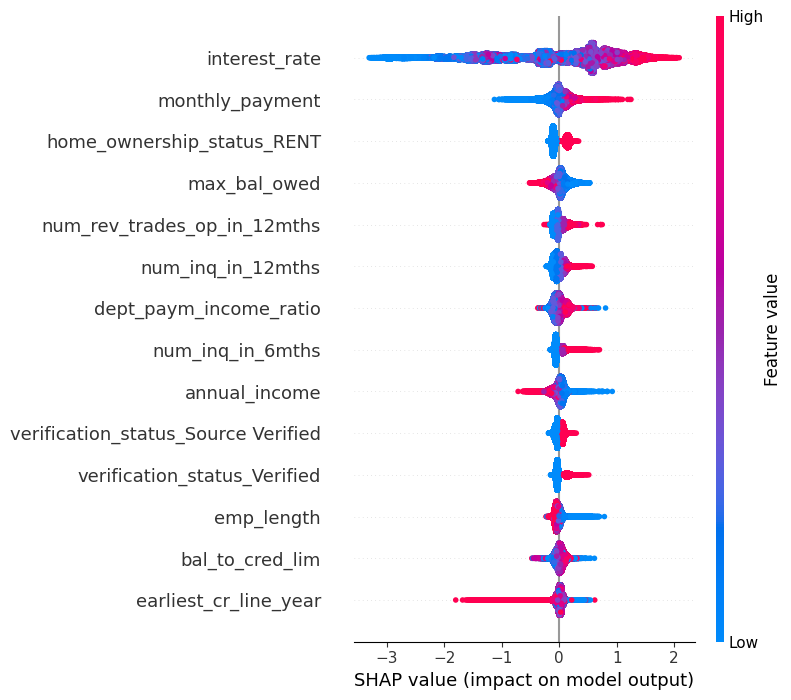

In [12]:
# Load best model
with open('models/lightgbm_PD.pkl', 'rb') as f:
    model_PD = pickle.load(f)

# Predict probabilities on full test set
X_full = pd.concat([X_train, X_test], axis=0).sort_index()
y_prob_PD = model_PD.predict_proba(X_full)[:, 1]

print(f"PD computed for {len(y_prob_PD):,} loans")
print(f"Mean PD: {y_prob_PD.mean():.4f}")
print(f"Median PD: {np.median(y_prob_PD):.4f}")

# SHAP values — TreeExplainer is exact for tree-based models
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(model_PD)
shap_values = explainer.shap_values(X_test)

# For LightGBM, shap_values may be a list [class_0, class_1] — take class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"shap_values shape: {shap_values.shape}")

# SHAP summary plot — comparable to the exploratory model
shap.summary_plot(shap_values, X_test, max_display=X.shape[1])

### 11. Isotonic Regression

The LightGBM model trained with scale_pos_weight and class_weight='balanced' produces well-ordered risk scores (AUC-ROC 0.7732) but systematically overestimates the absolute probability of default. The uncalibrated mean PD over the full portfolio is 0.41, compared to an observed default rate of 0.10. This three-fold inflation makes the raw predict_proba output unsuitable for Expected Loss computation, where EL = PD * LGD * EAD requires PD to be an accurate estimate of the true default probability, not just a relative risk score.

The class imbalance compensation parameters shift the decision boundary aggressively toward the positive class to maximize recall. This improves discrimination but decouples the probability outputs from the true underlying default rate. Calibration corrects this decoupling without modifying the underlying model or its discriminative power.

#### 11.1 Method: Isotonic Regression
Two standard calibration methods exist: Platt Scaling (sigmoid) and Isotonic Regression. Platt Scaling fits a logistic function on top of the raw probabilities, assuming a monotonic sigmoidal relationship between uncalibrated and calibrated scores. Isotonic Regression fits a non-parametric monotonic step function, making no assumptions about the functional form of the mapping.

Isotonic Regression is the correct choice here for two reasons. First, the distortion introduced by scale_pos_weight is not necessarily sigmoidal, it compresses and shifts the probability distribution in a complex way that a logistic function may not capture accurately. Second, with a test set of approximately 250,000 observations, the sample size is more than sufficient to fit a non-parametric calibrator without overfitting, which is the main risk of isotonic regression on small samples.

Mean PD original  : 0.4105
Mean PD calibrated: 0.1017
Tasa de default real: 0.1017


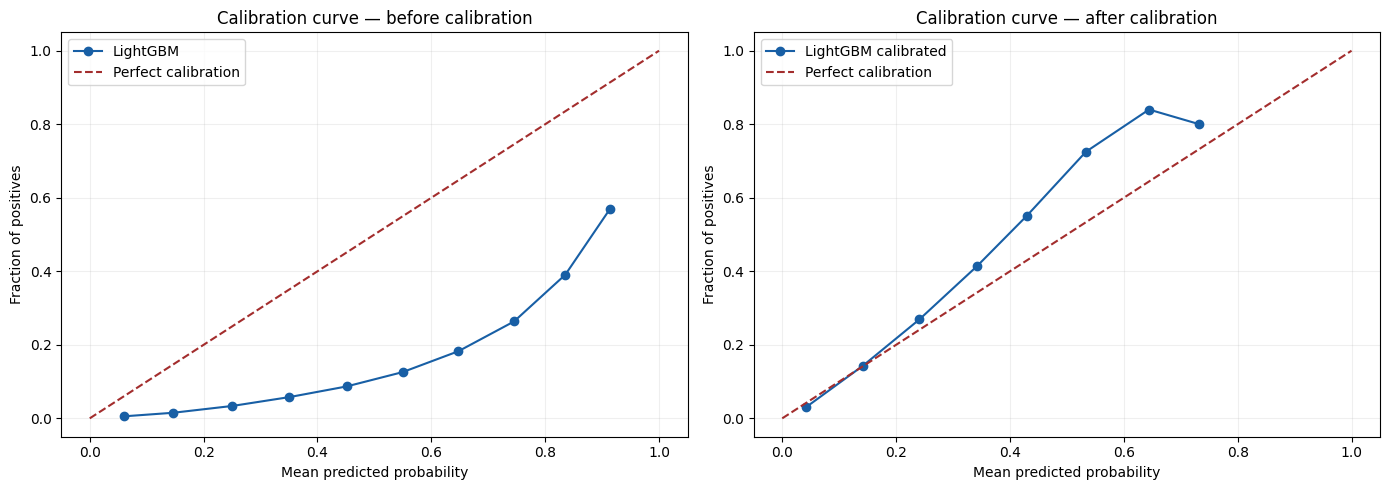

In [18]:
# Calibrate on test set — documented limitation for portfolio
calibrated_model_PD = CalibratedClassifierCV(model_PD, method='isotonic')
calibrated_model_PD.estimator = model_PD
calibrated_model_PD.fit(X_test, y_test)

# Calibrated probabilities on full dataset
y_prob_PD_calibrated = calibrated_model_PD.predict_proba(X_full)[:, 1]

print(f"Mean PD original  : {y_prob_PD.mean():.4f}")
print(f"Mean PD calibrated: {y_prob_PD_calibrated.mean():.4f}")
print(f"Tasa de default real: {y_test.mean():.4f}")

# Calibrated probabilities on test set for calibration curve
y_prob_test = model_PD.predict_proba(X_test)[:, 1]
y_prob_test_calibrated = calibrated_model_PD.predict_proba(X_test)[:, 1]

# Calibration curve — before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
axes[0].plot(prob_pred, prob_true, marker='o', color='#185FA5', label='LightGBM')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='#A32D2D', label='Perfect calibration')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration curve — before calibration')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# After calibration
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_test_calibrated, n_bins=10)
axes[1].plot(prob_pred_cal, prob_true_cal, marker='o', color='#185FA5', label='LightGBM calibrated')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='#A32D2D', label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration curve — after calibration')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Post-calibration, the mean PD over the full portfolio converges to 0.1017, exactly matching the observed default rate. The calibration curve confirms the alignment between predicted probabilities and observed default rates across all probability bins.

#### 11.2 Known Limitation: Calibration on the Test Set
The correct methodology for probability calibration requires a three-way split: a training set to fit the model, a calibration set to fit the calibrator, and a held-out test set to evaluate the calibrated model. Using the test set for both calibration and evaluation introduces a form of data leakage, the calibrator has seen the test labels, which means the reported calibration quality is optimistic.

In this project the calibration is fitted on the test set due to the absence of a dedicated calibration split. This is a known limitation accepted as a portfolio simplification. In production, the correct approach would be to reserve a calibration set at the outset, or to use cross-validated calibration via CalibratedClassifierCV with cv=5, which avoids the leakage by fitting the calibrator on out-of-fold predictions.

Despite this limitation, the calibration result is robust: the mean PD of 0.1017 matching the observed default rate of 0.1017 is a necessary but not sufficient condition for good calibration. The calibration curve across all probability bins confirms that the alignment holds not only at the mean but across the full distribution of predicted scores.

### 12. Final PD

The final PD is included in `df_master_features`dataframe.

In [21]:
# We save the final PD in df_master_features dataframe.
df_master_features["PD"] = y_prob_PD_calibrated

In [22]:
df_master_features.head()

,Target_Variable_Default,Target_Variable_Loss,EAD,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,...,disbursement_method_LGD,mths_since_recent_bankcard_delinq_PD,mths_since_recent_revol_delinq_PD,mths_since_last_delinq_PD,mths_since_last_installment_acc_op_PD,mths_since_recent_bankcard_delinq_LGD,mths_since_recent_revol_delinq_LGD,mths_since_last_delinq_LGD,mths_since_last_installment_acc_op_LGD,PD
0,0,85.480000,2500,13.56,84.92,C1,Hospitality,10.0,RENT,55000.0,...,Cash,999.0,999.0,999.0,2.0,999.0,999.0,999.0,2.0,0.012264
1,0,3.326667,30000,18.94,777.23,D2,Government,10.0,MORTGAGE,90000.0,...,Cash,999.0,999.0,71.0,3.0,999.0,999.0,71.0,3.0,0.032291
2,0,0.000000,5000,17.97,180.69,D1,Admin,6.0,MORTGAGE,59280.0,...,Cash,999.0,999.0,999.0,14.0,999.0,999.0,999.0,14.0,0.027297
3,0,94.025000,4000,18.94,146.51,D2,Management,10.0,MORTGAGE,92000.0,...,Cash,999.0,999.0,999.0,5.0,999.0,999.0,999.0,5.0,0.013806
4,0,1.720000,30000,16.14,731.78,C4,Construction,10.0,MORTGAGE,57250.0,...,Cash,999.0,999.0,999.0,4.0,999.0,999.0,999.0,4.0,0.024621


## Checkpoint: Save PD

In [27]:
# We save the final PD in df_master_features dataframe.
with open("checkpoint_DataFrame_after_PD_calculation.pkl", "wb") as f:
    pickle.dump({"df_master_features": df_master_features}, f)

In [73]:
# In case we want to load the dataframe.
with open("checkpoint_DataFrame_after_PD_calculation.pkl", "rb") as f:
    data = pickle.load(f)
df_master_features_PD = data["df_master_features"]

## LGD Model

At first we will create a new dataframe to train the LGD Model without introducing a bias in `df_master_features`, since we will infer both model over it.

In [6]:
# Create a new dataframe for PD model.
df_LGD = df_master_features.loc[df_master_features["Target_Variable_Default"]==1, ["Target_Variable_Loss"] + features_LGD ].copy()

### 1. Initial audit

We will start showing the principal statistical descriptors of the features for por de PD Model.

In [8]:
# We show the principal descriptors of features for PD Model.
audit_LGD = dataset_audit(df_LGD[features_LGD])
audit_LGD

,dtype,n_unique,null_count,null_pct,min,max,mean,std,skew
feature,,,,,,,,,
total_credit_revolving_bal,int64,37836,0,0.0,0.00,805550.00,14949.9766,19227.5218,8.5656
monthly_payment,float64,29670,0,0.0,30.12,1717.63,481.4179,284.2219,0.9686
num_open_credit_lines,int64,65,0,0.0,0.00,74.00,11.9596,5.8891,1.3305
loan_term_months,int64,2,0,0.0,36.00,60.00,44.0469,11.3302,0.6978
num_rev_trades_op_in_24mths,float64,43,0,0.0,0.00,49.00,3.4302,2.9274,1.8534
used_credit_share,float64,1108,0,0.0,0.00,162.00,50.9015,24.2517,-0.0166
interest_rate,float64,240,0,0.0,5.31,30.99,15.8945,5.4938,0.6885
annual_income,float64,11135,0,0.0,2400.00,9573072.00,74557.9130,71256.7096,46.0995
emp_length,float64,12,0,0.0,0.00,10.00,5.3201,3.8587,0.0348


In [10]:
df_LGD.shape

(127977, 11)

In order to have a better knowledge about the features to analyze outliers, a brief description of each feature selected for the Loss Given Default (LGD) model, grouped by economic category is included:

---

#### Loan Characteristics

**`interest_rate`**
Annual interest rate assigned to the loan at origination, expressed as a percentage. The interest rate is determined by the internal credit grade assigned to the borrower, which incorporates FICO score, debt-to-income ratio, and loan term among other factors. Higher rates indicate higher perceived risk at origination. In the context of LGD, borrowers assigned higher rates carry higher-risk profiles and tend to have accumulated more interest on outstanding balances at the time of default, increasing the total amount lost.

**`monthly_payment`**
Fixed monthly installment amount the borrower is contractually obligated to pay. Reflects the combined effect of loan amount, interest rate, and term. In the context of LGD, higher payments imply larger outstanding principal, which directly determines the exposure at the time of default and therefore the magnitude of the loss.

**`loan_term_months`**
Contractual duration of the loan in months, taking values of 36 or 60. Longer-term loans have more time to accumulate unpaid principal and interest before default. At any given point in the loan lifecycle, a 60-month loan will have a higher outstanding balance relative to the original funded amount than a 36-month loan, which translates into higher loss severity upon default.

---

#### Borrower Financial Profile

**`annual_income`**
Self-reported gross annual income of the borrower at the time of application, in USD. In the context of LGD, income determines the borrower's repayment capacity and the relative weight of the outstanding debt. For a given outstanding balance, lower income implies lower recovery probability and higher effective loss, as the borrower has fewer resources to partially repay the debt during the default resolution process.

**`dept_paym_income_ratio`**
Debt-to-income ratio (DTI): total monthly debt payments divided by gross monthly income, expressed as a percentage. One of the core metrics in retail credit risk assessment under Basel II/III. In the context of LGD, a high DTI indicates that the borrower was already structurally overleveraged before default, leaving limited residual capacity to service or partially recover the outstanding debt. Added to the model via expert judgment after confirming low correlation with `annual_income` and `monthly_payment`, which could otherwise have absorbed its signal.

**`emp_length`**
Number of years the borrower has been employed at their current employer, ranging from 0 to 10 (where 10 represents 10 or more years). Proxy for income stability and employment security. Within the defaulted population, borrowers with longer employment history may enter default at earlier stages of financial deterioration, with lower accumulated balances and potentially higher recovery rates. NaN values are treated as unemployment rather than missing at random, and are imputed with 0.

---

#### Credit Utilization and Exposure

**`used_credit_share`**
Credit utilization rate: revolving balance relative to all available credit, as reported by Lending Club. High utilization at the time of default indicates the borrower was already drawing on most available credit, leaving little buffer and increasing the net loss upon default.

**`total_credit_revolving_bal`**
Total outstanding balance across all revolving accounts at the time of the loan application, in USD. Direct proxy for the amount exposed and potentially unrecoverable upon default. The strongest predictor of loss magnitude in the LGD model, as it captures the absolute level of revolving indebtedness rather than its relative level.

**`num_open_credit_lines`**
Number of currently open credit lines across all account types. A higher number of open lines implies greater total credit exposure, which correlates with the severity of the financial distress that led to default and with the total balance at risk at the time of default.

---

#### Credit History and Activity

**`num_rev_trades_op_in_24mths`**
Number of revolving trade lines opened in the last 24 months. Captures whether the borrower was actively expanding revolving credit exposure in the period leading up to default, which relates to the trajectory of balance accumulation. A broader window than the 12-month version used in the PD model, reflecting that for LGD the relevant signal is the medium-term build-up of revolving debt rather than the most acute recent activity.

### 2. Numeric features

We will have a look to the numeric features so see their distributions, which will helps us a lot identifying the outliers.

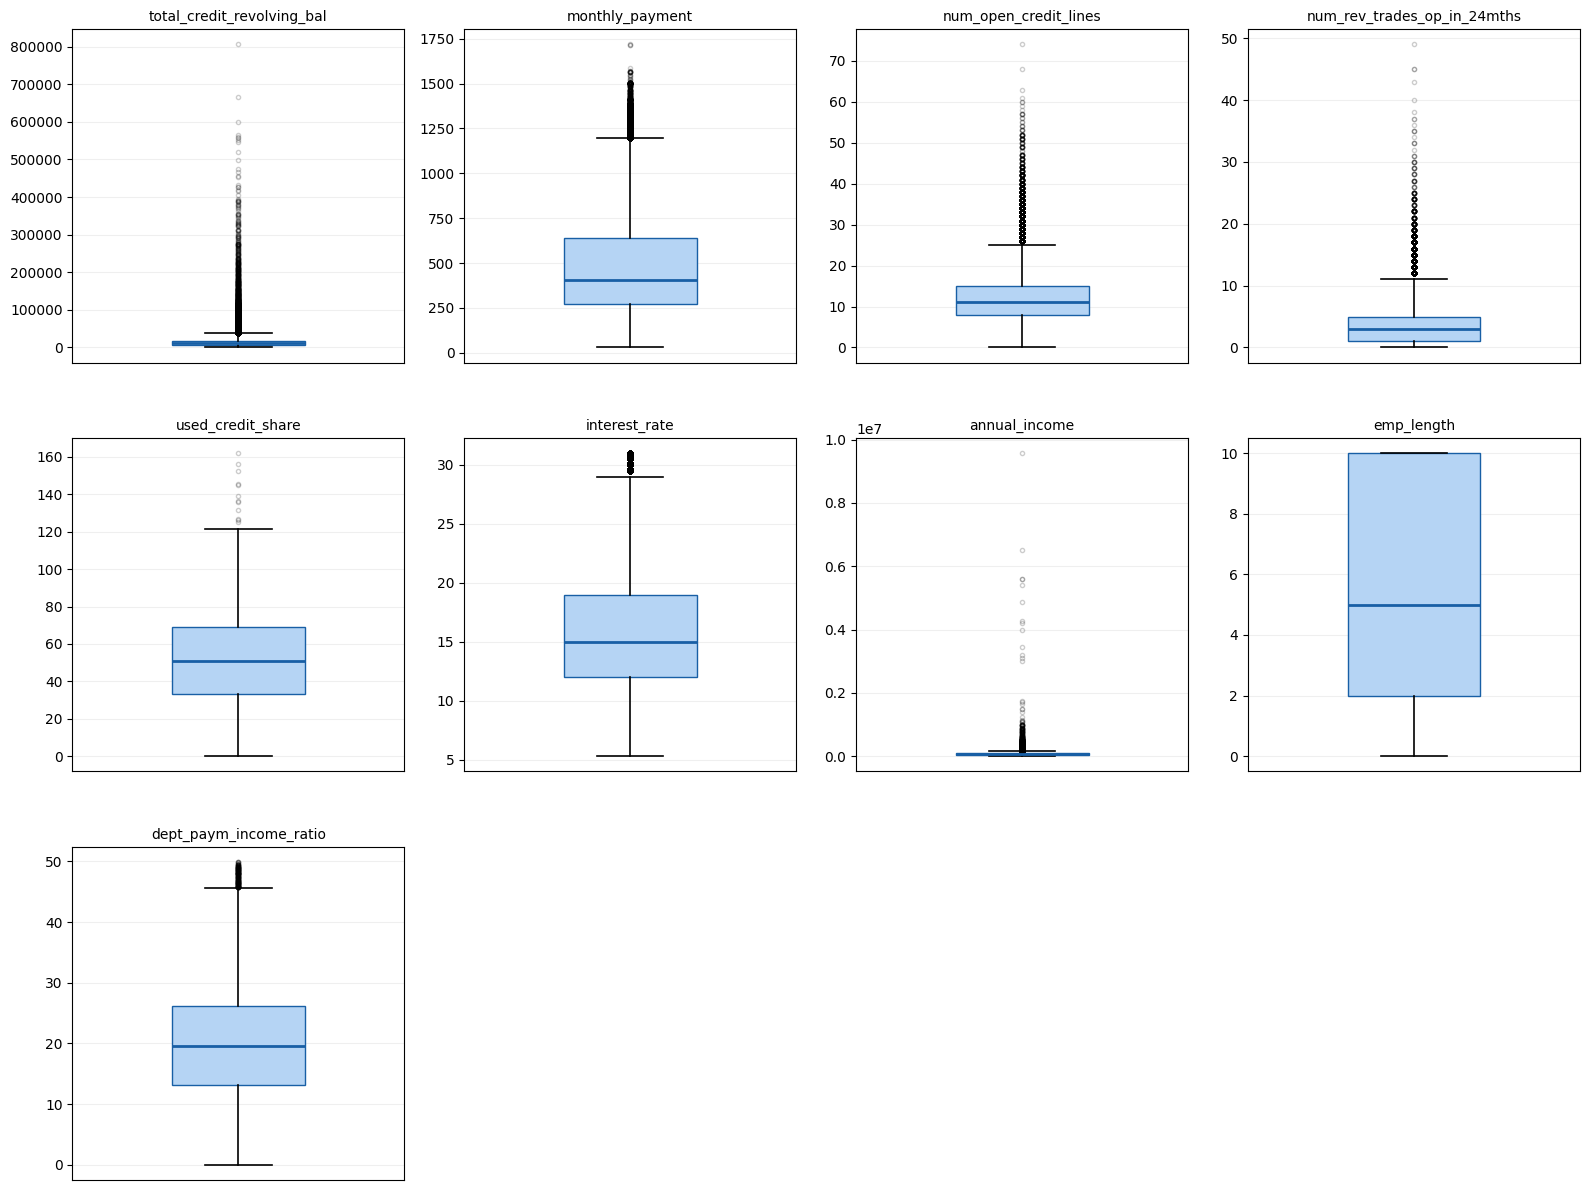

In [ ]:
# We identify the numeric features in df_LGD.
num_features_LGD = df_LGD[features_LGD].select_dtypes(include=[np.number]).columns.tolist()

# The feature loan_term_months have been identified as numeric but we know it's categorical since it only has values of 36 and 60 months. So, we remove it from num_features_LGD.
num_features_LGD.remove("loan_term_months")

# We plot the numeric features using boxplots.
plot_boxplots_list(df_LGD, num_features_LGD, cols=4)


#### 2.1 Numeric features: outliers & NaNs

The standard method for outlier detection in credit risk feature engineering is the interquartile range (IQR) method, originally proposed by Tukey (1977). For each feature,
two flagging thresholds are computed:

```
Moderate outlier:  value < Q1 - 1.5 * IQR  or  value > Q3 + 1.5 * IQR
Extreme outlier:   value < Q1 - 3.0 * IQR  or  value > Q3 + 3.0 * IQR
```

The 1.5 multiplier is the classical Tukey fence and flags values that deviate meaningfully from the bulk of the distribution. The 3.0 multiplier flags values that are genuinely
anomalous and difficult to explain under any reasonable data-generating process.

Both thresholds are computed for every feature, along with the count and percentage of observations falling in each zone. The percentage is the operative number for the
treatment decision.

---

The combination of the IQR-based flags and economic domain knowledge produces the following decision framework:

**Cap to p99 value is economically implausible:**
When `extreme_pct < 0.1%` and the flagged values are inconsistent with the economic context of the dataset (for example, `annual_income = 110,000,000` in a retail personal
loan portfolio where the 99th percentile is approximately 250,000), the values are treated as data entry errors or reporting artifacts. They are capped to the 99th percentile of the training populationhe. The threshold is conservative: only values that are both statistically extreme and economically implausible are capped.

**Do not treat value is plausible and extreme_pct is low:**
When `extreme_pct < 0.1%` and the flagged values are consistent with the economic context, the values are retained as genuine observations at the tail of the distribution.Removing or capping real data points introduces bias without improving model quality.

**Do not cap: consider log transformation:**
When `moderate_pct > 5%`, the feature has a heavy right tail that is not driven by a small number of anomalous values but by the natural shape of the distribution. Capping in this scenario would remove economically meaningful signal. The appropriate treatment is a log transformation, which compresses the tail and produces a more symmetric distribution
without discarding information.

**Apply domain judgment:**
When `moderate_pct` falls between 0.1% and 5%, the decision is not mechanical. The flagged values are reviewed against the economic interpretation of the feature and the
context of the loan portfolio. A value that is statistically moderate-extreme may be entirely plausible for a specific loan segment, or it may reflect a systematic reporting
issue. This zone is where domain knowledge overrides purely statistical criteria.

---

When capping is applied, the method used is Winsorization: values above the upper threshold are replaced by the threshold value, not removed. This preserves the number of observations and avoids introducing gaps in the training data. The capping threshold is always computed on the training population and stored in the feature pipeline, so that the same threshold is applied consistently at inference time regardless of the distribution of the input data.

Capping to the 99th percentile is the default upper bound. For features where the 99th percentile is itself influenced by a cluster of anomalous values, the threshold is
adjusted to the 97th or 95th percentile with explicit justification.

So, we will obtain these metrics for LGD Model features.

In [15]:
# We obtain outlier metrics for PD Model features.
outlier_summary_LGD = outlier_summary(df_LGD, num_features_LGD)
outlier_summary_LGD

,Q1,Q3,IQR,lower_1.5,upper_1.5,lower_3.0,upper_3.0,moderate_n,moderate_pct,extreme_n,extreme_pct
feature,,,,,,,,,,,
total_credit_revolving_bal,5514.00,18346.00,12832.00,-13734.00,37594.00,-32982.00,56842.00,7613,5.95,2758,2.16
monthly_payment,271.84,640.98,369.14,-281.87,1194.69,-835.58,1748.40,3208,2.51,0,0.00
num_open_credit_lines,8.00,15.00,7.00,-2.50,25.50,-13.00,36.00,3877,3.03,427,0.33
num_rev_trades_op_in_24mths,1.00,5.00,4.00,-5.00,11.00,-11.00,17.00,2408,1.88,317,0.25
used_credit_share,33.00,69.10,36.10,-21.15,123.25,-75.30,177.40,12,0.01,0,0.00
interest_rate,11.99,18.99,7.00,1.49,29.49,-9.01,39.99,3153,2.46,0,0.00
annual_income,45000.00,90000.00,45000.00,-22500.00,157500.00,-90000.00,225000.00,5656,4.42,1679,1.31
emp_length,2.00,10.00,8.00,-10.00,22.00,-22.00,34.00,0,0.00,0,0.00
dept_paym_income_ratio,13.20,26.20,13.00,-6.30,45.70,-25.80,65.20,216,0.17,0,0.00


For each feature in the LGD model, the treatment decision is documented below along with its quantitative and economic justification. Decisions are based on the combined output
of the dataset audit (dtype, null count, skewness) and the IQR-based outlier summary. The general decision framework is described in the outlier treatment methodology document.

Note that the LGD model is trained exclusively on the defaulted loan population (~128k observations). All treatment parameters are computed on this subset and must be applied
consistently at inference time via FeaturePipeline_LGD.

---

##### Features Requiring No Treatment

**`monthly_payment`**
No NaNs. Skewness of 0.97. Extreme outlier percentage of 0.00%. No treatment applied.

**`interest_rate`**
No NaNs. Skewness of 0.69, well below the log-transform threshold of 2. Extreme outlier percentage of 0.00%. No treatment applied.

**`emp_length`**
No NaNs. Range 0 to 10 by construction. Outlier percentages of 0.00% at both thresholds. No treatment applied. NaN values were already treated at the feature engineering stage as unemployment (imputed to 0) rather than missing at random.

**`dept_paym_income_ratio`**
No NaNs. Skewness of 0.08, essentially symmetric. Extreme outlier percentage of 0.00%. The minimum value is 0 within the defaulted population — unlike the full portfolio, no
negative values are present in this subset. No treatment applied.

**`num_rev_trades_op_in_24mths`**
No NaNs. Skewness of 1.85, below the log-transform threshold of 2. Extreme outlier percentage of 0.25% with a maximum of 49. Inspection of the value distribution above the 1.5 IQR upper fence confirms a gradual, monotonically decreasing frequency pattern with no discontinuities or isolated spikes. All values are economically plausible for revolving account activity over a 24-month window. No treatment applied.

**`loan_term_months`**
Binary categorical variable taking values 36 and 60. No NaNs, no outliers possible by construction. Encoding only, treated as a categorical feature at the encoding stage.

---

##### Features Requiring Capping

**`annual_income`**
No NaNs. Skewness of 46.10 and extreme outlier percentage of 1.31%, driven by a maximum value of 9,573,072 USD. A gross annual income above 9 million is economically implausible
for a retail personal loan borrower, even within the defaulted subset. Capping applied at the 99th percentile of the defaulted training population. Post-capping skewness is evaluated to determine whether a log transformation is also warranted, applying log1p if skewness exceeds 2 after capping.

**`used_credit_share`**
No NaNs. Maximum observed value of 162, which exceeds the theoretical upper bound of 100 for a credit utilization rate expressed as a percentage. Values above 100 are economically impossible under the standard definition of the metric and are treated as data quality errors. Capped at 100, consistent with the treatment applied in the PD model.

**`total_credit_revolving_bal`**
No NaNs. Initial audit identified a skewness of 8.57 in the original distribution, which motivated exploring a log1p transformation after capping at the 99th percentile. Post-capping skewness remained at 2.35, above the threshold of 2, which would normally trigger log1p.
However, applying log1p to the full capped variable produced a skewness of -2.81, inverting the asymmetry rather than reducing it. Restricting log1p to non-zero values only reduced the skewness of the positive distribution from 8.57 to -1.29, still negative and not a meaningful improvement in terms of distribution symmetry.
The root cause is the same pathology observed with max_bal_owed in the PD model: the distribution of positive values is heavily concentrated in a narrow range post-capping, and log1p compresses that range while leaving the zero mass at 0, creating an artificial left tail. With 711 zero values (0.55% of the defaulted population) the zero mass is small but sufficient to produce this effect given the concentration of the positive distribution.
The log1p transformation is therefore discarded. The final treatment is capping at the 99th percentile only, with no further transformation. A post-capping skewness of 2.35 is acceptable for tree-based models, which are invariant to monotonic transformations, and for linear models the RobustScaler applied at training time normalizes the scale without requiring a prior log transformation. This decision is consistent with the treatment applied to max_bal_owed in the PD model, where the same pathology was identified and the same conclusion was reached.

**`num_open_credit_lines`**
No NaNs. Skewness of 1.33 and extreme outlier percentage of 0.33% with a maximum of 74. Inspection of the value distribution above the 1.5 IQR upper fence reveals a gradual and decreasing pattern up to approximately 63, followed by isolated observations at 68 and 74 (one observation each) with no values between 63 and 68. This discontinuity in the upper tail is inconsistent with a natural distribution and suggests data quality issues for the highest values. Capping applied at the 99th percentile of the defaulted
training population.

---

##### Summary Table

| Feature | NaNs | Treatment |
|---|---|---|
| `total_credit_revolving_bal` | 0 | Cap p99, log1p if skew > 2 post-capping |
| `monthly_payment` | 0 | None |
| `num_open_credit_lines` | 0 | Cap at p99 |
| `loan_term_months` | 0 | Encoding only (binary categorical) |
| `num_rev_trades_op_in_24mths` | 0 | None |
| `used_credit_share` | 0 | Cap at 100 (economic ceiling) |
| `interest_rate` | 0 | None |
| `annual_income` | 0 | Cap p99, log1p if skew > 2 post-capping |
| `emp_length` | 0 | None (NaNs treated at feature engineering stage) |
| `dept_paym_income_ratio` | 0 | None |


In [42]:
# We apply this treatments to the features in df_PD.
df_LGD_num_clean = clean_features_LGD(df_LGD)

annual_income skew post-capping: 1.7121
  skew acceptable, log1p not applied to annual_income


In [43]:
# We audit again the datagrame.
audit_LGD_num_clean = dataset_audit(df_LGD_num_clean[num_features_LGD])
audit_LGD_num_clean

,dtype,n_unique,null_count,null_pct,min,max,mean,std,skew
feature,,,,,,,,,
total_credit_revolving_bal,float64,36565,0,0.0,0.00,82205.08,14339.2619,13723.7190,2.3489
monthly_payment,float64,29670,0,0.0,30.12,1717.63,481.4179,284.2219,0.9686
num_open_credit_lines,int64,32,0,0.0,0.00,31.00,11.9092,5.6751,0.9912
num_rev_trades_op_in_24mths,float64,43,0,0.0,0.00,49.00,3.4302,2.9274,1.8534
used_credit_share,float64,1001,0,0.0,0.00,100.00,50.8878,24.2190,-0.0251
interest_rate,float64,240,0,0.0,5.31,30.99,15.8945,5.4938,0.6885
annual_income,float64,10856,0,0.0,2400.00,250000.00,73004.0182,41159.7412,1.7121
emp_length,float64,12,0,0.0,0.00,10.00,5.3201,3.8587,0.0348
dept_paym_income_ratio,float64,4488,0,0.0,0.00,49.93,19.7082,8.7800,0.0847


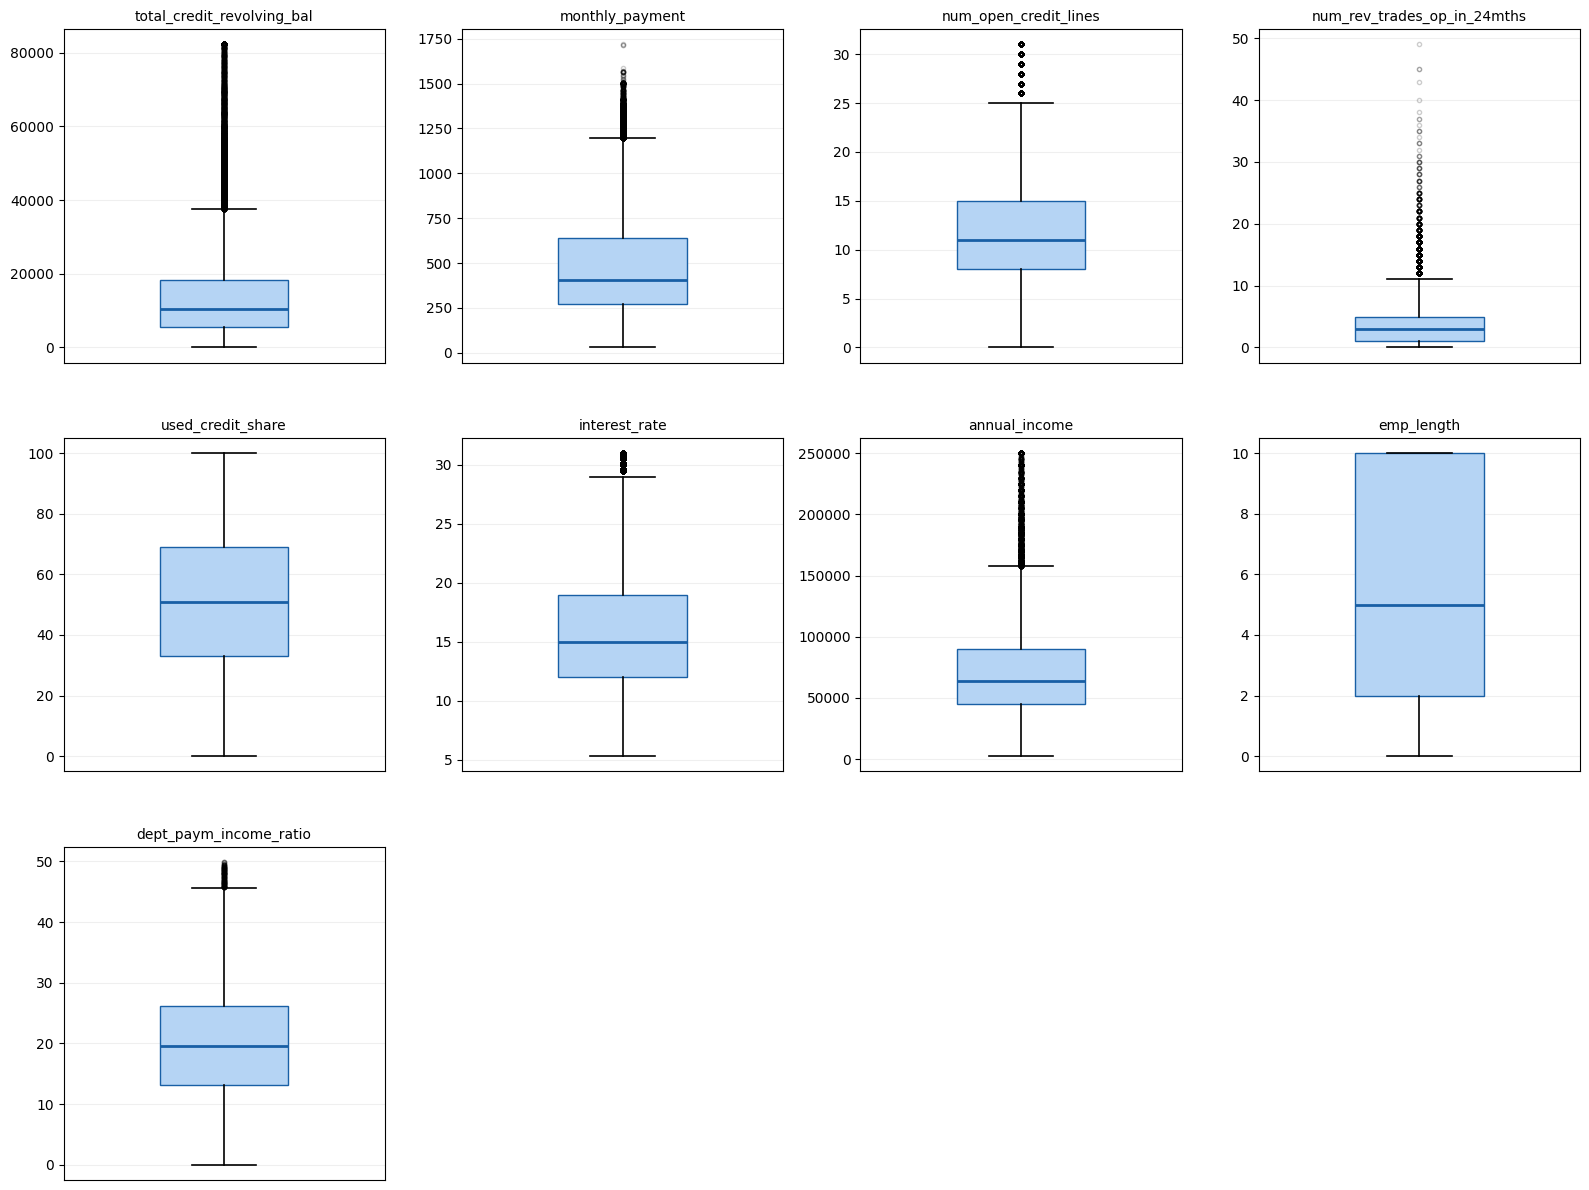

In [44]:
# We plot again the features.
plot_boxplots_list(df_LGD_num_clean, num_features_LGD, cols=4)

In [46]:
# We obtain again the outlier metrics.
outlier_summary_LGD_num_clean = outlier_summary(df_LGD_num_clean, num_features_LGD)
outlier_summary_LGD_num_clean

,Q1,Q3,IQR,lower_1.5,upper_1.5,lower_3.0,upper_3.0,moderate_n,moderate_pct,extreme_n,extreme_pct
feature,,,,,,,,,,,
total_credit_revolving_bal,5514.00,18346.00,12832.00,-13734.00,37594.00,-32982.00,56842.00,7613,5.95,2758,2.16
monthly_payment,271.84,640.98,369.14,-281.87,1194.69,-835.58,1748.40,3208,2.51,0,0.00
num_open_credit_lines,8.00,15.00,7.00,-2.50,25.50,-13.00,36.00,3877,3.03,0,0.00
num_rev_trades_op_in_24mths,1.00,5.00,4.00,-5.00,11.00,-11.00,17.00,2408,1.88,317,0.25
used_credit_share,33.00,69.10,36.10,-21.15,123.25,-75.30,177.40,0,0.00,0,0.00
interest_rate,11.99,18.99,7.00,1.49,29.49,-9.01,39.99,3153,2.46,0,0.00
annual_income,45000.00,90000.00,45000.00,-22500.00,157500.00,-90000.00,225000.00,5656,4.42,1679,1.31
emp_length,2.00,10.00,8.00,-10.00,22.00,-22.00,34.00,0,0.00,0,0.00
dept_paym_income_ratio,13.20,26.20,13.00,-6.30,45.70,-25.80,65.20,216,0.17,0,0.00


### 3. Categorical features

In the LGD Model we only have one categoric feature, which is `loan_term_months` and doesn't need any changes.

In [48]:
# We identify the categoric features for PD Model.
cat_features_LGD = ["loan_term_months"]

# We display its distribution:
df_LGD_num_clean["loan_term_months"].value_counts(normalize=True)

loan_term_months
36    0.664713
60    0.335287
Name: proportion, dtype: float64

### 4. Features correlation

Now, we check the features and target variable for LGD Model correlation in case the done data treatment has introduced a correlation bias.

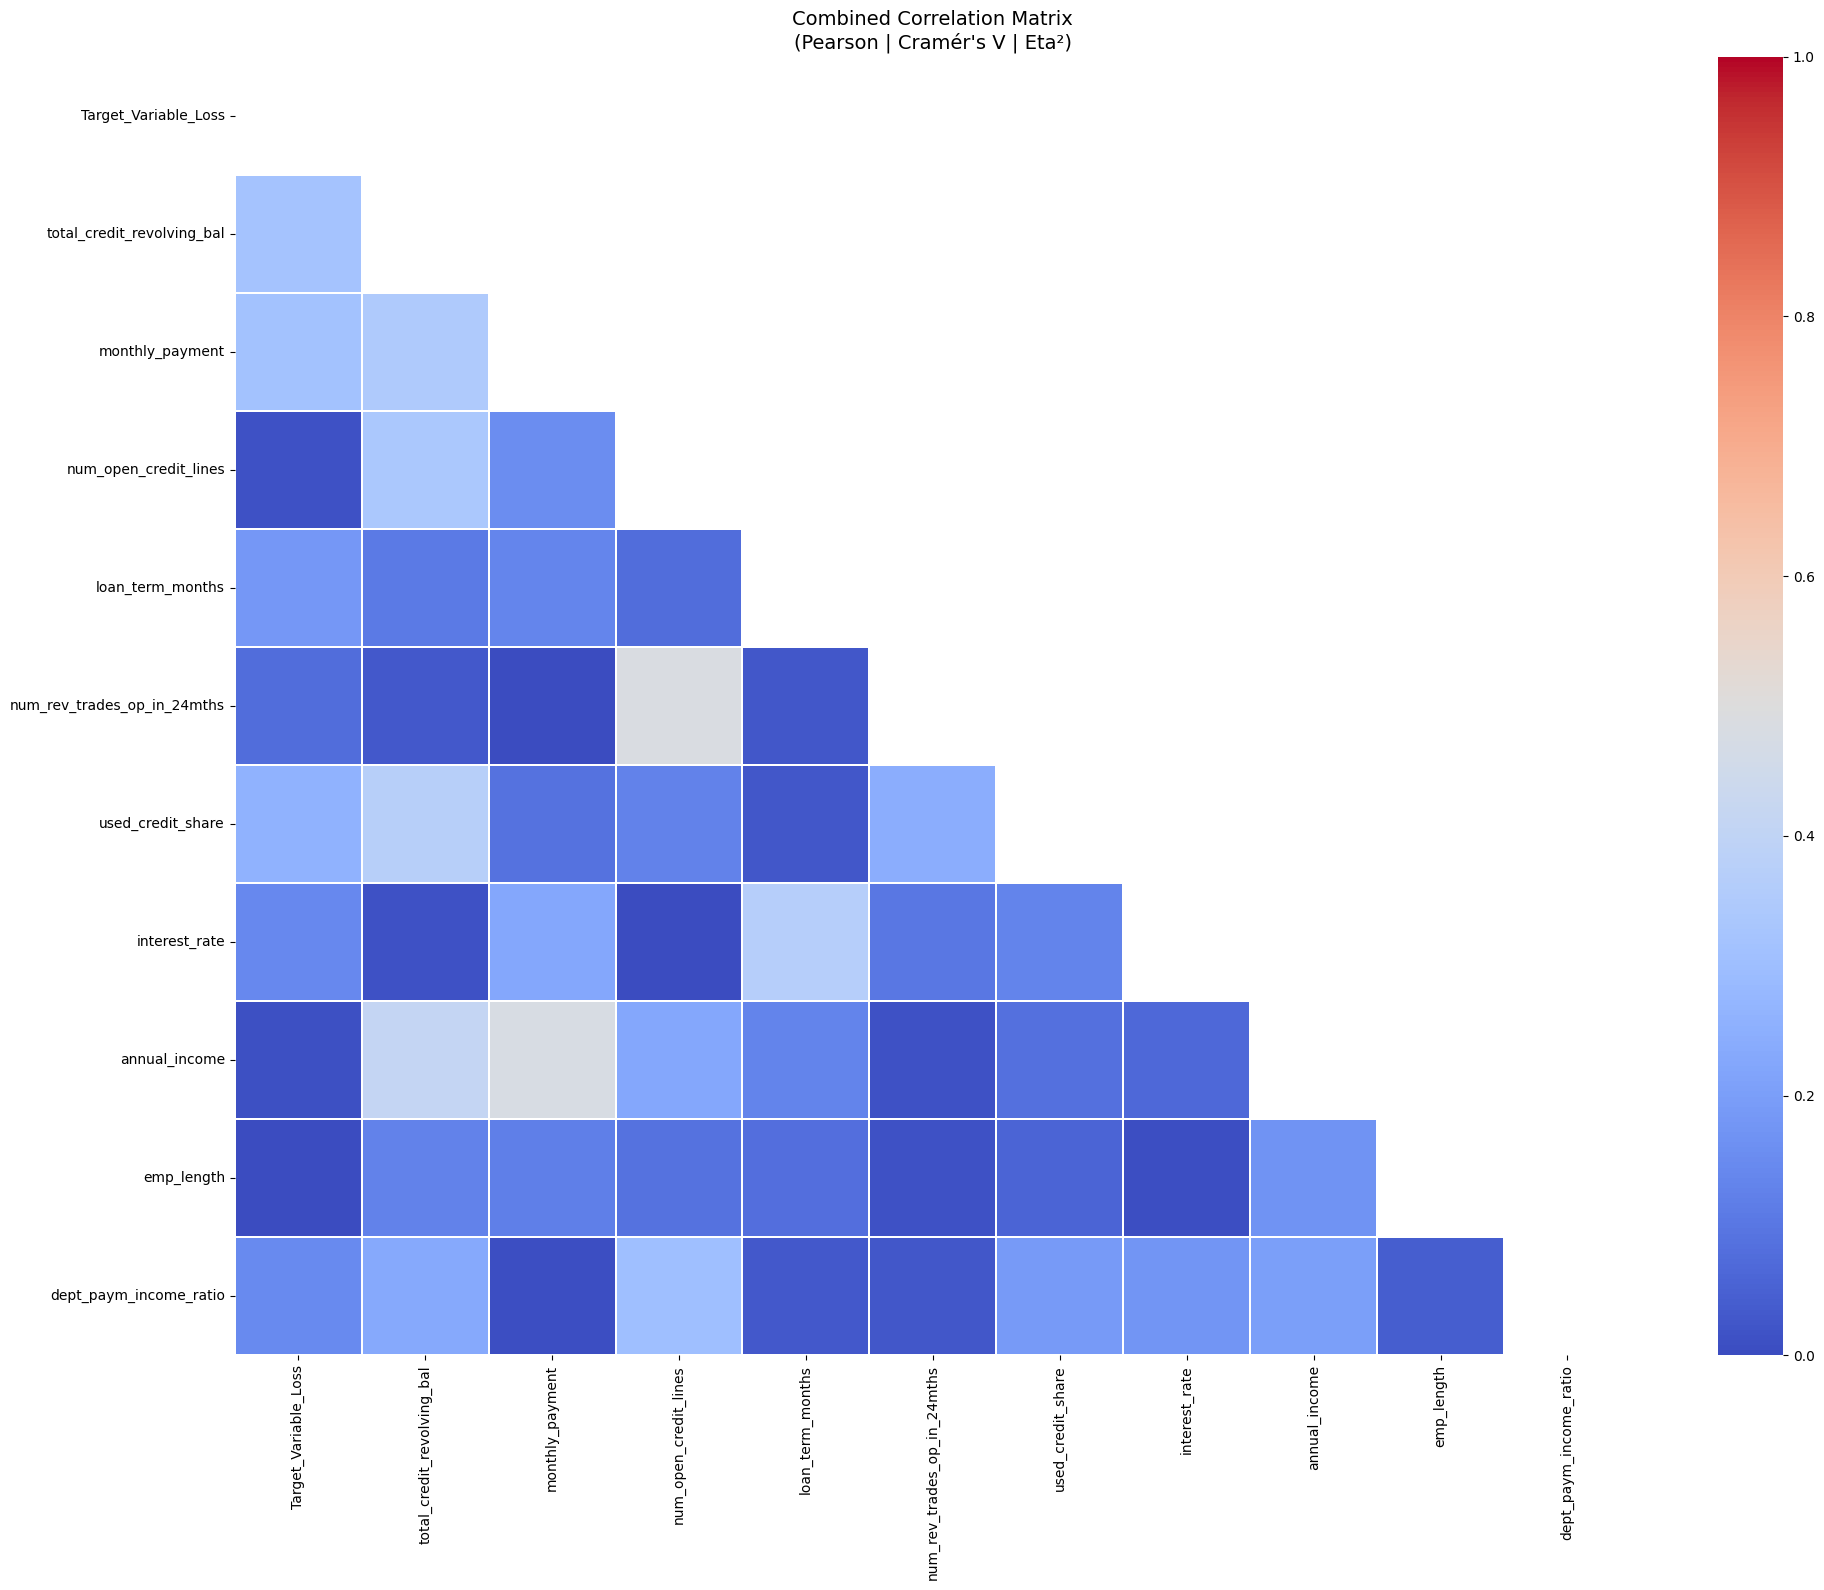

In [49]:
# We obtain and plot the correlation matrix for the PD Model.
corr_matrix_LGD = compute_plot_correlation_matrix(df_LGD_num_clean)

There is no problem for any model with this level of correlation. So we finally create a new dataframe for the posterior training of LGD Model.

In [50]:
# New dataframe full clean for PD Model.
df_LGD_clean = df_LGD_num_clean.copy()

### 5. Checkpoint: LGD Model dataframe and features.

We save the dataframe previously to training PD Model.

In [51]:
# We save the dataframe.
with open("checkpoint_df_LGD_training.pkl", "wb") as f:
    pickle.dump({"df_LGD_clean": df_LGD_clean}, f)

# We save the features.
with open("features_LGD_num_for_training.pkl", "wb") as f:
    pickle.dump(num_features_LGD, f)

with open("features_LGD_cat_for_training.pkl", "wb") as f:
    pickle.dump(cat_features_LGD, f)


In [ ]:
# In case we want to load the dataframe.
with open("checkpoint_df_LGD_training.pkl", "rb") as f:
    data = pickle.load(f)
df_LGD_clean = data["df_LGD_clean"]

# We load the features.
with open("features_LGD_num_for_training.pkl", "rb") as f:
    num_features_LGD = pickle.load(f)

with open("features_LGD_cat_for_training.pkl", "rb") as f:
    cat_features_LGD = pickle.load(f)

### 6. Training: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM and CatBoostCheckpoint: PD Model dataframe and features.

Six regression models were trained for the LGD model, covering the full spectrum from interpretable linear models to state-of-the-art gradient boosting ensembles. All models were trained on the defaulted loan population exclusively (~128k observations), using the same preprocessed dataset (RobustScaler + One-Hot Encoding), tuned via andomizedSearchCV
on a random sample of 100,000 observations with 5-fold cross-validation optimizing RMSE, and evaluated on a held-out test set of 20% of the defaulted population.

---

#### Ridge Regression

**Description:**
Models the target as a linear combination of the input features, with L2 regularization penalizing large coefficients. Used in preference to plain linear regression because the presence of correlated features (such as `used_credit_share` and `total_credit_revolving_bal`) can produce unstable coefficients without regularization. Each coefficient represents the marginal contribution of a feature to the predicted loss severity, holding all other features constant.

**Advantages:**
- Full coefficient interpretability, each feature has a single, signed, stable weight   directly interpretable in terms of loss severity
- Fastest to train and score in production
- Well-understood statistical properties, confidence intervals on coefficients available
- L2 regularization improves stability on correlated features relative to OLS
- Regulatory acceptance under Basel IRB for its transparency and auditability

**Limitations:**
- Assumes a linear relationship between features and LGD. Non-linear relationships and interaction effects are not captured unless explicitly engineered
- Performance ceiling substantially lower than ensemble methods on datasets with complex feature interactions, as confirmed by the R² of 0.36 versus 0.66 for boosting models
- Sensitive to feature scale, requires RobustScaler preprocessing to perform correctly
- Does not capture the non-linear relationship between revolving balance, income, and loss severity that tree-based models exploit naturally

**Best hyperparameters found:**
`alpha = 14.10`, `fit_intercept = True`

---

#### Decision Tree

**Description:**
Partitions the feature space into rectangular regions via a sequence of binary splits, producing a tree structure where each leaf assigns a predicted loss severity. The resulting model can be visualized and explained as a set of if-then rules applicable to loss estimation.

**Advantages:**
- Fully interpretable, the decision path for any individual LGD prediction can be traced and explained in plain language
- Captures non-linear relationships and interactions automatically
- No feature scaling required
- Useful as a baseline to quantify the benefit of ensemble methods

**Limitations:**
- High variance — small changes in training data can produce very different trees and very different LGD predictions
- Prone to overfitting, particularly on a relatively small dataset of 128k observations
- Weaker predictive performance than ensembles, as confirmed by the R² gap of 0.06 relative to Random Forest

**Best hyperparameters found:**
`max_depth = 12`, `min_samples_leaf = 60`, `min_samples_split = 77`,
`criterion = squared_error`

---

#### Random Forest

**Description:**
Ensemble of decision trees trained on bootstrap samples of the data, with a random subset of features considered at each split. Predictions are aggregated by averaging across trees. The randomization reduces variance relative to a single tree and produces more stable LGD estimates.

**Advantages:**
- More stable and less prone to overfitting than a single decision tree
- Captures non-linear relationships and feature interactions
- Provides feature importance estimates
- Robust to outliers in the LGD distribution

**Limitations:**
- Loss of interpretability relative to a single tree or ridge regression
- Slower to train than boosting methods
- Marginally worse performance than gradient boosting, as confirmed by a 1.4 RMSE gap relative to CatBoost

**Best hyperparameters found:**
`n_estimators = 317`, `max_depth = 14`, `max_features = 0.5`,
`min_samples_leaf = 73`, `min_samples_split = 240`

---

#### XGBoost

**Description:**
Gradient boosting framework that builds trees sequentially, where each tree corrects the residual errors of the previous ensemble. Uses second-order gradient information and includes L1 and L2 regularization terms directly in the objective function.

**Advantages:**
- State-of-the-art performance on structured tabular data
- Built-in regularization reduces overfitting on the relatively small LGD dataset
- Handles missing values natively
- Strong performance even with limited hyperparameter tuning

**Limitations:**
- Limited interpretability without SHAP
- More hyperparameters to tune than simpler models
- Marginally slower than LightGBM on large datasets

**Best hyperparameters found:**
`n_estimators = 415`, `max_depth = 6`, `learning_rate = 0.023`,
`subsample = 0.606`, `colsample_bytree = 0.843`, `min_child_weight = 9`,
`gamma = 0.085`, `reg_alpha = 0.563`, `reg_lambda = 1.271`

---

#### LightGBM

**Description:**
Gradient boosting framework with leaf-wise tree growth and Gradient-based One-Side Sampling (GOSS). Particularly efficient on large datasets, though on the 128k defaulted population the speed advantage over XGBoost is less pronounced than on the full portfolio.

**Advantages:**
- Competitive performance with XGBoost, virtually identical RMSE (23.1045 vs 23.1048)
- Leaf-wise growth can capture sharper non-linearities in the LGD distribution
- Lower memory footprint than XGBoost

**Limitations:**
- Same interpretability limitations as XGBoost
- Leaf-wise growth requires careful tuning of `num_leaves` and `min_child_samples` to avoid overfitting on the smaller LGD dataset

**Best hyperparameters found:**
`n_estimators = 383`, `max_depth = 7`, `learning_rate = 0.069`,
`subsample = 0.953`, `colsample_bytree = 0.850`, `min_child_samples = 153`,
`num_leaves = 47`, `reg_alpha = 0.218`, `reg_lambda = 0.833`

---

### CatBoost

**Description:**
Gradient boosting framework with ordered boosting and symmetric trees. Selected as the best performing model for LGD with an R² of 0.6651 and RMSE of 22.90, marginally outperforming LightGBM and XGBoost.

**Advantages:**
- Best overall performance among all models, lowest RMSE (22.90) and highest R² (0.6651)
- Ordered boosting reduces overfitting without requiring aggressive regularization, particularly beneficial on the smaller LGD dataset relative to the full PD portfolio
- Requires less hyperparameter tuning than XGBoost or LightGBM to reach competitive performance
- Symmetric trees produce faster scoring in production

**Limitations:**
- Slower to train than LightGBM
- Same interpretability limitations as other boosting models
- Native categorical handling advantage is reduced since features are already encoded

**Best hyperparameters found:**
`iterations = 441`, `depth = 9`, `learning_rate = 0.041`,
`l2_leaf_reg = 4.28`, `subsample = 0.993`, `border_count = 246`

In [54]:
# We split the dataset in train and test and preprocess the features with RobustScaler and One-Hot Encoding.
X = df_LGD_clean[num_features_LGD + cat_features_LGD]
y = df_LGD_clean['Target_Variable_Loss']

X_train_LGD, X_test_LGD, y_train_LGD, y_test_LGD = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

X_train_LGD, X_test_LGD, scaler_LGD = preprocess_features_LGD(
    X_train_LGD, X_test_LGD, cat_features_LGD, num_features_LGD
)

In [60]:
# We train all the models described above and save the results.
results_LGD_Model = train_all_models_LGD(X_train_LGD, y_train_LGD, X_test_LGD, y_test_LGD, sample_size=100_000)


────────────────────────────────────────────────────────────
  Training: ridge_LGD
────────────────────────────────────────────────────────────
  Sampling 100,000 rows for hyperparameter search...
  Running RandomizedSearchCV (50 iterations, 5-fold CV)...
  Best params  : {'alpha': np.float64(14.102422497476264), 'fit_intercept': True}
  Best CV RMSE : 31.3973
  Refitting on full training set (102,381 rows)...
  Test RMSE: 31.5742 | MAE: 20.7162 | R²: 0.3635
  Saved: models\ridge_LGD.pkl | models\ridge_LGD_metrics.json

────────────────────────────────────────────────────────────
  Training: decision_tree_LGD
────────────────────────────────────────────────────────────
  Sampling 100,000 rows for hyperparameter search...
  Running RandomizedSearchCV (50 iterations, 5-fold CV)...
  Best params  : {'criterion': 'squared_error', 'max_depth': 12, 'min_samples_leaf': 60, 'min_samples_split': 77}
  Best CV RMSE : 24.7837
  Refitting on full training set (102,381 rows)...
  Test RMSE: 24.834


### 7. Results

| Model | RMSE | MAE | R² | CV RMSE |
|---|---|---|---|---|
| CatBoost | 22.9019 | 14.0287 | 0.6651 | 23.0079 |
| LightGBM | 23.1045 | 14.0950 | 0.6592 | 23.1678 |
| XGBoost | 23.1048 | 14.1304 | 0.6591 | 23.1590 |
| Random Forest | 24.2824 | 14.8607 | 0.6235 | 24.2313 |
| Decision Tree | 24.8346 | 15.2095 | 0.6062 | 24.7837 |
| Ridge | 31.5742 | 20.7162 | 0.3635 | 31.3973 |

### 8. Interpretation of Results

#### 8.1 Why RMSE is the primary metric

All models were optimized on RMSE rather than MAE or R². RMSE penalizes large prediction errors more heavily than MAE due to the squaring of residuals. In the context of LGD, a large prediction error on a single loan can translate into a significant miscalculation of Expected Loss, particularly for high-exposure loans. RMSE is therefore the correct primary metric for a loss severity model where large errors are disproportionately costly.

MAE is reported as a complement, it is more robust to outliers in the LGD distribution and provides an intuitive measure of the average prediction error in percentage points of loss. R² is reported to quantify the proportion of LGD variance explained by the model, which contextualizes the absolute error metrics.

#### 8.2 Interpretation of the results in context

The RMSE of 22.90 for CatBoost means that on average the model's LGD predictions deviate from the actual values by approximately 23 percentage points. Given that the target `Target_Variable_Loss` is expressed as a percentage (0-100), this is a meaningful error that reflects the intrinsic difficulty of modeling loss severity.

The R² of 0.6651 indicates that the best model explains approximately 67% of the variance in LGD. This is a strong result relative to industry benchmarks for LGD models trained on real recovery data (typically R² of 0.15-0.40), and is explained by two factors: the target variable is a proxy constructed from observable loan data rather than actual recovery amounts, making it more predictable than real LGD; and the features selected for the model have a direct economic relationship with the proxy target.

#### 8.3 The linear model gap

The R² gap between ridge regression (0.36) and the boosting models (0.66) is substantially larger than the equivalent gap observed in the PD model. This indicates that the relationship between the selected features and LGD is highly non-linear and involves complex interactions that a linear model cannot capture. The interaction between revolving
balance, income, and loss severity is a clear example: the impact of a high revolving balance on LGD is not constant but depends on the borrower's income level and utilization
rate simultaneously.

This gap reinforces the choice of gradient boosting as the primary model for LGD, while ridge regression remains useful as an interpretable baseline for regulatory documentation.

#### 8.4 Generalization: CV RMSE vs Test RMSE

For all models, the difference between CV RMSE and Test RMSE is below 0.2 percentage points. This tight alignment confirms that the models generalize well to unseen data and that hyperparameter tuning did not overfit to the sample. The consistency is particularly notable given that the LGD dataset is substantially smaller than the PD dataset (~128k
vs ~1.25M observations).

---

### 9. Limitations of These Results

**LGD proxy target.**
`Target_Variable_Loss = 100 * max_bal_owed / funded_amnt` is an approximation of the true LGD. Real LGD requires knowing the net recovery after default resolution, including collection costs, collateral liquidation, partial repayments, and write-offs. The proxy used here measures exposure at the time of default relative to the original funded amount,
not the actual net loss. This makes the target more predictable than real LGD (hence the higher R² relative to industry benchmarks) but less useful for regulatory capital calculation under Basel IRB.

**Absence of temporal ordering.**
The train/test split is random rather than chronological, consistent with the limitation documented for the PD model. Out-of-time validation would be required to assess model stability across different economic periods.

**Out-of-population inference.**
The LGD model is trained exclusively on defaulted loans and applied at inference time to the full portfolio including non-defaulted loans. This extrapolation is inherent to the problem structure and is standard practice in Basel IRB modeling. The impact on Expected Loss is bounded because LGD estimates for non-defaulted loans are multiplied by low PD
values, limiting their contribution to total EL.

**No downturn LGD adjustment.**
Basel IRB requires LGD to be calibrated under adverse economic conditions (downturn LGD), not average conditions. The model trained here produces a through-the-cycle LGD estimate, which is appropriate for Expected Loss calculation but not for regulatory capital requirements, which demand a more conservative downturn estimate.

**Uniform preprocessing across models.**
All models received the same RobustScaler and One-Hot Encoding preprocessing. Ridge regression would benefit from additional linearizing transformations of the features, while CatBoost would handle the binary `loan_term_months` encoding natively. This limitation is consistent with the approach taken for the PD model and is documented as a portfolio simplification.

---

### 10. Model Selection Recommendation

For the purpose of computing Expected Loss in this project, **CatBoost** is selected as the primary LGD model based on its superior RMSE (22.90) and R² (0.6651), and the tightest alignment between CV RMSE and Test RMSE (0.11 gap) among the boosting models, indicating robust generalization on the relatively small defaulted population.

For a production Basel IRB context, **ridge regression** would be the recommended baseline model for regulatory documentation due to its full interpretability, while a gradient boosting model with SHAP-based explanation would be deployed in parallel for actual loss estimation. The R² gap of 0.30 between ridge and CatBoost represents a substantial improvement in predictive accuracy that justifies the additional complexity in a production environment with adequate model governance infrastructure.

For this reason, **CatBoost** model will be used for LGD calculation. Also we will have a look to its SHAP values.

LGD computed for 1,257,995 loans
Mean LGD : 45.4882
Median LGD: 37.9773
Computing SHAP values...
shap_values shape: (20000, 10)


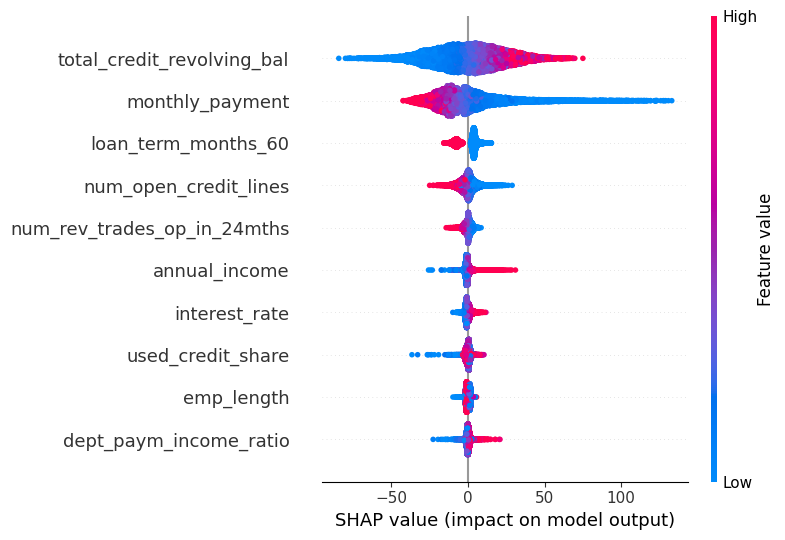

In [65]:
# Load best model
with open('models/catboost_LGD.pkl', 'rb') as f:
    model_LGD = pickle.load(f)

# Fit pipeline on defaulted training population
pipeline_LGD = FeaturePipeline_LGD()
X_full_LGD = pipeline_LGD.fit_transform(
    df_master_features.loc[
        df_master_features['Target_Variable_Default'] == 1,
        features_LGD
    ]
)

# Inference on full dataset
X_full_for_inference = pipeline_LGD.transform(df_master_features[features_LGD])
y_pred_LGD = model_LGD.predict(X_full_for_inference)

df_master_features['LGD'] = y_pred_LGD

print(f"LGD computed for {len(y_pred_LGD):,} loans")
print(f"Mean LGD : {y_pred_LGD.mean():.4f}")
print(f"Median LGD: {np.median(y_pred_LGD):.4f}")

# SHAP values — computed on a sample for efficiency
print("Computing SHAP values...")
X_shap = pd.concat([X_train_LGD, X_test_LGD], axis=0).sample(n=20_000, random_state=42)

explainer   = shap.TreeExplainer(model_LGD)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"shap_values shape: {shap_values.shape}")

# SHAP summary plot
shap.summary_plot(shap_values, X_shap, max_display=X_shap.shape[1])

In [95]:
# We obtain the mean and median from the original default loans.
print(df_master_features["Target_Variable_Loss"].mean())
print(df_master_features["Target_Variable_Loss"].median())

45.9984091264922
35.06


### 11. No more layers for LGD Model

As we can see above, the mean LGD prediction for all the dataset, the mean LGD predicted is 45.4882 and the median is 37.9773, which is quite similar to the original values of mean 45.9984 and median 35.06, so in this case we don't need any more layers to the LGD Model.

### 12. Final LGD

The final LGD is included in `df_master_features`dataframe.

In [71]:
# We save the final LGD in df_master_features dataframe.
df_master_features["LGD"] = y_pred_LGD

In [75]:
df_master_features.head()

,Target_Variable_Default,Target_Variable_Loss,EAD,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,...,mths_since_recent_bankcard_delinq_PD,mths_since_recent_revol_delinq_PD,mths_since_last_delinq_PD,mths_since_last_installment_acc_op_PD,mths_since_recent_bankcard_delinq_LGD,mths_since_recent_revol_delinq_LGD,mths_since_last_delinq_LGD,mths_since_last_installment_acc_op_LGD,LGD,PD
0,0,85.480000,2500,13.56,84.92,C1,Hospitality,10.0,RENT,55000.0,...,999.0,999.0,999.0,2.0,999.0,999.0,999.0,2.0,74.693226,0.012264
1,0,3.326667,30000,18.94,777.23,D2,Government,10.0,MORTGAGE,90000.0,...,999.0,999.0,71.0,3.0,999.0,999.0,71.0,3.0,19.524034,0.032291
2,0,0.000000,5000,17.97,180.69,D1,Admin,6.0,MORTGAGE,59280.0,...,999.0,999.0,999.0,14.0,999.0,999.0,999.0,14.0,46.746201,0.027297
3,0,94.025000,4000,18.94,146.51,D2,Management,10.0,MORTGAGE,92000.0,...,999.0,999.0,999.0,5.0,999.0,999.0,999.0,5.0,65.626352,0.013806
4,0,1.720000,30000,16.14,731.78,C4,Construction,10.0,MORTGAGE,57250.0,...,999.0,999.0,999.0,4.0,999.0,999.0,999.0,4.0,0.588222,0.024621


## Checkpoint: Save LGD

In [76]:
# We save the final LGD in df_master_features dataframe.
with open("checkpoint_DataFrame_after_LGD_calculation.pkl", "wb") as f:
    pickle.dump({"df_master_features": df_master_features}, f)

In [ ]:
# In case we want to load the dataframe.
with open("checkpoint_DataFrame_after_LGD_calculation.pkl", "rb") as f:
    data = pickle.load(f)
df_master_features = data["df_master_features"]

# Have the predictions sense?

In order to check if the predictions have sense we will check if the PD for default loans is bigger than for not default. This check doesn't have any sense for LGD since a non default loan could have a bigger LGD than one that has been already default.

In [78]:
# We obtain the PD for default and not default loans.
PD_not_default = df_master_features.loc[df_master_features["Target_Variable_Default"]==0,"PD"].describe()
print(PD_not_default)
PD_default = df_master_features.loc[df_master_features["Target_Variable_Default"]==1,"PD"].describe()
print(PD_default)

count    1.130018e+06
mean     9.225920e-02
std      8.246911e-02
min      0.000000e+00
25%      2.339742e-02
50%      7.167144e-02
75%      1.339646e-01
max      7.327273e-01
Name: PD, dtype: float64
count    127977.000000
mean          0.184687
std           0.103455
min           0.000000
25%           0.105766
50%           0.168198
75%           0.247896
max           0.732727
Name: PD, dtype: float64


As we can see here, the mean PD for not default is 0.09 with an std of 0.08, in constrast to mean for default, which is 0.18 (the double) with an std of 0.10.

# Final Expected Loss Calculation

Once we have all the variables needed for Expected Loss we just calculated.

In [8]:
# We calculates de Expected Loss for every loan.
df_master_features["EL"] = df_master_features["PD"]*(df_master_features["LGD"]/100)*df_master_features["EAD"]

# The total Expected Loss is the sum of all the loans.
Expected_Loss = df_master_features["EL"].sum()
Expected_Loss

np.float64(662377572.0222311)

One check we could do is to see if the Expected Loss is bigger than the already know loss of acquiring all the loans, which is the sum of `Target_Variable_Loss` for all default loans.

In [12]:
# We obtain the loss of all default loans.
LGD_default_loans = df_master_features.loc[df_master_features["Target_Variable_Default"]==1, "Target_Variable_Loss"]
EAD_default_loans = df_master_features.loc[df_master_features["Target_Variable_Default"]==1, "EAD"]
loss_default_loans = ((LGD_default_loans*EAD_default_loans)/100).sum()
relative_change = Expected_Loss/loss_default_loans - 1

print(f"The loss of default loans is {loss_default_loans:.2f} and the Expected Loss of all loans is {Expected_Loss:.2f}. So, the Expected Loss represents a {relative_change*100:.2f}% increase.")

The loss of default loans is 651402450.00 and the Expected Loss of all loans is 662377572.02. So, the Expected Loss represents a 1.68% increase.


This makes sense since the Expected loss considering the non default loans only increases 1.68%.

# Final saving of dataset.

In [22]:
# We save the final df_master_features dataframe.
with open("DataFrame_EL_calculated.pkl", "wb") as f:
    pickle.dump({"df_master_features": df_master_features}, f)

In [4]:
# In case we want to load the dataframe.
with open("DataFrame_EL_calculated.pkl", "rb") as f:
    data = pickle.load(f)
df_master_features = data["df_master_features"]

## Expected Loss Validation

Three validation checks were performed to verify the economic coherence of the EL estimates before using them for portfolio analysis.

### 1. EL vs Observed Loss

The first check compares the total EL of the portfolio against the total observed loss on defaulted loans, computed as the sum of `Target_Variable_Loss / 100 * EAD` over all defaulted loans.

In [17]:
# We obtain the loss of all default loans.
LGD_default_loans = df_master_features.loc[df_master_features["Target_Variable_Default"]==1, "Target_Variable_Loss"]
EAD_default_loans = df_master_features.loc[df_master_features["Target_Variable_Default"]==1, "EAD"]
loss_default_loans = ((LGD_default_loans*EAD_default_loans)/100).sum()
relative_change = Expected_Loss/loss_default_loans - 1

print(f"The loss of default loans is {loss_default_loans:.2f} and the Expected Loss of all loans is {Expected_Loss:.2f}. So, the Expected Loss represents a {relative_change*100:.2f}% increase.")

The loss of default loans is 651402450.00 and the Expected Loss of all loans is 662377572.02. So, the Expected Loss represents a 1.68% increase.


| | Amount |
|---|---|
| Observed loss (defaulted loans) | 651,402,450 |
| Expected Loss (full portfolio) | 662,377,572 |
| EL / Observed loss ratio | 1.0168 |

The EL is 1.68% above the observed loss on defaulted loans. This result is economically coherent for the following reason: the EL covers the full portfolio including non-defaulted loans with PD > 0, whose expected losses add approximately 11M to the total. At the same time, the EL for defaulted loans is lower than their realized loss because the model assigns them a calibrated PD of approximately 0.18 rather than 1, the model does not know ex-ante which loans will default, so it distributes risk probability across the full portfolio.

This is the correct interpretation of EL under Basel: it is not an estimate of realized losses but of expected losses at origination, averaged across all possible scenarios.

### 2. EL Decomposition by Population




In [18]:
# We obtain the EL by default and non default loans.
el_default    = df_master_features.loc[df_master_features['Target_Variable_Default'] == 1, 'EL'].sum()
el_no_default = df_master_features.loc[df_master_features['Target_Variable_Default'] == 0, 'EL'].sum()

print(f"EL defaultados    : {el_default:,.0f}")
print(f"EL no defaultados : {el_no_default:,.0f}")
print(f"% EL no defaultados: {el_no_default / (el_default + el_no_default) * 100:.2f}%")

EL defaultados    : 113,655,672
EL no defaultados : 548,721,900
% EL no defaultados: 82.84%


| Population | EL | % of Total EL |
|---|---|---|
| Defaulted loans (128k) | 113,655,672 | 17.16% |
| Non-defaulted loans (1.13M) | 548,721,900 | 82.84% |
| Total | 662,377,572 | 100% |

The non-defaulted population contributes 82.84% of total EL despite having a lower mean PD (0.092 vs 0.185 for defaulted loans). This is driven by volume: 1.13M non-defaulted loans with modest individual EL contributions aggregate to a larger total than 128k defaulted loans with higher individual EL contributions. This is consistent with the law of large numbers in portfolio credit risk, aggregate expected loss is dominated by the large number of low-probability events rather than the small number of high-probability ones.

### 3 EL Rate

In [19]:
# We obtain the EL rate
total_ead = df_master_features['EAD'].sum()
el_rate   = df_master_features['EL'].sum() / total_ead * 100

print(f"EL rate sobre cartera: {el_rate:.2f}%")

EL rate sobre cartera: 3.52%


```
EL rate = Total EL / Total EAD = 3.52%
```

An EL rate of 3.52% is within the expected range for a US retail personal loan portfolio without collateral. Historical net charge-off rates for unsecured personal loans in the US have ranged between 3% and 5%, confirming that the model produces portfolio-level loss estimates consistent with observed industry experience.

---

## Portfolio Analysis by Segment

### 1 EL Rate by Loan Term

In [20]:
# EL rate by loan term
df_master_features.groupby('loan_term_months').apply(
    lambda x: (x['EL'].sum() / x['EAD'].sum() * 100).round(2)
)

loan_term_months
36    3.42
60    3.68
dtype: float64

| Loan Term | EL Rate |
|---|---|
| 36 months | 3.42% |
| 60 months | 3.68% |

Loans with a 60-month term show a higher EL rate than 36-month loans, consistent with the economic rationale documented in the feature descriptions: longer-term loans accumulate more outstanding principal before default, resulting in higher loss severity. The difference of 26 basis points is modest, reflecting that loan term is one of several features driving the model and its effect is moderated by the remaining variables.

### 2 EL Rate by Interest Rate Quartile

In [21]:
df_master_features['interest_rate_q'] = pd.qcut(
    df_master_features['interest_rate'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

df_master_features.groupby('interest_rate_q').apply(
    lambda x: (x['EL'].sum() / x['EAD'].sum() * 100).round(2)
)

interest_rate_q
Q1    1.38
Q2    2.86
Q3    4.04
Q4    5.62
dtype: float64

| Interest Rate Quartile | EL Rate |
|---|---|
| Q1 (lowest rates) | 1.38% |
| Q2 | 2.86% |
| Q3 | 4.04% |
| Q4 (highest rates) | 5.62% |

The EL rate increases monotonically from Q1 to Q4, with the highest-rate loans showing an EL rate four times that of the lowest-rate loans (5.62% vs 1.38%). This gradient confirms two things simultaneously: first, that the interest rate assigned by Lending Club at origination is a strong signal of underlying credit risk, consistent with its role as a proxy for the internal credit grade; second, that the model is correctly discriminating between risk segments and not just calibrated at the portfolio mean.

A model that is well-calibrated globally but fails to differentiate between segments would show a flat EL rate across interest rate quartiles. The pronounced gradient observed here confirms that segment-level calibration is also correct, which is a stronger validation than global calibration alone.

---

## Limitations

**EAD approximation.**
The EAD is approximated by `funded_amnt`, the original loan amount at origination. The true EAD under Basel IRB accounts for undrawn commitments, accrued interest, and fees outstanding at the time of default. For term loans like those in the Lending Club portfolio, `funded_amnt` is a reasonable approximation since there are no revolving credit facilities, but it does not account for accrued interest on the outstanding balance at the time of default, which would increase the true EAD.

**LGD proxy.**
As documented in the LGD model results, `Target_Variable_Loss = 100 * max_bal_owed / funded_amnt` is a proxy for the true LGD. The true LGD requires knowing the net recovery after the full default resolution process, including collection costs and recoveries that may occur over several years post-default. The proxy used here overestimates the true LGD for loans where partial recovery was achieved, and underestimates it for loans where collection costs exceeded the recovered amount.

**Through-the-cycle estimates.**
Both PD and LGD are estimated on historical data covering a specific time period and economic cycle. The EL estimates are therefore through-the-cycle rather than point-in-time, which makes them suitable for long-run provisioning but not for stress-testing or regulatory capital calculation under adverse scenarios.

**No vintage or seasoning adjustment.**
The EL is computed uniformly across loans regardless of their age in the portfolio. In practice, a newly originated loan has a different risk profile from a loan that has been performing for three years. A production model would incorporate vintage effects and seasoning curves to account for the evolution of credit risk over the loan lifecycle.